# Property Mapping 📍🗺️📍
#### `Important Definitions:`

`Property:`
A property refers to a defining characteristic or attribute of a concept. Both the familiar (source) and unfamiliar (target) concepts possess their own sets of properties that describe their features, behaviors, or functions.

`Property Mapping:`
Property mapping is the process of identifying correspondences between the properties of the familiar and unfamiliar concepts—linking similar characteristics to help transfer understanding from what is already known to what is new. Effective property mapping ensures that the mapped attributes accurately reflect meaningful parallels between the two concepts.

#### `Assumptions Made:`
We assume that the source (Familiar Concept (FC)) given for the target is already a correct source for the given target (Unfamiliar Concept (UC)) and creates a good analogy.

#### `Our Question or Goal here?`
1. Property Extraction Accuracy (to understand the models ability to extract the important characters in a target (UC) )
    - How accurate can the models extract properties of unfamiliar concepts ? (no description)
    - How accurate can the models extract properties of unfamiliar concepts ? (with description)

2. Mapping Accuracy (given two property sets, can it correctly align them?)
    - Can Model find the properties and then map them to given properties?
        - Given the unfamiliar + properties, given the familiar, can the model find the properies  from source that maps correctly? (no description)
        - Given the unfamiliar + properties, given the familiar, can the model find the properies from source that maps correctly? (with description)

    - Can Model given the properties and then map them to given properties?
        - Given the unfamiliar + properties, and Source + properties, Can the model correctly match them?(no description)
        - Given the unfamiliar + properties, and Source + properties, Can the model correctly match them?(with description)

In [2]:
import os
from dotenv import load_dotenv
import pandas as pd
load_dotenv()
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat, DSPyAdapter
import dspy
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
deepinfra_api_key = os.getenv("DEEPINFRA_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

# Create client
client = create_client()

In [3]:
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat

# See all available models
models = list_available_models()
print(f"Available models ({len(models)}):\n")
for model in models:
    print(f"  • {model}")

Available models (12):

  • gpt-oss-20b
  • gpt-oss-120b
  • gpt-4.1-mini
  • gpt-4.1-nano
  • grok-4-fast
  • gemini-2.5-flash-lite
  • llama-3.1-405b-instruct
  • meta-llama-3-1-70b-instruct
  • meta-llama-3-1-8b-instruct
  • deepseek-r1
  • qwen3-14b
  • qwen3-32b


### DSPy Signature Classes for Analogy Mapping Analysis

Below are the signature classes organized by the research questions:
1. **Property Extraction Accuracy** - Can models extract properties correctly?
2. **Mapping Accuracy** - Can models align properties correctly?

Each has variants with/without descriptions to test the impact of additional context.

 ---
 #### `DSPY` 
 
**DSPy (Declarative Self-Improving Python)** is a new programming framework from Stanford (NeurIPS 2025) that replaces brittle prompt engineering with **structured, declarative modules**. Instead of manually crafting prompts, researchers write compositional Python code describing *what* each language model (LM) module should do, and the DSPy compiler automatically **learns and optimizes how** it should do it. Through built-in optimizers like `BootstrapRS`, `GEPA`, and `MIPROv2`, DSPy can **generate better few-shot examples, improve natural-language instructions, and even fine-tune LM weights** within a pipeline.
 https://arxiv.org/pdf/2310.03714 

As a researcher, you can trust DSPy because it is 
1. **peer-reviewed and accepted at NeurIPS 2025**
2. **highly cited** (400+ citations within a year)
3. **openly reproducible**—its methods are grounded in transparent Python abstractions rather than ad-hoc prompt tuning. DSPy’s declarative and compiler-based design makes LM pipelines **auditable, modular, and self-improving**, aligning with research principles of clarity, reproducibility, and generalization across models and domains.


In [4]:
"""
===========================================
1. PROPERTY EXTRACTION ACCURACY SIGNATURES
===========================================
Test: Can the model extract the right attributes from target/source?
"""

# 1A: Extract properties WITHOUT description
class PropertyExtraction(dspy.Signature):
    """Extract key properties and attributes from an unfamiliar concept."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.OutputField(desc="List of 10 key properties that characterize the unfamiliar concept. Each property must be 1-2 words maximum.")


# 1B: Extract properties WITH description  
class PropertyExtractionWithDescription(dspy.Signature):
    """Extract key properties and attributes from an unfamiliar concept with contextual description."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.OutputField(desc="List of 10 key properties that characterize the unfamiliar concept. Each property must be 1-2 words maximum.")


"""
===========================================
2. MAPPING ACCURACY SIGNATURES
===========================================
Test: Can the model correctly align properties between source and target?
"""

# 2A: Find and map source properties to target (WITHOUT description)
class SourcePropertyFind_map(dspy.Signature):
    """Given an unfamiliar concept with its properties, find corresponding properties from a familiar concept that map correctly."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property (1-2 words each)")


# 2B: Find and map source properties to target (WITH description)
class SourcePropertyFind_mapWithDescription(dspy.Signature):
    """Given an unfamiliar concept with its properties and descriptions, find corresponding properties from a familiar concept."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    description_of_familiar_concept: str = dspy.InputField(desc="Detailed description or context about the familiar concept")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property (1-2 words each)")

# 2C: Match given property sets (WITHOUT description)
class PropertyMatching(dspy.Signature):
    """Given both unfamiliar and familiar concept properties, create the correct mappings between them."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    properties_of_familiar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the familiar concept. Each property is 1-2 words maximum.")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property")

# 2D: Match given property sets (WITH description)
class PropertyMatchingWithDescription(dspy.Signature):
    """Given both unfamiliar and familiar concept properties with descriptions, create accurate mappings."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    description_of_familiar_concept: str = dspy.InputField(desc="Detailed description or context about the familiar concept")
    properties_of_familiar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the familiar concept. Each property is 1-2 words maximum.")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property")




## Examples

In [5]:
adapter = DSPyAdapter(client, model_name="gpt-4.1-nano")
lm = adapter.get_dspy_lm()
dspy.settings.configure(lm=lm)
print("✅ DSPy LM Configured!")

✅ DSPy LM Configured!


In [6]:
# Store input values to print them later
unfamiliar_concept = "DNA replication"

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyExtraction)
result = extractor(unfamiliar_concept=unfamiliar_concept)

# Print results (use stored input value, not from result)
print(f"\n{'='*70}")
print(f"TEST: Property Extraction (No Description)")
print(f"{'='*70}")
print(f"\nConcept: {unfamiliar_concept}")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties_of_unfamiliar_concept, 1):
    print(f"  {i}. {prop}")
print(f"\nReasoning: {result.reasoning}")



TEST: Property Extraction (No Description)

Concept: DNA replication

Extracted Properties:
  1. semi-conservative
  2. enzymes
  3. template
  4. complementary
  5. double helix
  6. leading strand
  7. lagging strand
  8. origin of replication
  9. replication fork
  10. DNA polymerase

Reasoning: DNA replication is a fundamental biological process where a cell copies its entire genome before cell division. Understanding this process involves recognizing the key steps, enzymes involved, and the purpose of replication. It is essential for genetic inheritance, cell growth, and repair. The concept can be broken down into its core components such as unwinding the DNA, synthesizing new strands, and ensuring accuracy. By analyzing these aspects, students can grasp how genetic information is faithfully transmitted across generations.


In [7]:

description_of_unfamiliar_concept = "DNA replication is the process by which DNA makes copies of itself."
extractor = dspy.ChainOfThought(PropertyExtractionWithDescription)
result = extractor(unfamiliar_concept=unfamiliar_concept, description_of_unfamiliar_concept=description_of_unfamiliar_concept)

print(f"\n{'='*70}")
print(f"TEST: Property Extraction (WITH Description)")
print(f"{'='*70}")
print(f"\nConcept: {unfamiliar_concept}")
print(f"\nDescription: {description_of_unfamiliar_concept}")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties_of_unfamiliar_concept, 1):
    print(f"  {i}. {prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Property Extraction (WITH Description)

Concept: DNA replication

Description: DNA replication is the process by which DNA makes copies of itself.

Extracted Properties:
  1. semi-conservative
  2. enzymes
  3. template
  4. complementary
  5. bidirectional
  6. accuracy
  7. origin
  8. leading strand
  9. lagging strand
  10. replication fork

Reasoning: DNA replication is a fundamental biological process that involves copying the genetic material to ensure genetic continuity during cell division. Understanding this process requires recognizing the key components involved, such as enzymes and the DNA structure, as well as the characteristics that define how replication occurs, such as accuracy, directionality, and semi-conservative nature. These properties help distinguish DNA replication from other types of nucleic acid synthesis and are essential for understanding genetic inheritance and cellular function.


In [8]:
# Define all inputs
unfamiliar_concept = "Respiratory system"
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"

# Create predictor and get result
extractor = dspy.ChainOfThought(SourcePropertyFind_map)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Source Property Mapping (No Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"\n🔗 Mapped Source Properties:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} → {fam_prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Source Property Mapping (No Description)

Unfamiliar Concept: Respiratory system
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine

🔗 Mapped Source Properties:
   • oxygen → fuel
   • lungs → engine cylinders
   • breathing muscles → engine components

Reasoning: The respiratory system functions similarly to an engine in that it takes in essential inputs (oxygen for the respiratory system, fuel for the engine), processes them through specific components (lungs and breathing muscles for the respiratory system, engine cylinders and parts for the engine), and produces a vital output (oxygen delivery to the body, mechanical power or movement from the engine). Both systems are essential for providing energy or life-sustaining functions, and they operate through specialized parts that facilitate intake, processing, and output.


In [9]:
# Define all inputs with descriptions
unfamiliar_concept = "Respiratory system"
description_of_unfamiliar_concept = "The respiratory system is a biological system consisting of organs and structures used for gas exchange. It takes in oxygen and expels carbon dioxide through breathing."
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
description_of_familiar_concept = "An engine is a machine that converts fuel energy into mechanical motion through combustion. It requires fuel, air, and produces exhaust gases."

# Create predictor and get result
extractor = dspy.ChainOfThought(SourcePropertyFind_mapWithDescription)
result = extractor(
    unfamiliar_concept=unfamiliar_concept,
    description_of_unfamiliar_concept=description_of_unfamiliar_concept,
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept,
    familiar_concept=familiar_concept,
    description_of_familiar_concept=description_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Source Property Mapping (WITH Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Description: {description_of_unfamiliar_concept[:80]}...")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Description: {description_of_familiar_concept[:80]}...")
print(f"\n🔗 Mapped Source Properties:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} → {fam_prop}")
print(f"\nReasoning: {result.reasoning}")



TEST: Source Property Mapping (WITH Description)

Unfamiliar Concept: Respiratory system
Description: The respiratory system is a biological system consisting of organs and structure...
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Description: An engine is a machine that converts fuel energy into mechanical motion through ...

🔗 Mapped Source Properties:
   • oxygen → fuel
   • lungs → combustion chamber
   • breathing muscles → moving parts

Reasoning: The respiratory system functions similarly to an engine in that both systems require a source of input (oxygen for the respiratory system, fuel and air for the engine) to produce a vital output (gas exchange for respiration, mechanical motion for the engine). The lungs act like the engine's combustion chamber, facilitating the process of gas exchange, while breathing muscles are akin to the engine's components that facilitate movement and operation. Both systems rely on specific s

In [10]:
# Define all inputs
unfamiliar_concept = "Respiratory system"
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
properties_of_familiar_concept = ['fuel', 'combustion chamber', 'piston']

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyMatching)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept, 
    properties_of_familiar_concept=properties_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Property Matching (No Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Properties of Familiar Concept: {properties_of_familiar_concept}")
print(f"\n🔗 Property Mappings:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Property Matching (No Description)

Unfamiliar Concept: Respiratory system
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Properties of Familiar Concept: ['fuel', 'combustion chamber', 'piston']

🔗 Property Mappings:
   • oxygen ↔ fuel
   • lungs ↔ combustion chamber
   • breathing muscles ↔ piston

Reasoning: The respiratory system functions to facilitate gas exchange, primarily bringing in oxygen and removing carbon dioxide, similar to how an engine takes in fuel and air for combustion. The lungs are the main organs where gas exchange occurs, analogous to the combustion chamber where fuel is burned. Breathing muscles, such as the diaphragm, help draw air in and out, comparable to pistons that move to create the necessary pressure for engine operation. Therefore, oxygen corresponds to fuel, lungs to combustion chamber, and breathing muscles to pistons, as both sets of components are essential for their respective systems to 

In [11]:
# Define all inputs (reusing concepts from previous cell, but adding descriptions)
unfamiliar_concept = "Respiratory system"
description_of_unfamiliar_concept = "The respiratory system is a biological system consisting of organs and structures used for gas exchange. It takes in oxygen and expels carbon dioxide through breathing."
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
description_of_familiar_concept = "An engine is a machine that converts fuel energy into mechanical motion through combustion. It requires fuel, air, and produces exhaust gases."
properties_of_familiar_concept = ['fuel', 'combustion chamber', 'piston']

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyMatchingWithDescription)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    description_of_unfamiliar_concept=description_of_unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept, 
    description_of_familiar_concept=description_of_familiar_concept, 
    properties_of_familiar_concept=properties_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Property Matching (WITH Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Description: {description_of_unfamiliar_concept[:80]}...")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Description: {description_of_familiar_concept[:80]}...")
print(f"Properties of Familiar Concept: {properties_of_familiar_concept}")
print(f"\n🔗 Property Mappings:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")
print(f"\nReasoning: {result.reasoning}")



TEST: Property Matching (WITH Description)

Unfamiliar Concept: Respiratory system
Description: The respiratory system is a biological system consisting of organs and structure...
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Description: An engine is a machine that converts fuel energy into mechanical motion through ...
Properties of Familiar Concept: ['fuel', 'combustion chamber', 'piston']

🔗 Property Mappings:
   • oxygen ↔ fuel
   • lungs ↔ combustion chamber
   • breathing muscles ↔ piston

Reasoning: The respiratory system can be compared to an engine because both systems involve the intake of a substance (air for the respiratory system, fuel and air for the engine), a process that transforms this input into a useful output (oxygen for the body, mechanical motion for the engine), and the expulsion of waste gases (carbon dioxide for the respiratory system, exhaust gases for the engine). The lungs function similarly to the co

# Loading the dataset

In [12]:
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')
df_scar.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [13]:
import ast

# Step 1: Parse the mappings_parsed column (it's stored as string representation of list)
df_scar['mappings_list'] = df_scar['mappings_parsed'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) and x else [])

# Step 2: Extract properties from mappings
# mappings are in format: [['property1_unfamiliar', 'property1_familiar'], ['property2_unfamiliar', 'property2_familiar'], ...]
df_scar['properties_unfamiliar'] = df_scar['mappings_list'].apply(lambda x: [pair[0] for pair in x] if x else [])
df_scar['properties_familiar'] = df_scar['mappings_list'].apply(lambda x: [pair[1] for pair in x] if x else [])

# Step 3: Clean concept names (remove any domain info in parentheses)
df_scar['unfamiliar_concept'] = df_scar['system_a'].str.strip()
df_scar['familiar_concept'] = df_scar['system_b'].str.strip()

# Step 4: Use the background descriptions as-is
df_scar['description_unfamiliar'] = df_scar['system_a_background']
df_scar['description_familiar'] = df_scar['system_b_background']

print("✅ Data prepared for running functions!")
print(f"\nDataset has {len(df_scar)} rows")
print(f"\nSample row structure:")
print(f"- Unfamiliar Concept: {df_scar.iloc[2]['unfamiliar_concept']}")
print(f"- Familiar Concept: {df_scar.iloc[2]['familiar_concept']}")
print(f"- Properties Unfamiliar: {df_scar.iloc[2]['properties_unfamiliar']}")
print(f"- Properties Familiar: {df_scar.iloc[2]['properties_familiar']}")
print(f"- Description Unfamiliar (first 100 chars): {df_scar.iloc[2]['description_unfamiliar'][:100]}...")
print(f"- Description Familiar (first 100 chars): {df_scar.iloc[2]['description_familiar'][:100]}...")

df_scar.head()


✅ Data prepared for running functions!

Dataset has 400 rows

Sample row structure:
- Unfamiliar Concept: Respiratory system
- Familiar Concept: engine
- Properties Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
- Properties Familiar: ['fuel', 'combustion chamber', 'piston']
- Description Unfamiliar (first 100 chars): The respiratory system is a critical biological system used for gas exchange in both animals and pla...
- Description Familiar (first 100 chars): An engine or motor is a machine that transforms energy into mechanical energy for various applicatio...


,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc,mappings_list,properties_unfamiliar,properties_familiar,unfamiliar_concept,familiar_concept,description_unfamiliar,description_familiar
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118,"[[changes, pointer], [state, time], [adjust, m...","[changes, state, adjust]","[pointer, time, maintain]",biological clock,clock,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic..."
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149,"[[biology, books], [biodiversity, Book Type], ...","[biology, biodiversity, ecosystem]","[books, Book Type, library room]",Biosphere,Library,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143,"[[oxygen, fuel], [the lungs, combustion chambe...","[oxygen, the lungs, breathing muscles]","[fuel, combustion chamber, piston]",Respiratory system,engine,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170,"[[pathogen, fire], [crowd, combustibles], [Pre...","[pathogen, crowd, Prevention and control measu...","[fire, combustibles, Fire fighting methods]",Spread of Pathogens,Spread of Fire,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130,"[[Gene, raw material], [CRISPR-Cas9 Technology...","[Gene, CRISPR-Cas9 Technology, edited gene]","[raw material, Scissors, Paper-cut works]",Gene editing,kirigami,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...


In [14]:
"""
Helper functions to run the different mapping tasks on df_scar rows
"""

def run_property_extraction_no_desc(row):
    """Run PropertyExtraction (no description) on a single row"""
    predictor = dspy.ChainOfThought(PropertyExtraction)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept']
    )
    return result.properties_of_unfamiliar_concept

def run_property_extraction_with_desc(row):
    """Run PropertyExtractionWithDescription on a single row"""
    predictor = dspy.ChainOfThought(PropertyExtractionWithDescription)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar']
    )
    return result.properties_of_unfamiliar_concept

def run_source_mapping_no_desc(row):
    """Run SourcePropertyFind_map (no description) on a single row"""
    predictor = dspy.ChainOfThought(SourcePropertyFind_map)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept']
    )
    return result.mapped_source_properties

def run_source_mapping_with_desc(row):
    """Run SourcePropertyFind_mapWithDescription on a single row"""
    predictor = dspy.ChainOfThought(SourcePropertyFind_mapWithDescription)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept'],
        description_of_familiar_concept=row['description_familiar']
    )
    return result.mapped_source_properties

def run_property_matching_no_desc(row):
    """Run PropertyMatching (no description) on a single row"""
    predictor = dspy.ChainOfThought(PropertyMatching)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept'],
        properties_of_familiar_concept=row['properties_familiar']
    )
    return result.mapped_source_properties


def run_property_matching_with_desc(row):
    """Run PropertyMatchingWithDescription on a single row"""
    predictor = dspy.ChainOfThought(PropertyMatchingWithDescription)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept'],
        description_of_familiar_concept=row['description_familiar'],
        properties_of_familiar_concept=row['properties_familiar']
    )
    return result.mapped_source_properties



print("✅ Helper functions created!")
print("\nAvailable functions:")
print("  1. run_property_extraction_no_desc(row)")
print("  2. run_property_extraction_with_desc(row)")
print("  3. run_source_mapping_no_desc(row)")
print("  4. run_source_mapping_with_desc(row)")
print("  5. run_property_matching_no_desc(row)")
print("  6. run_property_matching_with_desc(row)")


✅ Helper functions created!

Available functions:
  1. run_property_extraction_no_desc(row)
  2. run_property_extraction_with_desc(row)
  3. run_source_mapping_no_desc(row)
  4. run_source_mapping_with_desc(row)
  5. run_property_matching_no_desc(row)
  6. run_property_matching_with_desc(row)


### Examples again

In [15]:
# Example: Test on a single row (Respiratory system → Engine example)
test_row = df_scar.iloc[2]  # Row 3: Respiratory system → engine

print("="*80)
print("TESTING ON SINGLE ROW FROM df_scar")
print("="*80)
print(f"\nUnfamiliar Concept: {test_row['unfamiliar_concept']}")
print(f"Familiar Concept: {test_row['familiar_concept']}")
print(f"\nGround Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")
print(f"\nGround Truth Mappings:")
for unfam, fam in zip(test_row['properties_unfamiliar'], test_row['properties_familiar']):
    print(f"  • {unfam} ↔ {fam}")


TESTING ON SINGLE ROW FROM df_scar

Unfamiliar Concept: Respiratory system
Familiar Concept: engine

Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

Ground Truth Mappings:
  • oxygen ↔ fuel
  • the lungs ↔ combustion chamber
  • breathing muscles ↔ piston


In [16]:
# Test 1: Property Extraction (No Description)
print("\n" + "="*80)
print("TEST 1: Property Extraction (No Description)")
print("="*80)

result_no_desc = run_property_extraction_no_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_no_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")




TEST 1: Property Extraction (No Description)

🤖 Model's Predicted Properties:
   • organs
   • gas exchange
   • airflow
   • oxygen
   • carbon dioxide
   • respiration
   • lungs
   • trachea
   • alveoli
   • muscles
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [18]:
# test 1: Property Extraction (Without Descriotion)
print("\n" + "="*80)
print("TEST 1: Property Extraction (WithOUT Description)")
print("="*80)

result_with_desc = run_property_extraction_no_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_with_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")


TEST 1: Property Extraction (WithOUT Description)

🤖 Model's Predicted Properties:
   • organs
   • gas exchange
   • airflow
   • oxygen
   • carbon dioxide
   • respiration
   • lungs
   • trachea
   • alveoli
   • muscles
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [19]:
# Test 2: Property Extraction (With Description)
print("\n" + "="*80)
print("TEST 2: Property Extraction (With Description)")
print("="*80)

result_with_desc = run_property_extraction_with_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_with_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")




TEST 2: Property Extraction (With Description)

🤖 Model's Predicted Properties:
   • gas exchange
   • alveoli
   • lungs
   • trachea
   • bronchi
   • gills
   • stomata
   • diffusion
   • surface area
   • respiratory surface
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [20]:
# Test 3: Property Matching (No Description)
print("\n" + "="*80)
print("TEST 3: Property Matching (No Description)")
print("="*80)
 
result_no_desc = run_property_matching_no_desc(test_row)

print("\n🤖 Model's Predicted Mappings:")
for unfam_prop, fam_prop in result_no_desc.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")




TEST 3: Property Matching (No Description)

🤖 Model's Predicted Mappings:
   • oxygen ↔ fuel
   • the lungs ↔ combustion chamber
   • breathing muscles ↔ piston
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [21]:
# Test 2: Property Matching (With Description)
print("\n" + "="*80)
print("TEST 2: Property Matching (With Description)")
print("="*80)

result_with_desc = run_property_matching_with_desc(test_row)

print("\n🤖 Model's Predicted Mappings:")
for unfam_prop, fam_prop in result_with_desc.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")




TEST 2: Property Matching (With Description)

🤖 Model's Predicted Mappings:
   • oxygen ↔ fuel
   • the lungs ↔ combustion chamber
   • breathing muscles ↔ piston
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [22]:
# Test 3: Source Property Mapping (No Description)
# This one doesn't have familiar properties as input - the model generates them!
print("\n" + "="*80)
print("TEST 3: Source Property Mapping (No Description)")
print("="*80)

result_source_no_desc = run_source_mapping_no_desc(test_row)

print("\n🤖 Model's Predicted Mappings (Model generates source properties):")
for unfam_prop, fam_prop in result_source_no_desc.items():
    print(f"   • {unfam_prop} → {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")




TEST 3: Source Property Mapping (No Description)

🤖 Model's Predicted Mappings (Model generates source properties):
   • oxygen → fuel
   • the lungs → combustion chamber
   • breathing muscles → engine components
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


In [23]:
# Test 4: Source Property Mapping (With Description)
print("\n" + "="*80)
print("TEST 4: Source Property Mapping (With Description)")
print("="*80)

result_source_with_desc = run_source_mapping_with_desc(test_row)

print("\n🤖 Model's Predicted Mappings (Model generates source properties):")
for unfam_prop, fam_prop in result_source_with_desc.items():
    print(f"   • {unfam_prop} → {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")


TEST 4: Source Property Mapping (With Description)

🤖 Model's Predicted Mappings (Model generates source properties):
   • oxygen → fuel
   • the lungs → combustion chamber
   • breathing muscles → pistons/valves
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']


## Run on the Models - Mappings

---
### 📌Property Extraction Accuracy Metrics Explained

Each property extraction experiment automatically calculates **four comprehensive accuracy types**:

#### 1. **Exact Match Accuracy** (Ratio: 0.0 to 1.0)
- Normalized string comparison (lowercase, whitespace-trimmed)
- Counts how many ground truth properties appear exactly in predicted properties
- Example: Ground truth = `['oxygen', 'lungs', 'breathing']`, Predicted includes `'oxygen'` and `'lungs'` → `exact_match_accuracy = 0.67` (2/3)
- Use this to measure: "How many properties did the model extract with exact wording?"

#### 2. **Fuzzy Match Accuracy** (Ratio: 0.0 to 1.0)
- Uses **SequenceMatcher** for string similarity (threshold: ≥80%)
- Accounts for minor variations like "oxygen" vs "oxygen intake"
- For each ground truth property, finds best fuzzy match in predictions
- Example: `'the lungs'` matches `'lungs'` with 85% similarity → counts as match
- Additional metrics:
  - `fuzzy_match_count`: Number of fuzzy matches (e.g., 3)
  - `avg_fuzzy_score`: Average similarity across all properties (e.g., 0.82)
- We use this to measure: "How well does the model capture properties with slight wording differences?"

#### 3. **Semantic Match Accuracy** (Ratio: 0.0 to 1.0)
- Uses **sentence embeddings** with cosine similarity (threshold: ≥70%)
- Captures semantic meaning beyond surface text
- Example: `'oxygen'` semantically matches `'O2 molecules'` with 0.78 similarity
- Additional metrics:
  - `semantic_match_count`: Number of semantic matches above threshold
  - `avg_semantic_score`: Average cosine similarity across all pairs (e.g., 0.75)
  - `semantic_pairs`: JSON list with detailed matching:
    ```json
    [
      {"ground_truth": "oxygen", "predicted": "O2", "score": 0.78},
      {"ground_truth": "lungs", "predicted": "respiratory organs", "score": 0.85}
    ]
    ```
- We use this to measure: "How well does the model understand the semantic meaning of properties?"

#### 4. **Overall Accuracy** (Two variants)
- **Overall Average** (0.0 to 1.0): Simple mean of all three accuracies
  - Formula: `(exact_accuracy + fuzzy_accuracy + semantic_accuracy) / 3`
  - Treats all metrics equally
  
- **Overall Weighted** (0.0 to 1.0): Weighted combination prioritizing exact matches
  - Formula: `0.5 × exact_accuracy + 0.3 × fuzzy_accuracy + 0.2 × semantic_accuracy`
  - Use this as the **primary metric** for model comparison
  - Balances precision (exact) with flexibility (fuzzy/semantic)

---

### Property Extraction CSV Output Structure

Each `1a_property_extraction_no_desc.csv` and `1b_property_extraction_with_desc.csv` contains:

**Original Data:**
- `id`: Row identifier from SCAR dataset
- `unfamiliar_concept`: The concept being analyzed (e.g., "Respiratory system")
- `familiar_concept`: The source analogy concept (e.g., "engine")
- `ground_truth_properties`: JSON list of correct properties (e.g., `["oxygen", "lungs", "breathing muscles"]`)

**Model Info:**
- `model`: Model name used for extraction (e.g., "gpt-4.1-mini")

**Predictions:**
- `predicted_properties`: JSON list of 10 properties extracted by model

**Success Info:**
- `success`: Boolean indicating if extraction completed without errors
- `error`: Error message if extraction failed (null if successful)

**Accuracy Metrics:**
- `exact_match_count`: Number of exact matches (e.g., 2)
- `exact_match_accuracy`: Ratio 0-1 (e.g., 0.667)
- `fuzzy_match_count`: Number of fuzzy matches ≥80% (e.g., 3)
- `fuzzy_match_accuracy`: Ratio 0-1 (e.g., 1.0)
- `avg_fuzzy_score`: Average fuzzy similarity (e.g., 0.82)
- `semantic_match_count`: Number of semantic matches ≥70% (e.g., 3)
- `semantic_match_accuracy`: Ratio 0-1 (e.g., 1.0)
- `avg_semantic_score`: Average cosine similarity (e.g., 0.78)
- `semantic_pairs`: JSON list with detailed pair-wise matching
- `overall_accuracy_avg`: Simple average of 3 accuracies
- `overall_accuracy_weighted`: **Primary metric** (weighted combination)
- `total_ground_truth`: Number of ground truth properties (denominator)

**Timing:**
- `duration_seconds`: Time taken for extraction (e.g., 1.23)
- `timestamp`: ISO format timestamp (e.g., "2025-01-20T15:30:45")

---

### Interpretation Guide

**High scores (>0.8) indicate:**
- Exact: Model uses identical terminology as ground truth
- Fuzzy: Model captures properties with minor wording variations
- Semantic: Model understands conceptual meaning even with different words

**What to look for:**
- If `exact_match_accuracy` is low but `semantic_match_accuracy` is high → model understands concepts but uses different terminology
- If all scores are low → model may be extracting irrelevant or incorrect properties
- Check `semantic_pairs` to see specific matching between ground truth and predictions

**Comparison is normalized** (case-insensitive, whitespace-trimmed) to handle minor formatting differences across all metrics.

---
### 📌Source Mapping Accuracy Metrics Explained
This section provides a complete framework to:
1. Run all 6 functions across all available models
2. Track progress, timing, and errors
3. **Calculate accuracy metrics automatically**
4. Save results to CSV files automatically
5. Test on a subset first before running full dataset

### Accuracy Metrics Explained

Each experiment now automatically calculates two types of accuracy - Mapping:

#### 1. **System Accuracy** (Boolean: True/False)
- **True** = ALL mappings in the row are correct
- **False** = At least one mapping is wrong
- Example: If a row has 3 mappings and all 3 match ground truth → `system_accuracy = True`
- Use this to measure: "How often does the model get the entire analogy perfect?"

#### 2. **Concept Mapping Accuracy** (Ratio: 0.0 to 1.0)
- Count of correct mappings / Total mappings
- Example: 2 correct out of 3 total → `concept_mapping_accuracy = 0.67` (67%)
- Additional columns:
  - `correct_mappings`: Number of correct mappings (e.g., 2)
  - `total_mappings`: Total number of mappings to evaluate (e.g., 3)
- Use this to measure: "How accurate is the model at individual property mappings?"

**Comparison is normalized** (case-insensitive, whitespace-trimmed) to handle minor formatting differences.

Each CSV contains:
- **Original data**: id, concepts, ground truth properties and mappings
- **Model info**: model name
- **Predictions**: predicted mappings
- **Success info**: success/failure status, error messages
- ** Accuracy metrics**: 
  - `system_accuracy`: True if all mappings correct
  - `correct_mappings`: Number of correct mappings
  - `total_mappings`: Total mappings to evaluate
  - `concept_mapping_accuracy`: Ratio of correct/total (0-1)
- **Timing**: duration and timestamp

---

In [24]:
# ============================================================================
# EVALUATION FUNCTIONS: Calculate Accuracy Metrics
# ============================================================================

def normalize_text(text):
    """Normalize text for comparison (lowercase, strip whitespace)"""
    if text is None:
        return ""
    return str(text).lower().strip()

def calculate_mapping_accuracy(ground_truth_mappings, predicted_mappings):
    """
    Calculate accuracy metrics for predicted vs ground truth mappings
    
    Args:
        ground_truth_mappings: dict of {unfamiliar_property: familiar_property}
        predicted_mappings: dict of {unfamiliar_property: familiar_property}
    
    Returns:
        dict with:
            - system_accuracy: bool (True if all mappings are correct)
            - correct_mappings: int (number of correct mappings)
            - total_mappings: int (total number of mappings to evaluate)
            - concept_mapping_accuracy: float (correct/total ratio, 0-1)
    """
    if not ground_truth_mappings or not predicted_mappings:
        return {
            'system_accuracy': False,
            'correct_mappings': 0,
            'total_mappings': len(ground_truth_mappings) if ground_truth_mappings else 0,
            'concept_mapping_accuracy': 0.0
        }
    
    total_mappings = len(ground_truth_mappings)
    correct_mappings = 0
    
    # Compare each mapping
    for unfam_concept, gt_familiar_concept in ground_truth_mappings.items():
        # Normalize keys to handle case and whitespace differences
        unfam_normalized = normalize_text(unfam_concept)
        
        # Find matching key in predicted mappings
        predicted_familiar = None
        for pred_key, pred_value in predicted_mappings.items():
            if normalize_text(pred_key) == unfam_normalized:
                predicted_familiar = pred_value
                break
        
        # Compare normalized values
        if predicted_familiar is not None:
            gt_normalized = normalize_text(gt_familiar_concept)
            pred_normalized = normalize_text(predicted_familiar)
            
            if gt_normalized == pred_normalized:
                correct_mappings += 1
    
    # Calculate metrics
    concept_mapping_accuracy = correct_mappings / total_mappings if total_mappings > 0 else 0.0
    system_accuracy = (correct_mappings == total_mappings)
    
    return {
        'system_accuracy': system_accuracy,
        'correct_mappings': correct_mappings,
        'total_mappings': total_mappings,
        'concept_mapping_accuracy': concept_mapping_accuracy
    }



In [25]:
# ============================================================================
# PROPERTY EXTRACTION EVALUATION FUNCTIONS
# ============================================================================

from difflib import SequenceMatcher
import numpy as np

# Load semantic similarity model (lazy loading)
_semantic_model = None

def get_semantic_model():
    """Lazy load sentence transformer model"""
    global _semantic_model
    if _semantic_model is None:
        try:
            from sentence_transformers import SentenceTransformer
            _semantic_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
            print("✅ Semantic similarity model loaded!")
        except ImportError:
            print("⚠️ sentence-transformers not installed. Install with: pip install sentence-transformers")
            _semantic_model = False
    return _semantic_model if _semantic_model is not False else None


def normalize_text(text):
    """Normalize text for comparison (lowercase, strip whitespace)"""
    if text is None:
        return ""
    return str(text).lower().strip()


def calculate_fuzzy_similarity(str1, str2):
    """Calculate fuzzy string similarity using SequenceMatcher"""
    return SequenceMatcher(None, normalize_text(str1), normalize_text(str2)).ratio()


def calculate_semantic_similarity(str1, str2, model):
    """Calculate semantic similarity using sentence embeddings"""
    if model is None:
        return 0.0
    
    embeddings = model.encode([str1, str2])
    # Calculate cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return float(similarity)


def calculate_property_extraction_accuracy(ground_truth_properties, predicted_properties):
    """
    Calculate comprehensive accuracy metrics for property extraction.
    
    Args:
        ground_truth_properties: list of ground truth property strings
        predicted_properties: list of predicted property strings
    
    Returns:
        dict with:
        - exact_match_count: number of exact matches
        - exact_match_accuracy: ratio of exact matches (0-1)
        - fuzzy_match_count: number of fuzzy matches above threshold
        - fuzzy_match_accuracy: ratio of fuzzy matches (0-1)
        - avg_fuzzy_score: average fuzzy similarity score
        - semantic_match_count: number of semantic matches above threshold
        - semantic_match_accuracy: ratio of semantic matches (0-1)
        - avg_semantic_score: average semantic similarity score
        - semantic_pairs: list of dicts with matching details
        - overall_accuracy_avg: simple average of 3 accuracies
        - overall_accuracy_weighted: weighted combination (0.5*exact + 0.3*fuzzy + 0.2*semantic)
        - total_ground_truth: number of ground truth properties
    """
    
    # Handle empty inputs
    if not ground_truth_properties or not predicted_properties:
        return {
            'exact_match_count': 0,
            'exact_match_accuracy': 0.0,
            'fuzzy_match_count': 0,
            'fuzzy_match_accuracy': 0.0,
            'avg_fuzzy_score': 0.0,
            'semantic_match_count': 0,
            'semantic_match_accuracy': 0.0,
            'avg_semantic_score': 0.0,
            'semantic_pairs': [],
            'overall_accuracy_avg': 0.0,
            'overall_accuracy_weighted': 0.0,
            'total_ground_truth': len(ground_truth_properties) if ground_truth_properties else 0
        }
    
    total_ground_truth = len(ground_truth_properties)
    
    # Normalize predicted properties for matching
    predicted_normalized = [normalize_text(p) for p in predicted_properties]
    
    # --- 1. EXACT MATCH ACCURACY ---
    exact_match_count = 0
    for gt_prop in ground_truth_properties:
        gt_normalized = normalize_text(gt_prop)
        if gt_normalized in predicted_normalized:
            exact_match_count += 1
    
    exact_match_accuracy = exact_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    
    # --- 2. FUZZY STRING SIMILARITY ---
    fuzzy_threshold = 0.8  # 80% similarity
    fuzzy_match_count = 0
    fuzzy_scores = []
    
    for gt_prop in ground_truth_properties:
        # Find best fuzzy match in predictions
        best_score = 0.0
        for pred_prop in predicted_properties:
            score = calculate_fuzzy_similarity(gt_prop, pred_prop)
            if score > best_score:
                best_score = score
        
        fuzzy_scores.append(best_score)
        if best_score >= fuzzy_threshold:
            fuzzy_match_count += 1
    
    fuzzy_match_accuracy = fuzzy_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    avg_fuzzy_score = np.mean(fuzzy_scores) if fuzzy_scores else 0.0
    
    # --- 3. SEMANTIC SIMILARITY ---
    semantic_model = get_semantic_model()
    semantic_threshold = 0.7  # 70% semantic similarity
    semantic_match_count = 0
    semantic_scores = []
    semantic_pairs = []
    
    if semantic_model is not None:
        for gt_prop in ground_truth_properties:
            # Find best semantic match in predictions
            best_score = 0.0
            best_pred = None
            
            for pred_prop in predicted_properties:
                score = calculate_semantic_similarity(gt_prop, pred_prop, semantic_model)
                if score > best_score:
                    best_score = score
                    best_pred = pred_prop
            
            semantic_scores.append(best_score)
            semantic_pairs.append({
                'ground_truth': gt_prop,
                'predicted': best_pred if best_pred else '',
                'score': float(best_score)
            })
            
            if best_score >= semantic_threshold:
                semantic_match_count += 1
    else:
        # Fallback if semantic model not available
        semantic_scores = [0.0] * total_ground_truth
        semantic_pairs = [
            {'ground_truth': gt, 'predicted': '', 'score': 0.0}
            for gt in ground_truth_properties
        ]
    
    semantic_match_accuracy = semantic_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    avg_semantic_score = np.mean(semantic_scores) if semantic_scores else 0.0
    
    # --- 4. OVERALL ACCURACY ---
    # Average: simple mean of the three accuracies
    overall_accuracy_avg = (exact_match_accuracy + fuzzy_match_accuracy + semantic_match_accuracy) / 3
    
    # Weighted: prioritize exact matches, then fuzzy, then semantic
    overall_accuracy_weighted = (
        0.5 * exact_match_accuracy +
        0.3 * fuzzy_match_accuracy +
        0.2 * semantic_match_accuracy
    )
    
    return {
        'exact_match_count': exact_match_count,
        'exact_match_accuracy': float(exact_match_accuracy),
        'fuzzy_match_count': fuzzy_match_count,
        'fuzzy_match_accuracy': float(fuzzy_match_accuracy),
        'avg_fuzzy_score': float(avg_fuzzy_score),
        'semantic_match_count': semantic_match_count,
        'semantic_match_accuracy': float(semantic_match_accuracy),
        'avg_semantic_score': float(avg_semantic_score),
        'semantic_pairs': semantic_pairs,
        'overall_accuracy_avg': float(overall_accuracy_avg),
        'overall_accuracy_weighted': float(overall_accuracy_weighted),
        'total_ground_truth': total_ground_truth
    }


print("✅ Property extraction evaluation functions loaded!")
print("\nMetrics calculated:")
print("  1. Exact Match: Normalized string comparison")
print("  2. Fuzzy Match: String similarity ≥80%")
print("  3. Semantic Match: Embedding cosine similarity ≥70%")
print("  4. Overall: Average & Weighted (0.5*exact + 0.3*fuzzy + 0.2*semantic)")


✅ Property extraction evaluation functions loaded!

Metrics calculated:
  1. Exact Match: Normalized string comparison
  2. Fuzzy Match: String similarity ≥80%
  3. Semantic Match: Embedding cosine similarity ≥70%
  4. Overall: Average & Weighted (0.5*exact + 0.3*fuzzy + 0.2*semantic)


In [26]:
import time
import json
from datetime import datetime
from tqdm.auto import tqdm

# Configuration for experiments
EXPERIMENT_CONFIG = {
    'functions': {
        'property_extraction_no_desc': {
            'name': 'PropertyExtraction (No Description)',
            'function': run_property_extraction_no_desc,
            'output_file': '1a_property_extraction_no_desc.csv',
            'task_category': 'property_extraction'
        },
        'property_extraction_with_desc': {
            'name': 'PropertyExtraction (With Description)',
            'function': run_property_extraction_with_desc,
            'output_file': '1b_property_extraction_with_desc.csv',
            'task_category': 'property_extraction'
        },
        'property_matching_no_desc': {
            'name': 'PropertyMatching (No Description)',
            'function': run_property_matching_no_desc,
            'output_file': '2c_property_matching_no_desc.csv',
            'task_category': 'mapping'
        },
        'property_matching_with_desc': {
            'name': 'PropertyMatching (With Description)',
            'function': run_property_matching_with_desc,
            'output_file': '2d_property_matching_with_desc.csv',
            'task_category': 'mapping'
        },
        'source_mapping_no_desc': {
            'name': 'SourcePropertyFind_map (No Description)',
            'function': run_source_mapping_no_desc,
            'output_file': '2a_source_mapping_no_desc.csv',
            'task_category': 'mapping'
        },
        'source_mapping_with_desc': {
            'name': 'SourcePropertyFind_map (With Description)',
            'function': run_source_mapping_with_desc,
            'output_file': '2b_source_mapping_with_desc.csv',
            'task_category': 'mapping'
        }
    }
}

def run_single_experiment(row, function_callable, model_name):
    """
    Run a single experiment on one row with error handling and timing
    
    Returns:
        dict with keys: success, result, error, duration
    """
    start_time = time.time()
    
    try:
        result = function_callable(row)
        duration = time.time() - start_time
        return {
            'success': True,
            'result': result,
            'error': None,
            'duration': duration
        }
    except Exception as e:
        duration = time.time() - start_time
        return {
            'success': False,
            'result': None,
            'error': str(e),
            'duration': duration
        }

def run_function_on_dataset(df, function_key, model_name, results_dir='./results'):
    """
    Run a specific function on all rows in the dataframe for a given model
    
    Args:
        df: DataFrame with prepared SCAR data
        function_key: Key from EXPERIMENT_CONFIG['functions']
        model_name: Name of the model to use
        results_dir: Directory to save results
    
    Returns:
        DataFrame with results
    """
    config = EXPERIMENT_CONFIG['functions'][function_key]
    function_name = config['name']
    function_callable = config['function']
    
    print(f"\n{'='*80}")
    print(f"Running: {function_name}")
    print(f"Model: {model_name}")
    print(f"Dataset size: {len(df)} rows")
    print(f"{'='*80}\n")
    
    # Configure DSPy with the specified model
    adapter = DSPyAdapter(client, model_name=model_name)
    lm = adapter.get_dspy_lm()
    dspy.settings.configure(lm=lm)
    
    results = []
    
    # Get task category
    task_category = config.get('task_category', 'mapping')
    
    # Run with progress bar
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{model_name}"):
        experiment_result = run_single_experiment(row, function_callable, model_name)
        
        # Prepare base result row
        result_row = {
            'id': row['id'],
            'unfamiliar_concept': row['unfamiliar_concept'],
            'familiar_concept': row['familiar_concept'],
            'model': model_name,
            'success': experiment_result['success'],
            'error': experiment_result['error'],
            'duration_seconds': experiment_result['duration'],
            'timestamp': datetime.now().isoformat()
        }
        
        # Handle different task categories
        if task_category == 'property_extraction':
            # Property extraction task
            ground_truth_props = row['properties_unfamiliar']
            
            if experiment_result['success'] and experiment_result['result']:
                accuracy_metrics = calculate_property_extraction_accuracy(
                    ground_truth_props, 
                    experiment_result['result']
                )
            else:
                # Default metrics for failed predictions
                accuracy_metrics = {
                    'exact_match_count': 0,
                    'exact_match_accuracy': 0.0,
                    'fuzzy_match_count': 0,
                    'fuzzy_match_accuracy': 0.0,
                    'avg_fuzzy_score': 0.0,
                    'semantic_match_count': 0,
                    'semantic_match_accuracy': 0.0,
                    'avg_semantic_score': 0.0,
                    'semantic_pairs': [],
                    'overall_accuracy_avg': 0.0,
                    'overall_accuracy_weighted': 0.0,
                    'total_ground_truth': len(ground_truth_props)
                }
            
            # Add property extraction specific fields
            result_row.update({
                'ground_truth_properties': json.dumps(ground_truth_props),
                'predicted_properties': json.dumps(experiment_result['result']) if experiment_result['success'] else None,
                'exact_match_count': accuracy_metrics['exact_match_count'],
                'exact_match_accuracy': accuracy_metrics['exact_match_accuracy'],
                'fuzzy_match_count': accuracy_metrics['fuzzy_match_count'],
                'fuzzy_match_accuracy': accuracy_metrics['fuzzy_match_accuracy'],
                'avg_fuzzy_score': accuracy_metrics['avg_fuzzy_score'],
                'semantic_match_count': accuracy_metrics['semantic_match_count'],
                'semantic_match_accuracy': accuracy_metrics['semantic_match_accuracy'],
                'avg_semantic_score': accuracy_metrics['avg_semantic_score'],
                'semantic_pairs': json.dumps(accuracy_metrics['semantic_pairs']),
                'overall_accuracy_avg': accuracy_metrics['overall_accuracy_avg'],
                'overall_accuracy_weighted': accuracy_metrics['overall_accuracy_weighted'],
                'total_ground_truth': accuracy_metrics['total_ground_truth']
            })
            
        else:  # mapping task
            # Mapping task (existing behavior)
            ground_truth_mappings = dict(zip(row['properties_unfamiliar'], row['properties_familiar']))
            
            if experiment_result['success'] and experiment_result['result']:
                accuracy_metrics = calculate_mapping_accuracy(
                    ground_truth_mappings, 
                    experiment_result['result']
                )
            else:
                # Default metrics for failed predictions
                accuracy_metrics = {
                    'system_accuracy': False,
                    'correct_mappings': 0,
                    'total_mappings': len(ground_truth_mappings),
                    'concept_mapping_accuracy': 0.0
                }
            
            # Add mapping specific fields
            result_row.update({
                'ground_truth_properties_unfamiliar': json.dumps(row['properties_unfamiliar']),
                'ground_truth_properties_familiar': json.dumps(row['properties_familiar']),
                'ground_truth_mappings': json.dumps(ground_truth_mappings),
                'predicted_mappings': json.dumps(experiment_result['result']) if experiment_result['success'] else None,
                'system_accuracy': accuracy_metrics['system_accuracy'],
                'correct_mappings': accuracy_metrics['correct_mappings'],
                'total_mappings': accuracy_metrics['total_mappings'],
                'concept_mapping_accuracy': accuracy_metrics['concept_mapping_accuracy']
            })
            
            # NEW: For source mapping tasks, also evaluate generated properties
            if 'source_mapping' in function_key:
                if experiment_result['success'] and experiment_result['result']:
                    # Extract generated source properties from mapping dictionary
                    generated_source_props = list(experiment_result['result'].values())
                    ground_truth_source_props = row['properties_familiar']
                    
                    # Apply property extraction accuracy
                    property_accuracy = calculate_property_extraction_accuracy(
                        ground_truth_source_props,
                        generated_source_props
                    )
                else:
                    # Default metrics for failed predictions
                    property_accuracy = {
                        'exact_match_count': 0,
                        'exact_match_accuracy': 0.0,
                        'fuzzy_match_count': 0,
                        'fuzzy_match_accuracy': 0.0,
                        'avg_fuzzy_score': 0.0,
                        'semantic_match_count': 0,
                        'semantic_match_accuracy': 0.0,
                        'avg_semantic_score': 0.0,
                        'semantic_pairs': [],
                        'overall_accuracy_avg': 0.0,
                        'overall_accuracy_weighted': 0.0,
                        'total_ground_truth': len(row['properties_familiar'])
                    }
                
                # Add source property accuracy columns with 'source_prop_' prefix
                result_row.update({
                    'source_prop_exact_match_count': property_accuracy['exact_match_count'],
                    'source_prop_exact_match_accuracy': property_accuracy['exact_match_accuracy'],
                    'source_prop_fuzzy_match_count': property_accuracy['fuzzy_match_count'],
                    'source_prop_fuzzy_match_accuracy': property_accuracy['fuzzy_match_accuracy'],
                    'source_prop_avg_fuzzy_score': property_accuracy['avg_fuzzy_score'],
                    'source_prop_semantic_match_count': property_accuracy['semantic_match_count'],
                    'source_prop_semantic_match_accuracy': property_accuracy['semantic_match_accuracy'],
                    'source_prop_avg_semantic_score': property_accuracy['avg_semantic_score'],
                    'source_prop_semantic_pairs': json.dumps(property_accuracy['semantic_pairs']),
                    'source_prop_overall_accuracy_avg': property_accuracy['overall_accuracy_avg'],
                    'source_prop_overall_accuracy_weighted': property_accuracy['overall_accuracy_weighted'],
                    'source_prop_total_ground_truth': property_accuracy['total_ground_truth']
                })
        
        results.append(result_row)
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Calculate summary statistics
    success_rate = (results_df['success'].sum() / len(results_df)) * 100
    avg_duration = results_df['duration_seconds'].mean()
    total_duration = results_df['duration_seconds'].sum()
    
    print(f"\n✅ Completed!")
    print(f"   Success Rate: {success_rate:.1f}%")
    
    # Calculate accuracy statistics based on task type
    if task_category == 'property_extraction':
        avg_exact_accuracy = results_df['exact_match_accuracy'].mean() * 100
        avg_fuzzy_accuracy = results_df['fuzzy_match_accuracy'].mean() * 100
        avg_semantic_accuracy = results_df['semantic_match_accuracy'].mean() * 100
        avg_overall_accuracy = results_df['overall_accuracy_weighted'].mean() * 100
        
        print(f"   Exact Match Accuracy: {avg_exact_accuracy:.1f}%")
        print(f"   Fuzzy Match Accuracy: {avg_fuzzy_accuracy:.1f}%")
        print(f"   Semantic Match Accuracy: {avg_semantic_accuracy:.1f}%")
        print(f"   Overall Weighted Accuracy: {avg_overall_accuracy:.1f}%")
    else:  # mapping task
        system_accuracy_rate = (results_df['system_accuracy'].sum() / len(results_df)) * 100
        avg_concept_accuracy = results_df['concept_mapping_accuracy'].mean() * 100
        
        print(f"   System Accuracy: {system_accuracy_rate:.1f}% (all mappings correct)")
        print(f"   Avg Concept Mapping Accuracy: {avg_concept_accuracy:.1f}%")
        
        # For source_mapping tasks, print both mapping and property generation stats
        if 'source_mapping' in function_key and 'source_prop_exact_match_accuracy' in results_df.columns:
            print(f"\n   Generated Source Property Metrics:")
            print(f"   - Exact Match: {results_df['source_prop_exact_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Fuzzy Match: {results_df['source_prop_fuzzy_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Semantic Match: {results_df['source_prop_semantic_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Overall Weighted: {results_df['source_prop_overall_accuracy_weighted'].mean()*100:.1f}%")
    
    print(f"   Avg Duration: {avg_duration:.2f}s per row")
    print(f"   Total Duration: {total_duration:.2f}s ({total_duration/60:.1f} minutes)")
    print(f"   Failed: {(~results_df['success']).sum()} rows")
    
    return results_df

print("✅ Experiment framework loaded!")


✅ Experiment framework loaded!


c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
def run_all_experiments(df, models_to_test, functions_to_test, results_dir='./results'):
    """
    Run all specified functions on all specified models and save results
    
    Args:
        df: DataFrame with prepared SCAR data
        models_to_test: List of model names to test
        functions_to_test: List of function keys from EXPERIMENT_CONFIG
        results_dir: Directory to save CSV files
    
    Returns:
        dict: Summary of all experiments
    """
    import os
    
    # Create results directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    
    experiment_summary = {
        'start_time': datetime.now().isoformat(),
        'total_experiments': len(models_to_test) * len(functions_to_test),
        'dataset_size': len(df),
        'results': []
    }
    
    print(f"\n{'='*80}")
    print(f"🚀 STARTING FULL EXPERIMENT SUITE")
    print(f"{'='*80}")
    print(f"Models to test: {len(models_to_test)}")
    print(f"Functions to test: {len(functions_to_test)}")
    print(f"Total experiments: {experiment_summary['total_experiments']}")
    print(f"Dataset size: {len(df)} rows")
    print(f"Results will be saved to: {results_dir}")
    print(f"{'='*80}\n")
    
    experiment_counter = 0
    
    for function_key in functions_to_test:
        config = EXPERIMENT_CONFIG['functions'][function_key]
        output_file = config['output_file']
        output_path = os.path.join(results_dir, output_file)
        
        # Collect results for all models for this function
        all_model_results = []
        
        for model_name in models_to_test:
            experiment_counter += 1
            
            print(f"\n📊 Experiment {experiment_counter}/{experiment_summary['total_experiments']}")
            print(f"   Function: {config['name']}")
            print(f"   Model: {model_name}")
            
            try:
                # Run the experiment
                results_df = run_function_on_dataset(df, function_key, model_name, results_dir)
                all_model_results.append(results_df)
                
                # Record success
                experiment_summary['results'].append({
                    'function': function_key,
                    'model': model_name,
                    'status': 'success',
                    'rows_processed': len(results_df),
                    'success_rate': (results_df['success'].sum() / len(results_df)) * 100,
                    'avg_duration': results_df['duration_seconds'].mean()
                })
                
            except Exception as e:
                print(f"❌ Error in experiment: {str(e)}")
                experiment_summary['results'].append({
                    'function': function_key,
                    'model': model_name,
                    'status': 'failed',
                    'error': str(e)
                })
        
        # Combine all model results for this function
        if all_model_results:
            combined_df = pd.concat(all_model_results, ignore_index=True)
            combined_df.to_csv(output_path, index=False)
            print(f"\n💾 Saved results to: {output_path}")
            print(f"   Total rows: {len(combined_df)}")
            print(f"   Models included: {combined_df['model'].nunique()}")
    
    experiment_summary['end_time'] = datetime.now().isoformat()
    
    # Print final summary
    print(f"\n\n{'='*80}")
    print(f"🎉 ALL EXPERIMENTS COMPLETED!")
    print(f"{'='*80}")
    print(f"Total experiments run: {len(experiment_summary['results'])}")
    successful = sum(1 for r in experiment_summary['results'] if r['status'] == 'success')
    print(f"Successful: {successful}")
    print(f"Failed: {len(experiment_summary['results']) - successful}")
    print(f"Results saved in: {results_dir}")
    print(f"{'='*80}\n")
    
    # Save experiment summary
    summary_path = os.path.join(results_dir, 'experiment_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(experiment_summary, f, indent=2)
    print(f"📋 Experiment summary saved to: {summary_path}\n")
    
    return experiment_summary

print("✅ Main experiment runner loaded!")


✅ Main experiment runner loaded!


In [28]:
### 🧪 TEST MODE: Run on a Small Subset First

# Configuration
TEST_SIZE = 5  # Number of rows to test
TEST_MODELS = list_available_models()

# All function types
TEST_FUNCTIONS = [
    'property_extraction_no_desc',
    'property_extraction_with_desc',
    'property_matching_no_desc',
    'property_matching_with_desc', 
    'source_mapping_no_desc',
    'source_mapping_with_desc'
]
# Create test dataset
df_test = df_scar.head(TEST_SIZE).copy()

print(f"🧪 TEST MODE")
print(f"=" * 80)
print(f"Testing with:")
print(f"  • {TEST_SIZE} rows")
print(f"  • {len(TEST_MODELS)} models: {TEST_MODELS}")
print(f"  • {len(TEST_FUNCTIONS)} function(s): {TEST_FUNCTIONS}")
print(f"\nThis will run {TEST_SIZE * len(TEST_MODELS) * len(TEST_FUNCTIONS)} API calls")
print(f"=" * 80)

# Run test experiments
test_summary = run_all_experiments(
    df=df_test,
    models_to_test=TEST_MODELS,
    functions_to_test=TEST_FUNCTIONS,
    results_dir='./results_test2'
)

print("\n✅ Test complete! Check './results_test2' folder for outputs.")
print("If everything looks good, proceed to the full experiment in the next cell.")


🧪 TEST MODE
Testing with:
  • 5 rows
  • 12 models: ['gpt-oss-20b', 'gpt-oss-120b', 'gpt-4.1-mini', 'gpt-4.1-nano', 'grok-4-fast', 'gemini-2.5-flash-lite', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'deepseek-r1', 'qwen3-14b', 'qwen3-32b']
  • 6 function(s): ['property_extraction_no_desc', 'property_extraction_with_desc', 'property_matching_no_desc', 'property_matching_with_desc', 'source_mapping_no_desc', 'source_mapping_with_desc']

This will run 360 API calls

🚀 STARTING FULL EXPERIMENT SUITE
Models to test: 12
Functions to test: 6
Total experiments: 72
Dataset size: 5 rows
Results will be saved to: ./results_test2


📊 Experiment 1/72
   Function: PropertyExtraction (No Description)
   Model: gpt-oss-20b

Running: PropertyExtraction (No Description)
Model: gpt-oss-20b
Dataset size: 5 rows



gpt-oss-20b:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Semantic similarity model loaded!


gpt-oss-20b: 100%|██████████| 5/5 [02:40<00:00, 32.17s/it]



✅ Completed!
   Success Rate: 100.0%
   Exact Match Accuracy: 6.7%
   Fuzzy Match Accuracy: 6.7%
   Semantic Match Accuracy: 20.0%
   Overall Weighted Accuracy: 9.3%
   Avg Duration: 17.50s per row
   Total Duration: 87.49s (1.5 minutes)
   Failed: 0 rows

📊 Experiment 2/72
   Function: PropertyExtraction (No Description)
   Model: gpt-oss-120b

Running: PropertyExtraction (No Description)
Model: gpt-oss-120b
Dataset size: 5 rows



...


✅ Completed!
   Success Rate: 100.0%
   System Accuracy: 0.0% (all mappings correct)
   Avg Concept Mapping Accuracy: 26.7%

   Generated Source Property Metrics:
   - Exact Match: 26.7%
   - Fuzzy Match: 26.7%
   - Semantic Match: 46.7%
   - Overall Weighted: 30.7%
   Avg Duration: 9.83s per row
   Total Duration: 49.17s (0.8 minutes)
   Failed: 0 rows

📊 Experiment 71/72
   Function: SourcePropertyFind_map (With Description)
   Model: qwen3-14b

Running: SourcePropertyFind_map (With Description)
Model: qwen3-14b
Dataset size: 5 rows



qwen3-14b: 100%|██████████| 5/5 [01:05<00:00, 13.05s/it]



✅ Completed!
   Success Rate: 100.0%
   System Accuracy: 0.0% (all mappings correct)
   Avg Concept Mapping Accuracy: 13.3%

   Generated Source Property Metrics:
   - Exact Match: 20.0%
   - Fuzzy Match: 33.3%
   - Semantic Match: 33.3%
   - Overall Weighted: 26.7%
   Avg Duration: 12.83s per row
   Total Duration: 64.13s (1.1 minutes)
   Failed: 0 rows

📊 Experiment 72/72
   Function: SourcePropertyFind_map (With Description)
   Model: qwen3-32b

Running: SourcePropertyFind_map (With Description)
Model: qwen3-32b
Dataset size: 5 rows



qwen3-32b: 100%|██████████| 5/5 [00:55<00:00, 11.06s/it]


✅ Completed!
   Success Rate: 100.0%
   System Accuracy: 20.0% (all mappings correct)
   Avg Concept Mapping Accuracy: 33.3%

   Generated Source Property Metrics:
   - Exact Match: 33.3%
   - Fuzzy Match: 40.0%
   - Semantic Match: 40.0%
   - Overall Weighted: 36.7%
   Avg Duration: 10.85s per row
   Total Duration: 54.24s (0.9 minutes)
   Failed: 0 rows

💾 Saved results to: ./results_test2\2b_source_mapping_with_desc.csv
   Total rows: 60
   Models included: 12


🎉 ALL EXPERIMENTS COMPLETED!
Total experiments run: 72
Successful: 72
Failed: 0
Results saved in: ./results_test2

📋 Experiment summary saved to: ./results_test2\experiment_summary.json


✅ Test complete! Check './results_test2' folder for outputs.
If everything looks good, proceed to the full experiment in the next cell.


In [29]:
# ### 🚀 FULL EXPERIMENT: Run on All Models and Functions

# # ⚠️ WARNING: This will make MANY API calls and take considerable time!
# # Estimated calls: len(df_scar) * len(ALL_MODELS) * len(ALL_FUNCTIONS)

# # Get all available models
# ALL_MODELS = list_available_models()

# # All function types
# ALL_FUNCTIONS = [
#     'property_extraction_no_desc',
#     'property_extraction_with_desc',
#     'property_matching_no_desc',
#     'property_matching_with_desc', 
#     'source_mapping_no_desc',
#     'source_mapping_with_desc'
# ]

# # Full dataset (or you can use a subset if needed)
# df_full = df_scar.copy()

# print(f"🚀 FULL EXPERIMENT MODE")
# print(f"=" * 80)
# print(f"Configuration:")
# print(f"  • Dataset size: {len(df_full)} rows")
# print(f"  • Models: {len(ALL_MODELS)}")
# for i, model in enumerate(ALL_MODELS, 1):
#     print(f"    {i}. {model}")
# print(f"  • Functions: {len(ALL_FUNCTIONS)}")
# for i, func in enumerate(ALL_FUNCTIONS, 1):
#     print(f"    {i}. {EXPERIMENT_CONFIG['functions'][func]['name']}")
# print(f"\n📊 Total Experiments: {len(ALL_MODELS) * len(ALL_FUNCTIONS)}")
# print(f"📞 Total API Calls: {len(df_full) * len(ALL_MODELS) * len(ALL_FUNCTIONS)}")
# print(f"=" * 80)

# # Uncomment the line below to run the full experiment
# full_summary = run_all_experiments(
#     df=df_full,
#     models_to_test=ALL_MODELS,
#     functions_to_test=ALL_FUNCTIONS,
#     results_dir='./results'
# )



# visualize the results 


In [31]:
# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# Model information with parameter sizes (in millions)
# Note: Some sizes are estimates based on model naming conventions and public information
MODEL_INFO = {
    'gpt-4.1-nano': {
        'family': 'GPT-4.1',
        'size_params': 7,  # estimated ~7B
        'category': 'small'
    },
    'gpt-4.1-mini': {
        'family': 'GPT-4.1',
        'size_params': 20,  # estimated ~20B
        'category': 'medium'
    },
    'gpt-oss-20b': {
        'family': 'GPT-OSS',
        'size_params': 20,
        'category': 'medium'
    },
    'gpt-oss-120b': {
        'family': 'GPT-OSS',
        'size_params': 120,
        'category': 'large'
    },
    'grok-4-fast': {
        'family': 'Grok',
        'size_params': 314,  # based on Grok-1
        'category': 'xlarge'
    },
    'gemini-2.5-flash-lite': {
        'family': 'Gemini',
        'size_params': 12,  # estimated between 10–20B
        'category': 'medium'
    },
    'deepseek-r1': {
        'family': 'DeepSeek',
        'size_params': 671,
        'category': 'xlarge'
    },
    'meta-llama-3-1-8b-instruct': {
        'family': 'LLaMA-3.1',
        'size_params': 8,
        'category': 'small'
    },
    'meta-llama-3-1-70b-instruct': {
        'family': 'LLaMA-3.1',
        'size_params': 70,
        'category': 'medium'  # could arguably be 'large', but community often caps "large" >70B
    },
    'llama-3.1-405b-instruct': {
        'family': 'LLaMA-3.1',
        'size_params': 405,
        'category': 'xlarge'
    },
    'qwen3-14b': {
        'family': 'Qwen3',
        'size_params': 14,
        'category': 'medium'
    },
    'qwen3-32b': {
        'family': 'Qwen3',
        'size_params': 32,
        'category': 'medium'
    }
}


for model, info in MODEL_INFO.items():
    size = info.get('size_params')

    if size is None:
        continue  # skip models without known params

    if size < 10:
        info['category'] = 'small'
    elif size < 70:
        info['category'] = 'medium'
    elif size < 200:
        info['category'] = 'large'
    else:
        info['category'] = 'xlarge'


print("✅ Visualization libraries loaded!")
print(f"✅ Model information configured for {len(MODEL_INFO)} models")
print("\nModel size distribution:")
for cat in ['small', 'medium', 'large', 'xlarge']:
    models = [m for m, info in MODEL_INFO.items() if info['category'] == cat]
    if models:
        print(f"  {cat.upper()}: {len(models)} models")


✅ Visualization libraries loaded!
✅ Model information configured for 12 models

Model size distribution:
  SMALL: 2 models
  MEDIUM: 5 models
  LARGE: 2 models
  XLARGE: 3 models


In [32]:
### Data Loading Utility

def load_results_data(path):
    """
    Load and prepare results data for visualization
    
    Args:
        path: Either a CSV file path or a directory containing CSV files
    
    Returns:
        DataFrame with parsed columns and model information added
    """
    import os
    import glob
    
    # Determine if path is file or directory
    if os.path.isfile(path):
        files = [path]
    elif os.path.isdir(path):
        files = glob.glob(os.path.join(path, '*.csv'))
        files = [f for f in files if not f.endswith('experiment_summary.csv')]
    else:
        raise ValueError(f"Path does not exist: {path}")
    
    if not files:
        raise ValueError(f"No CSV files found in: {path}")
    
    print(f"📂 Loading {len(files)} file(s)...")
    
    # Load and combine all files
    dfs = []
    for file in files:
        df_temp = pd.read_csv(file)
        
        # Extract function type from filename
        filename = os.path.basename(file)
        if 'property_extraction_no_desc' in filename:
            df_temp['function_type'] = 'Property Extraction (No Desc)'
            df_temp['has_description'] = False
            df_temp['task_type'] = 'Property Extraction'
        elif 'property_extraction_with_desc' in filename:
            df_temp['function_type'] = 'Property Extraction (With Desc)'
            df_temp['has_description'] = True
            df_temp['task_type'] = 'Property Extraction'
        elif 'property_matching_no_desc' in filename:
            df_temp['function_type'] = 'Property Matching (No Desc)'
            df_temp['has_description'] = False
            df_temp['task_type'] = 'Property Matching'
        elif 'property_matching_with_desc' in filename:
            df_temp['function_type'] = 'Property Matching (With Desc)'
            df_temp['has_description'] = True
            df_temp['task_type'] = 'Property Matching'
        elif 'source_mapping_no_desc' in filename:
            df_temp['function_type'] = 'Source Mapping (No Desc)'
            df_temp['has_description'] = False
            df_temp['task_type'] = 'Source Mapping'
        elif 'source_mapping_with_desc' in filename:
            df_temp['function_type'] = 'Source Mapping (With Desc)'
            df_temp['has_description'] = True
            df_temp['task_type'] = 'Source Mapping'
        else:
            df_temp['function_type'] = 'Unknown'
            df_temp['has_description'] = False
            df_temp['task_type'] = 'Unknown'
        
        dfs.append(df_temp)
    
    df = pd.concat(dfs, ignore_index=True)
    
    # Parse JSON columns if they're strings (for mapping tasks)
    if 'ground_truth_mappings' in df.columns and df['ground_truth_mappings'].dtype == 'object':
        df['ground_truth_mappings_parsed'] = df['ground_truth_mappings'].apply(
            lambda x: json.loads(x) if pd.notna(x) else {}
        )
    
    if 'predicted_mappings' in df.columns and df['predicted_mappings'].dtype == 'object':
        df['predicted_mappings_parsed'] = df['predicted_mappings'].apply(
            lambda x: json.loads(x) if pd.notna(x) else {}
        )
    
    # Parse JSON columns for property extraction tasks
    if 'ground_truth_properties' in df.columns and df['ground_truth_properties'].dtype == 'object':
        df['ground_truth_properties_parsed'] = df['ground_truth_properties'].apply(
            lambda x: json.loads(x) if pd.notna(x) else []
        )
    
    if 'predicted_properties' in df.columns and df['predicted_properties'].dtype == 'object':
        df['predicted_properties_parsed'] = df['predicted_properties'].apply(
            lambda x: json.loads(x) if pd.notna(x) else []
        )
    
    if 'semantic_pairs' in df.columns and df['semantic_pairs'].dtype == 'object':
        df['semantic_pairs_parsed'] = df['semantic_pairs'].apply(
            lambda x: json.loads(x) if pd.notna(x) else []
        )
    
    # Add model information
    df['model_size_params'] = df['model'].map(lambda x: MODEL_INFO.get(x, {}).get('size_params', np.nan))
    df['model_family'] = df['model'].map(lambda x: MODEL_INFO.get(x, {}).get('family', 'Unknown'))
    df['model_category'] = df['model'].map(lambda x: MODEL_INFO.get(x, {}).get('category', 'Unknown'))
    
    # Create analogy pair identifier
    df['analogy_pair'] = df['unfamiliar_concept'] + ' → ' + df['familiar_concept']
    
    # Convert accuracy to percentage for easier reading (handle both mapping and extraction)
    if 'concept_mapping_accuracy' in df.columns:
        df['concept_mapping_accuracy_pct'] = df['concept_mapping_accuracy'] * 100
    if 'overall_accuracy_weighted' in df.columns:
        df['overall_accuracy_weighted_pct'] = df['overall_accuracy_weighted'] * 100
    
    # Add parsing for source mapping property accuracy columns
    if 'source_prop_semantic_pairs' in df.columns and df['source_prop_semantic_pairs'].dtype == 'object':
        df['source_prop_semantic_pairs_parsed'] = df['source_prop_semantic_pairs'].apply(
            lambda x: json.loads(x) if pd.notna(x) else []
        )
    
    # Add percentage columns for source property metrics
    if 'source_prop_overall_accuracy_weighted' in df.columns:
        df['source_prop_overall_accuracy_weighted_pct'] = df['source_prop_overall_accuracy_weighted'] * 100
    if 'source_prop_exact_match_accuracy' in df.columns:
        df['source_prop_exact_match_accuracy_pct'] = df['source_prop_exact_match_accuracy'] * 100
    if 'source_prop_fuzzy_match_accuracy' in df.columns:
        df['source_prop_fuzzy_match_accuracy_pct'] = df['source_prop_fuzzy_match_accuracy'] * 100
    if 'source_prop_semantic_match_accuracy' in df.columns:
        df['source_prop_semantic_match_accuracy_pct'] = df['source_prop_semantic_match_accuracy'] * 100
    
    print(f"✅ Loaded {len(df)} rows")
    print(f"   Models: {df['model'].nunique()}")
    print(f"   Function types: {df['function_type'].nunique()}")
    print(f"   Unique analogies: {df['analogy_pair'].nunique()}")
    
    return df

print("✅ Data loading utility ready!")


✅ Data loading utility ready!


In [50]:
### Core Visualization Functions (A-C)

def plot_model_performance(df, plot_type='both', figsize=(12, 6)):
    """
    A. Model Performance Comparison
    Shows system accuracy and concept mapping accuracy by model
    """
    # Aggregate by model
    model_stats = df.groupby('model').agg({
        'system_accuracy': 'mean',
        'concept_mapping_accuracy': 'mean'
    }).reset_index()
    
    model_stats = model_stats.sort_values('concept_mapping_accuracy', ascending=False)
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        x = np.arange(len(model_stats))
        width = 0.35
        
        ax.bar(x - width/2, model_stats['system_accuracy'] * 100, width, 
               label='System Accuracy', alpha=0.8, color='steelblue')
        ax.bar(x + width/2, model_stats['concept_mapping_accuracy'] * 100, width,
               label='Concept Mapping Accuracy', alpha=0.8, color='coral')
        
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_stats['model'], rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = go.Figure()
        
        fig.add_trace(go.Bar(
            name='System Accuracy',
            x=model_stats['model'],
            y=model_stats['system_accuracy'] * 100,
            marker_color='steelblue',
            hovertemplate='<b>%{x}</b><br>System Accuracy: %{y:.1f}%<extra></extra>'
        ))
        
        fig.add_trace(go.Bar(
            name='Concept Mapping Accuracy',
            x=model_stats['model'],
            y=model_stats['concept_mapping_accuracy'] * 100,
            marker_color='coral',
            hovertemplate='<b>%{x}</b><br>Concept Mapping Accuracy: %{y:.1f}%<extra></extra>'
        ))
        
        fig.update_layout(
            title='Model Performance Comparison',
            xaxis_title='Model',
            yaxis_title='Accuracy (%)',
            barmode='group',
            hovermode='closest',
            height=500
        )
        
        fig.show()
    
    return model_stats


def plot_size_vs_performance(df, plot_type='both', figsize=(12, 7)):
    """
    B. Model Size vs Performance Analysis
    X-axis: Model size, Y-axis: Accuracy, colored by function type
    """
    # Aggregate by model and function type
    stats = df.groupby(['model', 'function_type', 'model_size_params']).agg({
        'concept_mapping_accuracy': 'mean'
    }).reset_index()
    
    # Remove rows with missing size info
    stats = stats.dropna(subset=['model_size_params'])
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot for each function type
        for func_type in stats['function_type'].unique():
            func_data = stats[stats['function_type'] == func_type]
            ax.scatter(func_data['model_size_params'] / 1000,  # Convert to billions
                      func_data['concept_mapping_accuracy'] * 100,
                      label=func_type, s=100, alpha=0.7)
        
        # Add trend line for overall
        if len(stats) > 2:
            z = np.polyfit(stats['model_size_params'] / 1000, 
                          stats['concept_mapping_accuracy'] * 100, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(stats['model_size_params'].min() / 1000,
                                 stats['model_size_params'].max() / 1000, 100)
            ax.plot(x_trend, p(x_trend), "--", color='gray', alpha=0.5, 
                   label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}')
        
        ax.set_xlabel('Model Size (Billions of Parameters)', fontsize=12)
        ax.set_ylabel('Concept Mapping Accuracy (%)', fontsize=12)
        ax.set_title('Model Size vs Performance', fontsize=14, fontweight='bold')
        ax.set_xscale('log')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = px.scatter(stats,
                        x='model_size_params',
                        y='concept_mapping_accuracy',
                        color='function_type',
                        hover_data=['model'],
                        labels={
                            'model_size_params': 'Model Size (M params)',
                            'concept_mapping_accuracy': 'Concept Mapping Accuracy',
                            'function_type': 'Function Type'
                        },
                        title='Model Size vs Performance',
                        log_x=True)
        
        fig.update_traces(marker=dict(size=12))
        fig.update_layout(height=600, hovermode='closest')
        fig.update_yaxes(tickformat='.0%')
        
        fig.show()
    
    return stats


def plot_function_comparison(df, plot_type='both', figsize=(14, 6)):
    """
    C. Function Type Impact
    Compare performance across different function types
    """
    # Aggregate by function type
    func_stats = df.groupby('function_type').agg({
        'system_accuracy': ['mean', 'std'],
        'concept_mapping_accuracy': ['mean', 'std'],
        'duration_seconds': 'mean'
    }).reset_index()
    
    func_stats.columns = ['function_type', 'sys_acc_mean', 'sys_acc_std',
                          'concept_acc_mean', 'concept_acc_std', 'duration_mean']
    
    func_stats = func_stats.sort_values('concept_acc_mean', ascending=False)
    
    if plot_type in ['static', 'both']:
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # System Accuracy
        axes[0].bar(range(len(func_stats)), func_stats['sys_acc_mean'] * 100,
                   yerr=func_stats['sys_acc_std'] * 100, capsize=5,
                   color='steelblue', alpha=0.8)
        axes[0].set_xticks(range(len(func_stats)))
        axes[0].set_xticklabels(func_stats['function_type'], rotation=45, ha='right')
        axes[0].set_ylabel('System Accuracy (%)', fontsize=11)
        axes[0].set_title('System Accuracy by Function Type', fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Concept Mapping Accuracy (box plot from raw data)
        axes[1].boxplot([df[df['function_type'] == ft]['concept_mapping_accuracy'] * 100 
                         for ft in func_stats['function_type']],
                       labels=func_stats['function_type'])
        axes[1].set_xticklabels(func_stats['function_type'], rotation=45, ha='right')
        axes[1].set_ylabel('Concept Mapping Accuracy (%)', fontsize=11)
        axes[1].set_title('Concept Mapping Accuracy Distribution', fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=('System Accuracy', 'Concept Mapping Accuracy'))
        
        # System Accuracy
        fig.add_trace(go.Bar(
            x=func_stats['function_type'],
            y=func_stats['sys_acc_mean'] * 100,
            error_y=dict(type='data', array=func_stats['sys_acc_std'] * 100),
            marker_color='steelblue',
            name='System Accuracy',
            hovertemplate='<b>%{x}</b><br>Mean: %{y:.1f}%<extra></extra>'
        ), row=1, col=1)
        
        # Concept Mapping Accuracy box plot
        for ft in func_stats['function_type']:
            fig.add_trace(go.Box(
                y=df[df['function_type'] == ft]['concept_mapping_accuracy'] * 100,
                name=ft,
                marker_color='coral'
            ), row=1, col=2)
        
        fig.update_yaxes(title_text='System Accuracy (%)', row=1, col=1)
        fig.update_yaxes(title_text='Concept Mapping Accuracy (%)', row=1, col=2)
        fig.update_layout(height=500, showlegend=False, title_text='Function Type Comparison')
        
        fig.show()
    
    return func_stats

print("✅ Core visualization functions (A-C) ready!")


✅ Core visualization functions (A-C) ready!


In [51]:
### Core Visualization Functions (D-F)

def plot_accuracy_distribution(df, plot_type='both', by='model', figsize=(12, 6)):
    """
    D. Accuracy Distribution Analysis
    Show distribution of concept mapping accuracy
    """
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        if by == 'model':
            for model in df['model'].unique():
                model_data = df[df['model'] == model]['concept_mapping_accuracy_pct']
                ax.hist(model_data, alpha=0.5, label=model, bins=10, density=True)
                # Add KDE
                from scipy.stats import gaussian_kde
                if len(model_data) > 1:
                    kde = gaussian_kde(model_data)
                    x_range = np.linspace(0, 100, 100)
                    ax.plot(x_range, kde(x_range), linewidth=2)
        else:  # by function_type
            for func_type in df['function_type'].unique():
                func_data = df[df['function_type'] == func_type]['concept_mapping_accuracy_pct']
                ax.hist(func_data, alpha=0.5, label=func_type, bins=10, density=True)
        
        ax.set_xlabel('Concept Mapping Accuracy (%)', fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.set_title(f'Accuracy Distribution by {by.capitalize()}', fontsize=14, fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = go.Figure()
        
        if by == 'model':
            for model in df['model'].unique():
                model_data = df[df['model'] == model]['concept_mapping_accuracy_pct']
                fig.add_trace(go.Histogram(
                    x=model_data,
                    name=model,
                    opacity=0.7,
                    histnorm='probability'
                ))
        else:  # by function_type
            for func_type in df['function_type'].unique():
                func_data = df[df['function_type'] == func_type]['concept_mapping_accuracy_pct']
                fig.add_trace(go.Histogram(
                    x=func_data,
                    name=func_type,
                    opacity=0.7,
                    histnorm='probability'
                ))
        
        fig.update_layout(
            title=f'Accuracy Distribution by {by.capitalize()}',
            xaxis_title='Concept Mapping Accuracy (%)',
            yaxis_title='Probability',
            barmode='overlay',
            height=500
        )
        
        fig.show()


def plot_performance_vs_time(df, plot_type='both', figsize=(12, 7)):
    """
    E. Performance-Time Tradeoff
    Scatter plot showing accuracy vs processing time
    """
    # Aggregate by model
    model_stats = df.groupby('model').agg({
        'duration_seconds': 'mean',
        'concept_mapping_accuracy': 'mean',
        'total_mappings': 'mean'
    }).reset_index()
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        scatter = ax.scatter(model_stats['duration_seconds'],
                           model_stats['concept_mapping_accuracy'] * 100,
                           s=model_stats['total_mappings'] * 30,
                           alpha=0.6,
                           c=range(len(model_stats)),
                           cmap='viridis')
        
        # Add labels
        for idx, row in model_stats.iterrows():
            ax.annotate(row['model'], 
                       (row['duration_seconds'], row['concept_mapping_accuracy'] * 100),
                       fontsize=8, alpha=0.7)
        
        ax.set_xlabel('Average Duration (seconds)', fontsize=12)
        ax.set_ylabel('Concept Mapping Accuracy (%)', fontsize=12)
        ax.set_title('Performance vs Time Tradeoff', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add Pareto frontier (top-left performers)
        sorted_data = model_stats.sort_values('duration_seconds')
        pareto_y = sorted_data['concept_mapping_accuracy'].cummax() * 100
        ax.plot(sorted_data['duration_seconds'], pareto_y, 'r--', alpha=0.5, label='Pareto Frontier')
        ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = px.scatter(model_stats,
                        x='duration_seconds',
                        y='concept_mapping_accuracy',
                        size='total_mappings',
                        color='model',
                        hover_data=['model'],
                        labels={
                            'duration_seconds': 'Duration (seconds)',
                            'concept_mapping_accuracy': 'Concept Mapping Accuracy',
                            'total_mappings': 'Avg Mappings'
                        },
                        title='Performance vs Time Tradeoff')
        
        fig.update_layout(height=600)
        fig.update_yaxes(tickformat='.0%')
        
        fig.show()
    
    return model_stats


def plot_model_task_heatmap(df, metric='system_accuracy', plot_type='both', figsize=(14, 8)):
    """
    F. Model-Task Heatmap
    Shows performance of each model on each analogy pair
    """
    # Create pivot table
    pivot = df.pivot_table(values=metric,
                           index='model',
                           columns='analogy_pair',
                           aggfunc='mean')
    
    if metric == 'system_accuracy':
        pivot = pivot * 100  # Convert to percentage
    elif metric == 'concept_mapping_accuracy':
        pivot = pivot * 100
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
                   cbar_kws={'label': f'{metric.replace("_", " ").title()} (%)'},
                   ax=ax, linewidths=0.5)
        
        ax.set_title(f'{metric.replace("_", " ").title()} Heatmap', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Analogy Pair', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = go.Figure(data=go.Heatmap(
            z=pivot.values,
            x=pivot.columns,
            y=pivot.index,
            colorscale='RdYlGn',
            hovertemplate='Model: %{y}<br>Analogy: %{x}<br>Score: %{z:.1f}%<extra></extra>'
        ))
        
        fig.update_layout(
            title=f'{metric.replace("_", " ").title()} Heatmap',
            xaxis_title='Analogy Pair',
            yaxis_title='Model',
            height=max(400, len(pivot) * 40)
        )
        
        fig.show()
    
    return pivot


def plot_model_function_heatmap(df, metric='concept_mapping_accuracy', plot_type='both', figsize=(10, 8)):
    """
    F. Model-Function Heatmap
    Shows performance of each model on each function type
    """
    # Create pivot table
    pivot = df.pivot_table(values=metric,
                           index='model',
                           columns='function_type',
                           aggfunc='mean')
    
    if metric in ['system_accuracy', 'concept_mapping_accuracy']:
        pivot = pivot * 100  # Convert to percentage
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                   cbar_kws={'label': f'{metric.replace("_", " ").title()} (%)'},
                   ax=ax, linewidths=0.5)
        
        ax.set_title(f'{metric.replace("_", " ").title()} by Model and Function', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Function Type', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = go.Figure(data=go.Heatmap(
            z=pivot.values,
            x=pivot.columns,
            y=pivot.index,
            colorscale='RdYlGn',
            hovertemplate='Model: %{y}<br>Function: %{x}<br>Score: %{z:.1f}%<extra></extra>'
        ))
        
        fig.update_layout(
            title=f'{metric.replace("_", " ").title()} by Model and Function',
            xaxis_title='Function Type',
            yaxis_title='Model',
            height=max(400, len(pivot) * 50)
        )
        
        fig.show()
    
    return pivot

print("✅ Core visualization functions (D-F) ready!")


✅ Core visualization functions (D-F) ready!


In [52]:
### Core Visualization Functions (G-H)

def plot_description_impact(df, plot_type='both', figsize=(14, 6)):
    """
    G. Description Impact Analysis
    Compare performance with vs without descriptions
    """
    # Check if we have data with and without descriptions
    has_both = df['has_description'].nunique() == 2
    
    if not has_both:
        print("⚠️ Data contains only one description type. Cannot compare impact.")
        return None
    
    # Aggregate by task type and description status
    impact_stats = df.groupby(['task_type', 'has_description']).agg({
        'system_accuracy': 'mean',
        'concept_mapping_accuracy': 'mean',
        'duration_seconds': 'mean'
    }).reset_index()
    
    if plot_type in ['static', 'both']:
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        metrics = [
            ('system_accuracy', 'System Accuracy (%)', axes[0]),
            ('concept_mapping_accuracy', 'Concept Mapping Accuracy (%)', axes[1]),
            ('duration_seconds', 'Duration (seconds)', axes[2])
        ]
        
        for metric, ylabel, ax in metrics:
            for task_type in impact_stats['task_type'].unique():
                task_data = impact_stats[impact_stats['task_type'] == task_type]
                
                no_desc = task_data[~task_data['has_description']][metric].values[0]
                with_desc = task_data[task_data['has_description']][metric].values[0]
                
                if metric != 'duration_seconds':
                    no_desc *= 100
                    with_desc *= 100
                
                x_pos = [0, 1]
                values = [no_desc, with_desc]
                ax.plot(x_pos, values, marker='o', label=task_type, linewidth=2, markersize=8)
            
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['No Description', 'With Description'])
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(ylabel.split('(')[0].strip(), fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.suptitle('Impact of Descriptions on Performance', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = make_subplots(rows=1, cols=3,
                           subplot_titles=('System Accuracy', 'Concept Accuracy', 'Duration'))
        
        for task_type in impact_stats['task_type'].unique():
            task_data = impact_stats[impact_stats['task_type'] == task_type]
            
            # System Accuracy
            fig.add_trace(go.Scatter(
                x=['No Description', 'With Description'],
                y=task_data['system_accuracy'] * 100,
                mode='lines+markers',
                name=task_type,
                showlegend=True
            ), row=1, col=1)
            
            # Concept Mapping Accuracy
            fig.add_trace(go.Scatter(
                x=['No Description', 'With Description'],
                y=task_data['concept_mapping_accuracy'] * 100,
                mode='lines+markers',
                name=task_type,
                showlegend=False
            ), row=1, col=2)
            
            # Duration
            fig.add_trace(go.Scatter(
                x=['No Description', 'With Description'],
                y=task_data['duration_seconds'],
                mode='lines+markers',
                name=task_type,
                showlegend=False
            ), row=1, col=3)
        
        fig.update_yaxes(title_text='Accuracy (%)', row=1, col=1)
        fig.update_yaxes(title_text='Accuracy (%)', row=1, col=2)
        fig.update_yaxes(title_text='Seconds', row=1, col=3)
        
        fig.update_layout(height=500, title_text='Impact of Descriptions on Performance')
        fig.show()
    
    return impact_stats


def plot_error_analysis(df, top_n=10, figsize=(12, 6)):
    """
    H. Error Analysis
    Identify hardest analogies and error patterns
    """
    # Calculate success rate by analogy pair
    analogy_stats = df.groupby('analogy_pair').agg({
        'system_accuracy': 'mean',
        'concept_mapping_accuracy': 'mean',
        'success': 'mean'
    }).reset_index()
    
    analogy_stats = analogy_stats.sort_values('concept_mapping_accuracy')
    
    # Top N hardest
    hardest = analogy_stats.head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Hardest analogies
    axes[0].barh(range(len(hardest)), hardest['concept_mapping_accuracy'] * 100, color='indianred', alpha=0.8)
    axes[0].set_yticks(range(len(hardest)))
    axes[0].set_yticklabels(hardest['analogy_pair'], fontsize=9)
    axes[0].set_xlabel('Concept Mapping Accuracy (%)', fontsize=11)
    axes[0].set_title(f'Top {top_n} Hardest Analogies', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
    
    # Error breakdown
    if 'error' in df.columns and df['error'].notna().any():
        error_counts = df[df['error'].notna()]['error'].value_counts().head(5)
        axes[1].bar(range(len(error_counts)), error_counts.values, color='coral', alpha=0.8)
        axes[1].set_xticks(range(len(error_counts)))
        axes[1].set_xticklabels([str(e)[:30] + '...' if len(str(e)) > 30 else str(e) 
                                 for e in error_counts.index], rotation=45, ha='right')
        axes[1].set_ylabel('Count', fontsize=11)
        axes[1].set_title('Top Error Types', fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No errors recorded', ha='center', va='center', fontsize=14)
        axes[1].set_title('Error Types', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return hardest

print("✅ Core visualization functions (G-H) ready!")


✅ Core visualization functions (G-H) ready!


In [53]:
### Summary Dashboard and Interactive Explorer

def create_summary_dashboard(df, save_path=None, figsize=(16, 12)):
    """
    Create comprehensive summary dashboard with multiple panels
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Top-left: Model Rankings
    ax1 = fig.add_subplot(gs[0, 0])
    model_stats = df.groupby('model').agg({
        'concept_mapping_accuracy': 'mean'
    }).reset_index().sort_values('concept_mapping_accuracy', ascending=True)
    
    ax1.barh(range(len(model_stats)), model_stats['concept_mapping_accuracy'] * 100,
             color='steelblue', alpha=0.8)
    ax1.set_yticks(range(len(model_stats)))
    ax1.set_yticklabels(model_stats['model'], fontsize=9)
    ax1.set_xlabel('Concept Mapping Accuracy (%)', fontsize=10)
    ax1.set_title('Model Rankings', fontweight='bold', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # Top-right: Size vs Performance
    ax2 = fig.add_subplot(gs[0, 1])
    size_stats = df.groupby(['model', 'model_size_params']).agg({
        'concept_mapping_accuracy': 'mean'
    }).reset_index().dropna(subset=['model_size_params'])
    
    ax2.scatter(size_stats['model_size_params'] / 1000,
               size_stats['concept_mapping_accuracy'] * 100,
               s=100, alpha=0.6, c=range(len(size_stats)), cmap='viridis')
    ax2.set_xlabel('Model Size (Billions)', fontsize=10)
    ax2.set_ylabel('Concept Mapping Accuracy (%)', fontsize=10)
    ax2.set_title('Size vs Performance', fontweight='bold', fontsize=12)
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    
    # Bottom-left: Function Comparison
    ax3 = fig.add_subplot(gs[1, 0])
    func_stats = df.groupby('function_type').agg({
        'concept_mapping_accuracy': 'mean'
    }).reset_index().sort_values('concept_mapping_accuracy')
    
    ax3.bar(range(len(func_stats)), func_stats['concept_mapping_accuracy'] * 100,
            color='coral', alpha=0.8)
    ax3.set_xticks(range(len(func_stats)))
    ax3.set_xticklabels(func_stats['function_type'], rotation=45, ha='right', fontsize=9)
    ax3.set_ylabel('Concept Mapping Accuracy (%)', fontsize=10)
    ax3.set_title('Function Type Comparison', fontweight='bold', fontsize=12)
    ax3.grid(axis='y', alpha=0.3)
    
    # Bottom-right: Accuracy Distribution (Violin plot)
    ax4 = fig.add_subplot(gs[1, 1])
    model_names = df['model'].unique()
    data_for_violin = [df[df['model'] == m]['concept_mapping_accuracy_pct'].values 
                       for m in model_names]
    
    parts = ax4.violinplot(data_for_violin, positions=range(len(model_names)),
                          showmeans=True, showextrema=True)
    
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)
    
    ax4.set_xticks(range(len(model_names)))
    ax4.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('Concept Mapping Accuracy (%)', fontsize=10)
    ax4.set_title('Accuracy Distribution by Model', fontweight='bold', fontsize=12)
    ax4.grid(axis='y', alpha=0.3)
    
    # Main title
    fig.suptitle('Experiment Results Summary Dashboard', fontsize=16, fontweight='bold', y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Dashboard saved to: {save_path}")
    
    plt.show()
    
    return fig


def create_interactive_dashboard(df):
    """
    Create interactive Plotly dashboard with controls
    """
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    
    # Prepare data
    model_stats = df.groupby('model').agg({
        'system_accuracy': 'mean',
        'concept_mapping_accuracy': 'mean',
        'duration_seconds': 'mean'
    }).reset_index()
    
    # Create figure with dropdown
    fig = go.Figure()
    
    # Trace 1: System Accuracy
    fig.add_trace(go.Bar(
        x=model_stats['model'],
        y=model_stats['system_accuracy'] * 100,
        name='System Accuracy',
        marker_color='steelblue',
        visible=True
    ))
    
    # Trace 2: Concept Mapping Accuracy
    fig.add_trace(go.Bar(
        x=model_stats['model'],
        y=model_stats['concept_mapping_accuracy'] * 100,
        name='Concept Mapping Accuracy',
        marker_color='coral',
        visible=False
    ))
    
    # Trace 3: Duration
    fig.add_trace(go.Bar(
        x=model_stats['model'],
        y=model_stats['duration_seconds'],
        name='Duration',
        marker_color='lightgreen',
        visible=False
    ))
    
    # Add dropdown menu
    fig.update_layout(
        updatemenus=[
            dict(
                active=0,
                buttons=list([
                    dict(label="System Accuracy",
                         method="update",
                         args=[{"visible": [True, False, False]},
                               {"title": "System Accuracy by Model",
                                "yaxis": {"title": "System Accuracy (%)"}}]),
                    dict(label="Concept Mapping Accuracy",
                         method="update",
                         args=[{"visible": [False, True, False]},
                               {"title": "Concept Mapping Accuracy by Model",
                                "yaxis": {"title": "Concept Mapping Accuracy (%)"}}]),
                    dict(label="Processing Time",
                         method="update",
                         args=[{"visible": [False, False, True]},
                               {"title": "Average Duration by Model",
                                "yaxis": {"title": "Duration (seconds)"}}]),
                ]),
                direction="down",
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.17,
                xanchor="left",
                y=1.15,
                yanchor="top"
            ),
        ]
    )
    
    fig.update_layout(
        title="Interactive Model Performance Dashboard",
        xaxis_title="Model",
        yaxis_title="System Accuracy (%)",
        height=600,
        showlegend=False
    )
    
    fig.show()
    
    return fig

print("✅ Dashboard functions ready!")


✅ Dashboard functions ready!


In [54]:
### Property Extraction Visualization Functions

def plot_property_extraction_accuracy_breakdown(df, plot_type='both', figsize=(14, 8)):
    """
    Visualize all 4 accuracy metrics for property extraction by model
    Shows exact match, fuzzy, semantic, and overall accuracy
    """
    # Filter for property extraction tasks only
    df_prop = df[df['task_type'] == 'Property Extraction']
    
    if len(df_prop) == 0:
        print("⚠️ No property extraction data found in dataset.")
        return None
    
    # Aggregate by model
    model_stats = df_prop.groupby('model').agg({
        'exact_match_accuracy': 'mean',
        'fuzzy_match_accuracy': 'mean',
        'semantic_match_accuracy': 'mean',
        'overall_accuracy_weighted': 'mean'
    }).reset_index()
    
    model_stats = model_stats.sort_values('overall_accuracy_weighted', ascending=False)
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        x = np.arange(len(model_stats))
        width = 0.2
        
        ax.bar(x - 1.5*width, model_stats['exact_match_accuracy'] * 100, width, 
               label='Exact Match', alpha=0.8, color='steelblue')
        ax.bar(x - 0.5*width, model_stats['fuzzy_match_accuracy'] * 100, width,
               label='Fuzzy Match (≥80%)', alpha=0.8, color='coral')
        ax.bar(x + 0.5*width, model_stats['semantic_match_accuracy'] * 100, width,
               label='Semantic Match (≥70%)', alpha=0.8, color='lightgreen')
        ax.bar(x + 1.5*width, model_stats['overall_accuracy_weighted'] * 100, width,
               label='Overall Weighted', alpha=0.8, color='gold')
        
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.set_title('Property Extraction Accuracy Breakdown by Model', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_stats['model'], rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = go.Figure()
        
        fig.add_trace(go.Bar(
            name='Exact Match',
            x=model_stats['model'],
            y=model_stats['exact_match_accuracy'] * 100,
            marker_color='steelblue'
        ))
        
        fig.add_trace(go.Bar(
            name='Fuzzy Match',
            x=model_stats['model'],
            y=model_stats['fuzzy_match_accuracy'] * 100,
            marker_color='coral'
        ))
        
        fig.add_trace(go.Bar(
            name='Semantic Match',
            x=model_stats['model'],
            y=model_stats['semantic_match_accuracy'] * 100,
            marker_color='lightgreen'
        ))
        
        fig.add_trace(go.Bar(
            name='Overall Weighted',
            x=model_stats['model'],
            y=model_stats['overall_accuracy_weighted'] * 100,
            marker_color='gold'
        ))
        
        fig.update_layout(
            title='Property Extraction Accuracy Breakdown by Model',
            xaxis_title='Model',
            yaxis_title='Accuracy (%)',
            barmode='group',
            hovermode='closest',
            height=600
        )
        
        fig.show()
    
    return model_stats


def plot_extraction_vs_mapping_performance(df, plot_type='both', figsize=(14, 6)):
    """
    Compare performance between property extraction and mapping tasks
    """
    # Check if we have both task types
    task_types = df['task_type'].unique()
    has_extraction = 'Property Extraction' in task_types
    has_mapping = any(t in ['Property Matching', 'Source Mapping'] for t in task_types)
    
    if not (has_extraction and has_mapping):
        print("⚠️ Need both extraction and mapping data for comparison.")
        return None
    
    # Aggregate by model and task type
    extraction_stats = df[df['task_type'] == 'Property Extraction'].groupby('model').agg({
        'overall_accuracy_weighted': 'mean'
    }).reset_index()
    extraction_stats.columns = ['model', 'accuracy']
    extraction_stats['task'] = 'Property Extraction'
    
    mapping_stats = df[df['task_type'].isin(['Property Matching', 'Source Mapping'])].groupby('model').agg({
        'concept_mapping_accuracy': 'mean'
    }).reset_index()
    mapping_stats.columns = ['model', 'accuracy']
    mapping_stats['task'] = 'Property Mapping'
    
    combined_stats = pd.concat([extraction_stats, mapping_stats], ignore_index=True)
    
    if plot_type in ['static', 'both']:
        fig, ax = plt.subplots(figsize=figsize)
        
        models = extraction_stats['model'].unique()
        x = np.arange(len(models))
        width = 0.35
        
        extraction_vals = [extraction_stats[extraction_stats['model'] == m]['accuracy'].values[0] * 100 for m in models]
        mapping_vals = [mapping_stats[mapping_stats['model'] == m]['accuracy'].values[0] * 100 if len(mapping_stats[mapping_stats['model'] == m]) > 0 else 0 for m in models]
        
        ax.bar(x - width/2, extraction_vals, width, label='Property Extraction', alpha=0.8, color='steelblue')
        ax.bar(x + width/2, mapping_vals, width, label='Property Mapping', alpha=0.8, color='coral')
        
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.set_title('Property Extraction vs Mapping Performance', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        fig = px.bar(
            combined_stats,
            x='model',
            y='accuracy',
            color='task',
            barmode='group',
            labels={'accuracy': 'Accuracy', 'model': 'Model', 'task': 'Task Type'},
            title='Property Extraction vs Mapping Performance'
        )
        
        fig.update_layout(height=600, yaxis_tickformat='.0%')
        fig.show()
    
    return combined_stats


def plot_accuracy_metric_correlation(df, figsize=(10, 8)):
    """
    Heatmap showing correlation between different accuracy metrics
    Only for property extraction data
    """
    # Filter for property extraction tasks only
    df_prop = df[df['task_type'] == 'Property Extraction']
    
    if len(df_prop) == 0:
        print("⚠️ No property extraction data found in dataset.")
        return None
    
    # Select accuracy columns
    accuracy_cols = ['exact_match_accuracy', 'fuzzy_match_accuracy', 
                     'semantic_match_accuracy', 'overall_accuracy_avg', 
                     'overall_accuracy_weighted']
    
    # Calculate correlation matrix
    corr_matrix = df_prop[accuracy_cols].corr()
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
        center=0, vmin=-1, vmax=1,
        square=True, linewidths=1, cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Correlation Between Accuracy Metrics', fontsize=14, fontweight='bold')
    
    # Improve labels
    labels = ['Exact\nMatch', 'Fuzzy\nMatch', 'Semantic\nMatch', 
              'Overall\nAverage', 'Overall\nWeighted']
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return corr_matrix


print("✅ Property extraction visualization functions ready!")
print("\nNew visualizations:")
print("  1. plot_property_extraction_accuracy_breakdown() - All 4 metrics by model")
print("  2. plot_extraction_vs_mapping_performance() - Compare extraction vs mapping")
print("  3. plot_accuracy_metric_correlation() - Metric correlation heatmap")


✅ Property extraction visualization functions ready!

New visualizations:
  1. plot_property_extraction_accuracy_breakdown() - All 4 metrics by model
  2. plot_extraction_vs_mapping_performance() - Compare extraction vs mapping
  3. plot_accuracy_metric_correlation() - Metric correlation heatmap


In [55]:
### Enhanced Task-Specific Visualization Functions

def plot_all_tasks_performance_grid(df, figsize=(20, 14)):
    """
    6-panel grid showing each task with all LLMs and all metrics side-by-side
    Color-coded bars for different metric types
    """
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    tasks = [
        ('Property Extraction (No Desc)', 'Property Extraction', ['exact_match_accuracy', 'fuzzy_match_accuracy', 'semantic_match_accuracy', 'overall_accuracy_weighted']),
        ('Property Extraction (With Desc)', 'Property Extraction', ['exact_match_accuracy', 'fuzzy_match_accuracy', 'semantic_match_accuracy', 'overall_accuracy_weighted']),
        ('Source Mapping (No Desc)', 'Source Mapping', ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy', 'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy']),
        ('Source Mapping (With Desc)', 'Source Mapping', ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy', 'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy']),
        ('Property Matching (No Desc)', 'Property Matching', ['system_accuracy', 'concept_mapping_accuracy']),
        ('Property Matching (With Desc)', 'Property Matching', ['system_accuracy', 'concept_mapping_accuracy'])
    ]
    
    colors = {
        'exact_match_accuracy': 'steelblue',
        'fuzzy_match_accuracy': 'coral',
        'semantic_match_accuracy': 'lightgreen',
        'overall_accuracy_weighted': 'gold',
        'concept_mapping_accuracy': 'mediumpurple',
        'system_accuracy': 'indianred',
        'source_prop_exact_match_accuracy': 'steelblue',
        'source_prop_fuzzy_match_accuracy': 'coral',
        'source_prop_semantic_match_accuracy': 'lightgreen'
    }
    
    metric_labels = {
        'exact_match_accuracy': 'Exact',
        'fuzzy_match_accuracy': 'Fuzzy',
        'semantic_match_accuracy': 'Semantic',
        'overall_accuracy_weighted': 'Overall',
        'concept_mapping_accuracy': 'Mapping',
        'system_accuracy': 'System',
        'source_prop_exact_match_accuracy': 'Src Exact',
        'source_prop_fuzzy_match_accuracy': 'Src Fuzzy',
        'source_prop_semantic_match_accuracy': 'Src Semantic'
    }
    
    for idx, (task_name, task_type, metrics) in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df['function_type'] == task_name]
        
        if len(task_df) == 0:
            ax.text(0.5, 0.5, f'No data for\n{task_name}', 
                   ha='center', va='center', fontsize=10)
            ax.set_title(task_name, fontweight='bold')
            continue
        
        # Aggregate by model
        models = sorted(task_df['model'].unique())
        n_models = len(models)
        n_metrics = len(metrics)
        
        x = np.arange(n_models)
        width = 0.8 / n_metrics
        
        for i, metric in enumerate(metrics):
            if metric in task_df.columns:
                values = [task_df[task_df['model'] == m][metric].mean() * 100 
                         for m in models]
                offset = (i - n_metrics/2 + 0.5) * width
                ax.bar(x + offset, values, width, 
                      label=metric_labels.get(metric, metric),
                      color=colors.get(metric, 'gray'), alpha=0.8)
        
        ax.set_xlabel('Model', fontsize=9)
        ax.set_ylabel('Accuracy (%)', fontsize=9)
        ax.set_title(task_name, fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=7)
        ax.legend(fontsize=7, loc='best')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 105)
    
    plt.suptitle('Performance Breakdown: All Tasks × All LLMs × All Metrics', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_task_performance_interactive(df):
    """
    Interactive visualization with dropdown to select task
    Shows all LLMs with all metrics side-by-side for selected task
    """
    tasks_config = {
        'Property Extraction (No Desc)': {
            'metrics': ['exact_match_accuracy', 'fuzzy_match_accuracy', 
                       'semantic_match_accuracy', 'overall_accuracy_weighted'],
            'labels': ['Exact Match', 'Fuzzy Match', 'Semantic Match', 'Overall'],
            'colors': ['steelblue', 'coral', 'lightgreen', 'gold']
        },
        'Property Extraction (With Desc)': {
            'metrics': ['exact_match_accuracy', 'fuzzy_match_accuracy', 
                       'semantic_match_accuracy', 'overall_accuracy_weighted'],
            'labels': ['Exact Match', 'Fuzzy Match', 'Semantic Match', 'Overall'],
            'colors': ['steelblue', 'coral', 'lightgreen', 'gold']
        },
        'Source Mapping (No Desc)': {
            'metrics': ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy',
                       'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy'],
            'labels': ['Mapping Acc', 'Src Exact', 'Src Fuzzy', 'Src Semantic'],
            'colors': ['mediumpurple', 'steelblue', 'coral', 'lightgreen']
        },
        'Source Mapping (With Desc)': {
            'metrics': ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy',
                       'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy'],
            'labels': ['Mapping Acc', 'Src Exact', 'Src Fuzzy', 'Src Semantic'],
            'colors': ['mediumpurple', 'steelblue', 'coral', 'lightgreen']
        },
        'Property Matching (No Desc)': {
            'metrics': ['system_accuracy', 'concept_mapping_accuracy'],
            'labels': ['System Accuracy', 'Concept Mapping'],
            'colors': ['indianred', 'mediumpurple']
        },
        'Property Matching (With Desc)': {
            'metrics': ['system_accuracy', 'concept_mapping_accuracy'],
            'labels': ['System Accuracy', 'Concept Mapping'],
            'colors': ['indianred', 'mediumpurple']
        }
    }
    
    fig = go.Figure()
    
    # Create traces for each task
    visible_idx = 0
    for task_name, config in tasks_config.items():
        task_df = df[df['function_type'] == task_name]
        
        if len(task_df) == 0:
            continue
        
        models = sorted(task_df['model'].unique())
        
        for i, (metric, label, color) in enumerate(zip(config['metrics'], 
                                                       config['labels'], 
                                                       config['colors'])):
            if metric in task_df.columns:
                values = [task_df[task_df['model'] == m][metric].mean() * 100 
                         for m in models]
                
                fig.add_trace(go.Bar(
                    name=label,
                    x=models,
                    y=values,
                    marker_color=color,
                    visible=(visible_idx == 0),
                    hovertemplate='<b>%{x}</b><br>' + label + ': %{y:.1f}%<extra></extra>'
                ))
        
        visible_idx += 1
    
    # Create dropdown buttons
    buttons = []
    trace_idx = 0
    for task_name, config in tasks_config.items():
        n_metrics = len(config['metrics'])
        
        # Create visibility array
        visible = [False] * len(fig.data)
        for i in range(trace_idx, trace_idx + n_metrics):
            if i < len(fig.data):
                visible[i] = True
        
        buttons.append(dict(
            label=task_name,
            method='update',
            args=[{'visible': visible},
                  {'title': f'{task_name} - All LLMs Performance'}]
        ))
        
        trace_idx += n_metrics
    
    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction='down',
            x=0.01,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )],
        title='Property Extraction (No Desc) - All LLMs Performance',
        xaxis_title='Model',
        yaxis_title='Accuracy (%)',
        barmode='group',
        height=600,
        showlegend=True,
        legend=dict(x=1.01, y=1, xanchor='left')
    )
    
    fig.show()
    return fig


def plot_source_mapping_dual_analysis(df, plot_type='both', figsize=(16, 6)):
    """
    For SourcePropertyFind_map tasks, show dual analysis:
    Left panel: Mapping accuracy
    Right panel: Generated property accuracy (exact, fuzzy, semantic)
    """
    source_df = df[df['task_type'] == 'Source Mapping']
    
    if len(source_df) == 0:
        print("⚠️ No source mapping data found.")
        return None
    
    if plot_type in ['static', 'both']:
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Left: Mapping Accuracy
        models = sorted(source_df['model'].unique())
        mapping_acc = [source_df[source_df['model'] == m]['concept_mapping_accuracy'].mean() * 100 
                      for m in models]
        
        axes[0].bar(range(len(models)), mapping_acc, color='mediumpurple', alpha=0.8)
        axes[0].set_xlabel('Model', fontsize=11)
        axes[0].set_ylabel('Accuracy (%)', fontsize=11)
        axes[0].set_title('Mapping Accuracy', fontweight='bold', fontsize=12)
        axes[0].set_xticks(range(len(models)))
        axes[0].set_xticklabels(models, rotation=45, ha='right')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Right: Generated Property Accuracy
        x = np.arange(len(models))
        width = 0.2
        
        exact_acc = [source_df[source_df['model'] == m]['source_prop_exact_match_accuracy'].mean() * 100 
                    for m in models]
        fuzzy_acc = [source_df[source_df['model'] == m]['source_prop_fuzzy_match_accuracy'].mean() * 100 
                    for m in models]
        semantic_acc = [source_df[source_df['model'] == m]['source_prop_semantic_match_accuracy'].mean() * 100 
                       for m in models]
        overall_acc = [source_df[source_df['model'] == m]['source_prop_overall_accuracy_weighted'].mean() * 100 
                      for m in models]
        
        axes[1].bar(x - 1.5*width, exact_acc, width, label='Exact', color='steelblue', alpha=0.8)
        axes[1].bar(x - 0.5*width, fuzzy_acc, width, label='Fuzzy', color='coral', alpha=0.8)
        axes[1].bar(x + 0.5*width, semantic_acc, width, label='Semantic', color='lightgreen', alpha=0.8)
        axes[1].bar(x + 1.5*width, overall_acc, width, label='Overall', color='gold', alpha=0.8)
        
        axes[1].set_xlabel('Model', fontsize=11)
        axes[1].set_ylabel('Accuracy (%)', fontsize=11)
        axes[1].set_title('Generated Source Property Quality', fontweight='bold', fontsize=12)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(models, rotation=45, ha='right')
        axes[1].legend(fontsize=9)
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.suptitle('Source Mapping: Dual Evaluation (Mapping + Property Generation)', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        # Interactive version
        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=('Mapping Accuracy', 'Generated Property Quality'))
        
        models = sorted(source_df['model'].unique())
        mapping_acc = [source_df[source_df['model'] == m]['concept_mapping_accuracy'].mean() * 100 
                      for m in models]
        
        fig.add_trace(go.Bar(x=models, y=mapping_acc, name='Mapping', marker_color='mediumpurple', showlegend=False), row=1, col=1)
        
        exact_acc = [source_df[source_df['model'] == m]['source_prop_exact_match_accuracy'].mean() * 100 for m in models]
        fuzzy_acc = [source_df[source_df['model'] == m]['source_prop_fuzzy_match_accuracy'].mean() * 100 for m in models]
        semantic_acc = [source_df[source_df['model'] == m]['source_prop_semantic_match_accuracy'].mean() * 100 for m in models]
        overall_acc = [source_df[source_df['model'] == m]['source_prop_overall_accuracy_weighted'].mean() * 100 for m in models]
        
        fig.add_trace(go.Bar(x=models, y=exact_acc, name='Exact', marker_color='steelblue'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=fuzzy_acc, name='Fuzzy', marker_color='coral'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=semantic_acc, name='Semantic', marker_color='lightgreen'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=overall_acc, name='Overall', marker_color='gold'), row=1, col=2)
        
        fig.update_xaxes(title_text="Model", row=1, col=1)
        fig.update_xaxes(title_text="Model", row=1, col=2)
        fig.update_yaxes(title_text="Accuracy (%)", row=1, col=1)
        fig.update_yaxes(title_text="Accuracy (%)", row=1, col=2)
        
        fig.update_layout(height=500, title_text='Source Mapping: Dual Evaluation', barmode='group')
        fig.show()
    
    return source_df.groupby('model').agg({
        'concept_mapping_accuracy': 'mean',
        'source_prop_exact_match_accuracy': 'mean',
        'source_prop_fuzzy_match_accuracy': 'mean',
        'source_prop_semantic_match_accuracy': 'mean',
        'source_prop_overall_accuracy_weighted': 'mean'
    }).reset_index()


print("✅ Enhanced visualization functions ready!")
print("\nTask-specific visualizations:")
print("  • plot_all_tasks_performance_grid() - 6-panel grid, all tasks")
print("  • plot_task_performance_interactive() - Interactive dropdown selector")
print("  • plot_source_mapping_dual_analysis() - Source mapping dual evaluation")


✅ Enhanced visualization functions ready!

Task-specific visualizations:
  • plot_all_tasks_performance_grid() - 6-panel grid, all tasks
  • plot_task_performance_interactive() - Interactive dropdown selector
  • plot_source_mapping_dual_analysis() - Source mapping dual evaluation


📂 Loading test results...
📂 Loading 4 file(s)...
✅ Loaded 880 rows
   Models: 11
   Function types: 4
   Unique analogies: 20
✅ Loaded 880 rows
   Models: 11
   Tasks: 4
   Columns: ['id', 'unfamiliar_concept', 'familiar_concept', 'ground_truth_properties_unfamiliar', 'ground_truth_properties_familiar', 'ground_truth_mappings', 'model', 'predicted_mappings', 'success', 'error', 'duration_seconds', 'system_accuracy', 'correct_mappings', 'total_mappings', 'concept_mapping_accuracy', 'timestamp', 'function_type', 'has_description', 'task_type', 'ground_truth_mappings_parsed', 'predicted_mappings_parsed', 'model_size_params', 'model_family', 'model_category', 'analogy_pair', 'concept_mapping_accuracy_pct']

🎯 Found 440 source mapping results!
   New source property metrics available:
   []

📊 Testing enhanced visualizations...
   Generating 6-panel performance grid...


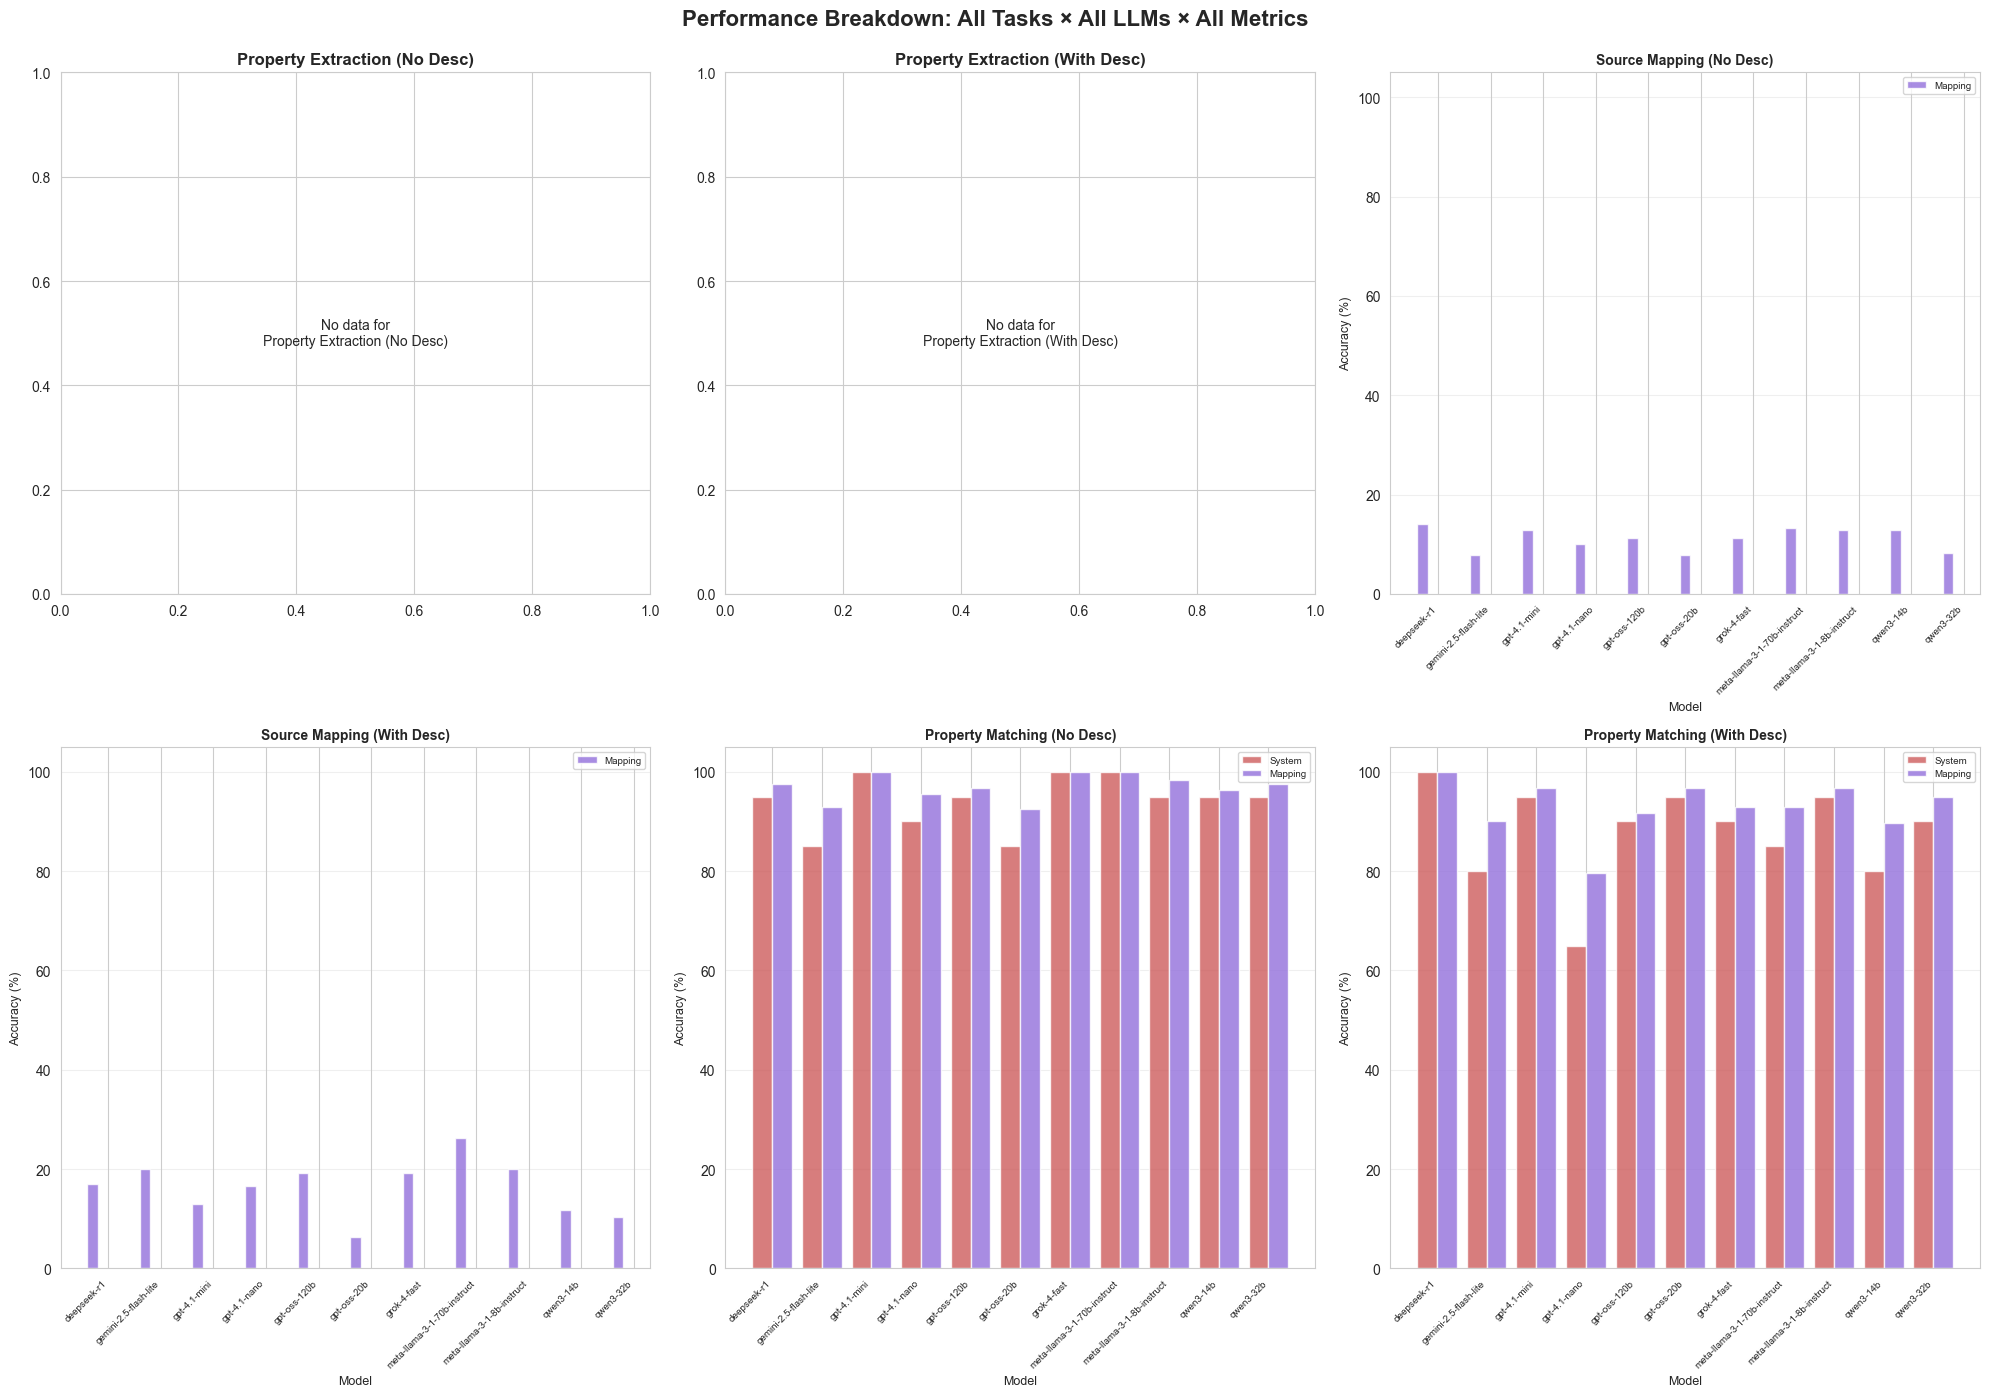

   ✅ Grid visualization successful!
   Generating source mapping dual analysis...
   ❌ Dual analysis failed: 'source_prop_exact_match_accuracy'
   Generating interactive visualization...


   ✅ Interactive visualization successful!

🎉 Visualization testing complete!


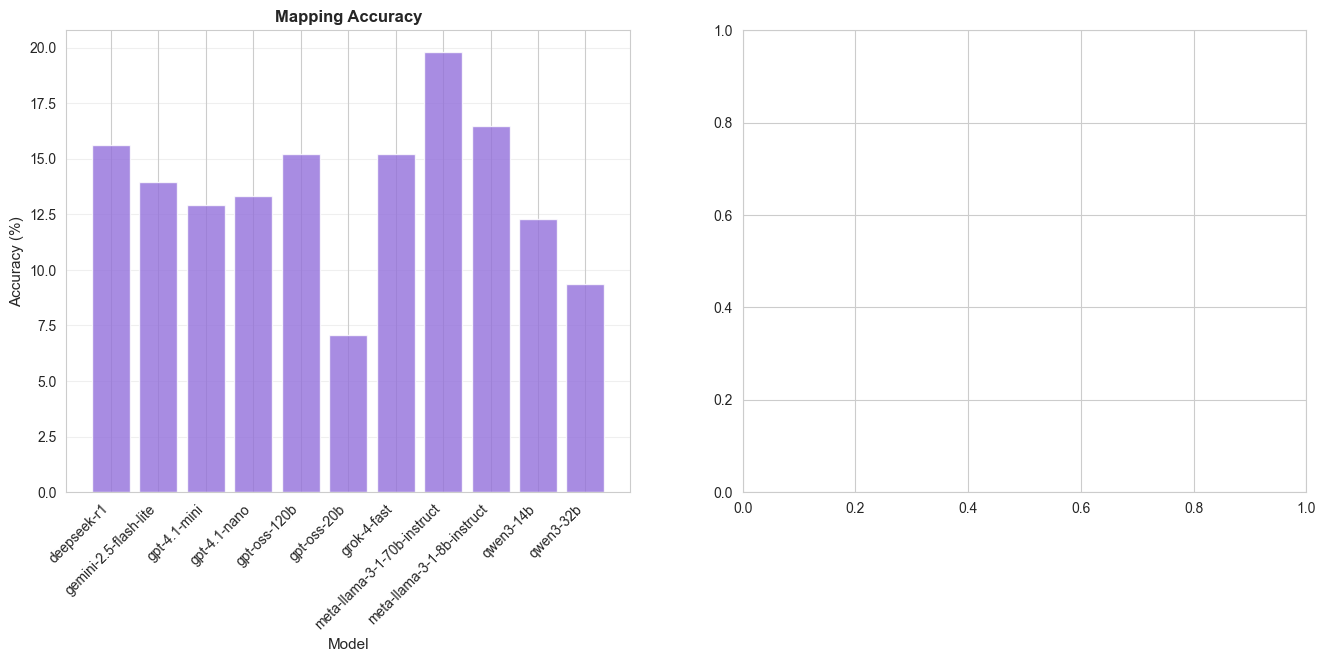

In [56]:
# Test the enhanced visualizations with your existing results

# 1. Load the test results
print("📂 Loading test results...")
df_test = load_results_data('./results_test')

print(f"✅ Loaded {len(df_test)} rows")
print(f"   Models: {df_test['model'].nunique()}")
print(f"   Tasks: {df_test['function_type'].nunique()}")
print(f"   Columns: {list(df_test.columns)}")

# 2. Check if we have source mapping data with the new metrics
source_mapping_data = df_test[df_test['task_type'] == 'Source Mapping']
if len(source_mapping_data) > 0:
    print(f"\n🎯 Found {len(source_mapping_data)} source mapping results!")
    print("   New source property metrics available:")
    source_prop_cols = [col for col in df_test.columns if col.startswith('source_prop_')]
    print(f"   {source_prop_cols}")
else:
    print("\n⚠️ No source mapping data found")

# 3. Create visualizations directory if it doesn't exist
import os
os.makedirs('./visualizations', exist_ok=True)

# 4. Test the enhanced visualizations
print("\n📊 Testing enhanced visualizations...")

# Test 1: 6-panel grid
print("   Generating 6-panel performance grid...")
try:
    plot_all_tasks_performance_grid(df_test)
    print("   ✅ Grid visualization successful!")
except Exception as e:
    print(f"   ❌ Grid visualization failed: {e}")

# Test 2: Source mapping dual analysis
print("   Generating source mapping dual analysis...")
try:
    stats = plot_source_mapping_dual_analysis(df_test, plot_type='static')
    if stats is not None:
        print("   ✅ Dual analysis successful!")
        print("   Summary statistics:")
        print(stats)
    else:
        print("   ⚠️ No source mapping data to analyze")
except Exception as e:
    print(f"   ❌ Dual analysis failed: {e}")

# Test 3: Interactive visualization
print("   Generating interactive visualization...")
try:
    plot_task_performance_interactive(df_test)
    print("   ✅ Interactive visualization successful!")
except Exception as e:
    print(f"   ❌ Interactive visualization failed: {e}")

print("\n🎉 Visualization testing complete!")


📂 Loading test results...
📂 Loading 4 file(s)...
✅ Loaded 880 rows
   Models: 11
   Function types: 4
   Unique analogies: 20
✅ Loaded 880 rows
   Models: ['gpt-oss-20b' 'gpt-oss-120b' 'gpt-4.1-mini' 'gpt-4.1-nano' 'grok-4-fast'
 'gemini-2.5-flash-lite' 'meta-llama-3-1-70b-instruct'
 'meta-llama-3-1-8b-instruct' 'deepseek-r1' 'qwen3-14b' 'qwen3-32b']
   Tasks: ['Source Mapping (No Desc)' 'Source Mapping (With Desc)'
 'Property Matching (No Desc)' 'Property Matching (With Desc)']
📁 Created output directory: ./visualizations_20251020_202910

🎨 Generating all visualizations...

1️⃣ Creating 6-panel performance grid...


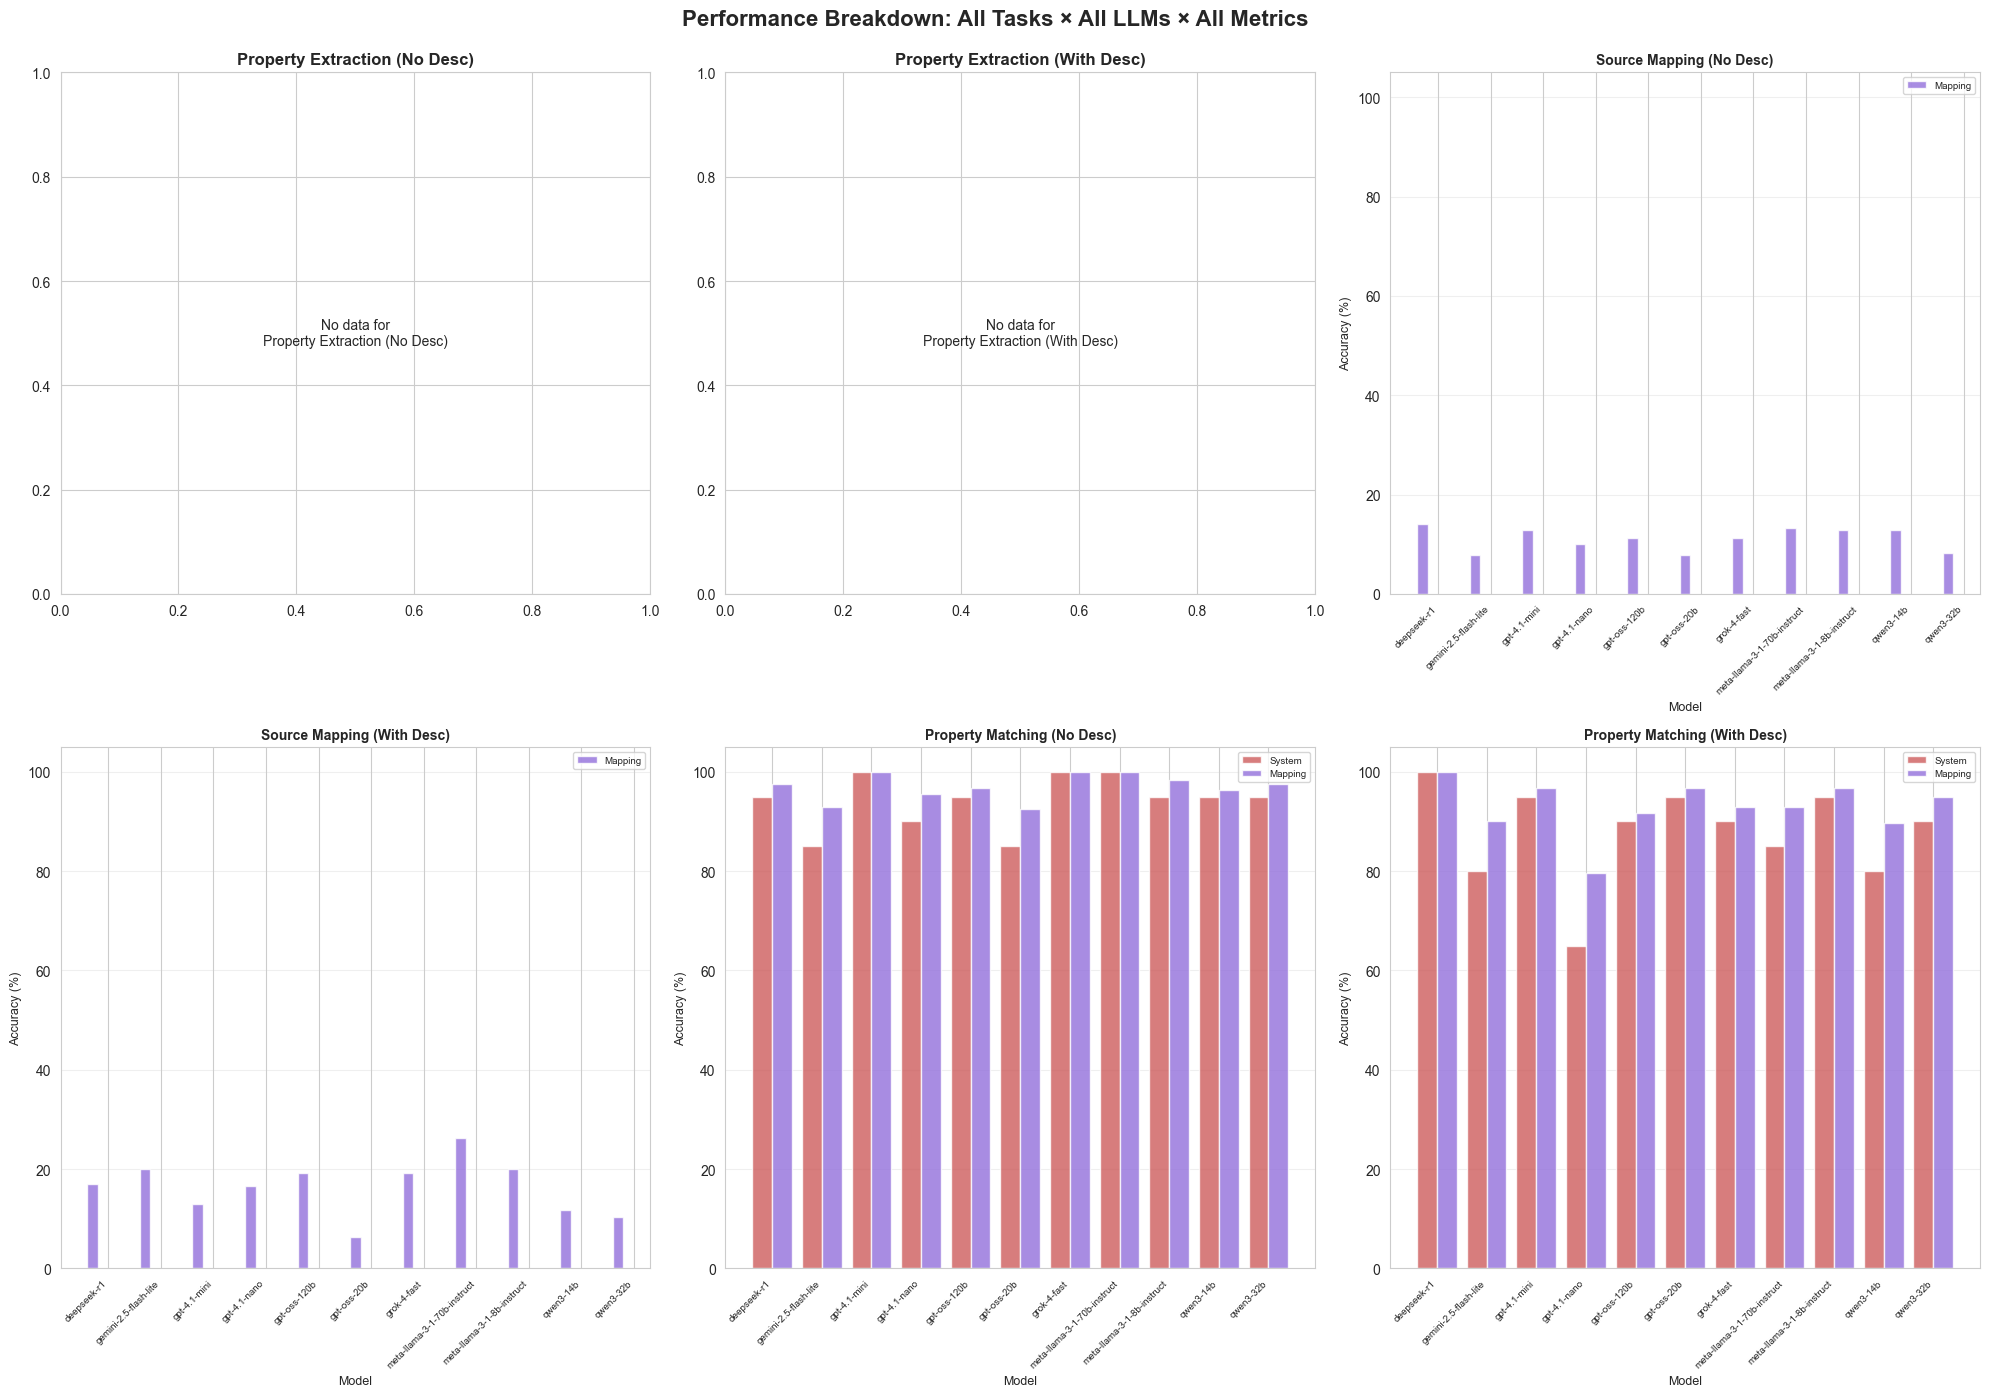

   💾 Saved: 1_performance_grid_all_tasks.png

2️⃣ Creating source mapping dual analysis...
   ❌ Dual analysis failed: 'source_prop_exact_match_accuracy'

3️⃣ Creating interactive visualization...


   💾 Saved: 3_interactive_task_selector.html

4️⃣ Creating source mapping interactive analysis...
   ❌ Source mapping interactive failed: 'source_prop_exact_match_accuracy'

📊 Generating summary statistics...
   💾 Saved: summary_statistics.csv

📈 Performance Summary:
                          model  concept_mapping_accuracy  system_accuracy  \
0                   deepseek-r1                     0.572            0.488   
1         gemini-2.5-flash-lite                     0.527            0.412   
2                  gpt-4.1-mini                     0.556            0.488   
3                  gpt-4.1-nano                     0.504            0.400   
4                  gpt-oss-120b                     0.547            0.475   
5                   gpt-oss-20b                     0.508            0.450   
6                   grok-4-fast                     0.558            0.475   
7   meta-llama-3-1-70b-instruct                     0.581            0.475   
8    meta-llama-3-1-8b-instruc

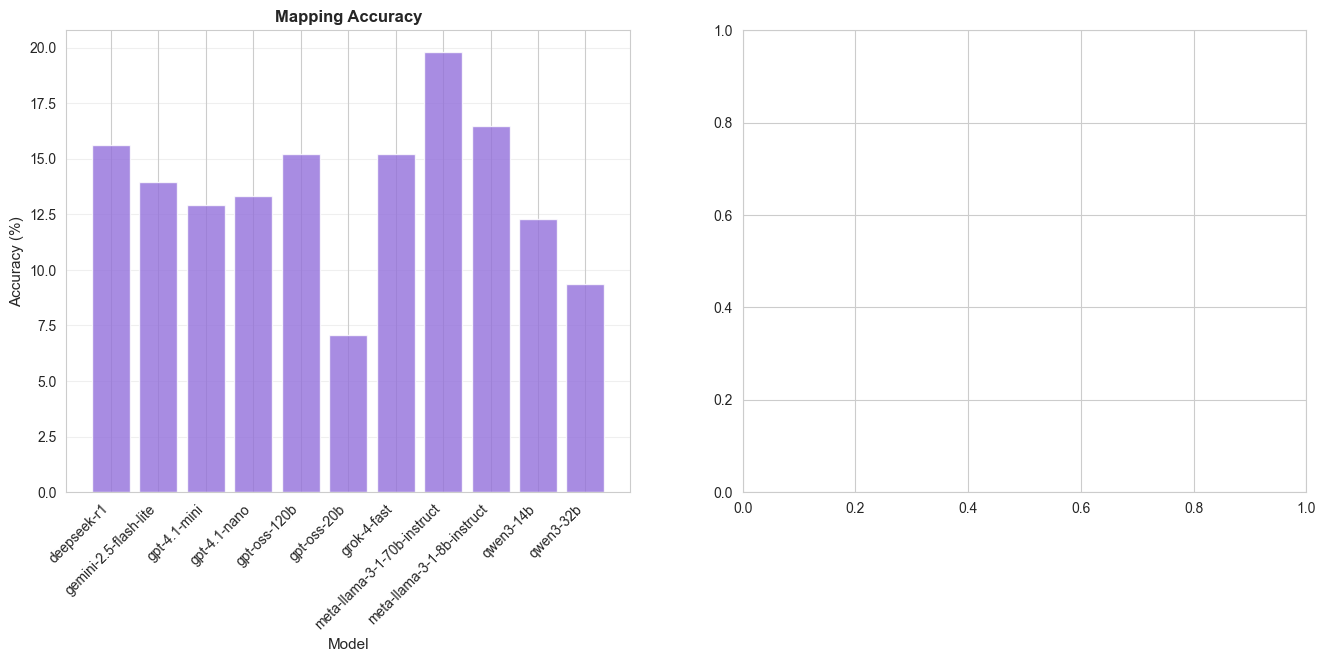

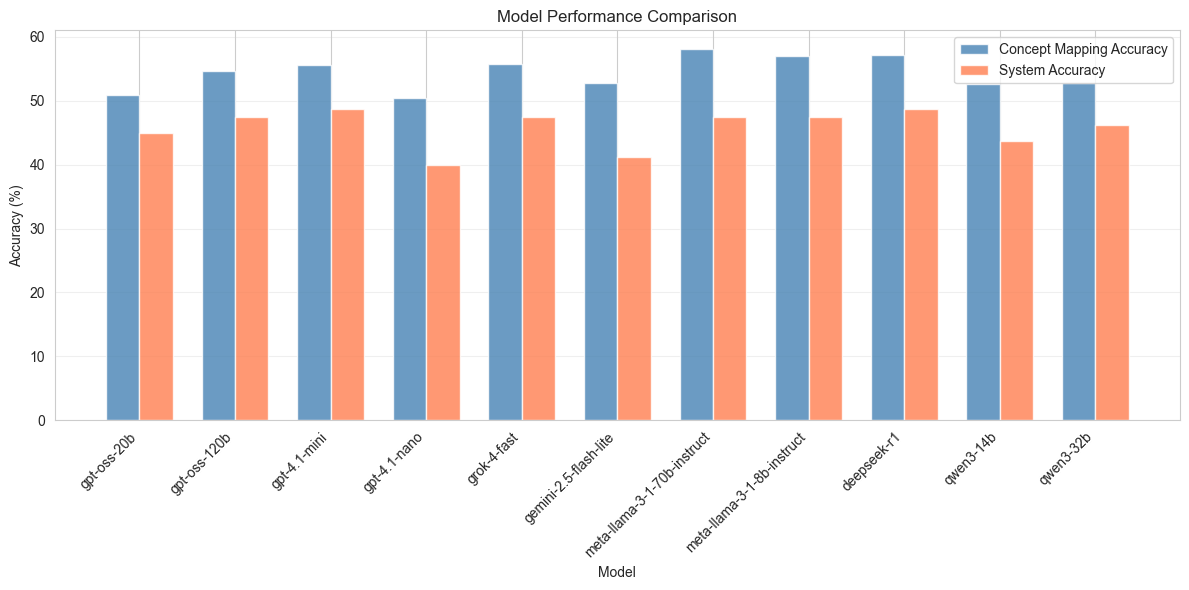


🎉 Visualization suite complete!
📁 All files saved to: ./visualizations_20251020_202910

Generated files:
   • 1_performance_grid_all_tasks.png (520.9 KB)
   • 3_interactive_task_selector.html (3526.0 KB)
   • 5_model_comparison.png (234.0 KB)
   • summary_statistics.csv (0.7 KB)

💡 To view HTML files, open them in your web browser:
   • ./visualizations_20251020_202910\3_interactive_task_selector.html


In [61]:
# Complete Visualization Suite: Show + Save All Plots

import os
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Load your results data
print("📂 Loading test results...")
df_viz = load_results_data('./results_test')

print(f"✅ Loaded {len(df_viz)} rows")
print(f"   Models: {df_viz['model'].unique()}")
print(f"   Tasks: {df_viz['function_type'].unique()}")

# 2. Create output directories
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f'./visualizations_{timestamp}'
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Created output directory: {output_dir}")

# 3. Function to save plots with proper naming
def save_plot(fig, filename, title=""):
    """Save matplotlib figure to file"""
    if fig is not None:
        save_path = os.path.join(output_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"   💾 Saved: {filename}")
        return save_path
    return None

# 4. Generate and save all visualizations
print("\n🎨 Generating all visualizations...")

# Visualization 1: 6-Panel Performance Grid
print("\n1️⃣ Creating 6-panel performance grid...")
try:
    fig_grid = plot_all_tasks_performance_grid(df_viz, figsize=(20, 14))
    save_plot(fig_grid, "1_performance_grid_all_tasks.png", "6-Panel Performance Grid")
    plt.close(fig_grid)  # Close to free memory
except Exception as e:
    print(f"   ❌ Grid visualization failed: {e}")

# Visualization 2: Source Mapping Dual Analysis (Static)
print("\n2️⃣ Creating source mapping dual analysis...")
try:
    fig_dual = plot_source_mapping_dual_analysis(df_viz, plot_type='static', figsize=(16, 6))
    if fig_dual is not None:
        save_plot(fig_dual, "2_source_mapping_dual_analysis.png", "Source Mapping Dual Analysis")
        plt.close(fig_dual)
    else:
        print("   ⚠️ No source mapping data found")
except Exception as e:
    print(f"   ❌ Dual analysis failed: {e}")

# Visualization 3: Interactive Plotly Visualization (saves as HTML)
print("\n3️⃣ Creating interactive visualization...")
try:
    fig_interactive = plot_task_performance_interactive(df_viz)
    if fig_interactive is not None:
        html_path = os.path.join(output_dir, "3_interactive_task_selector.html")
        fig_interactive.write_html(html_path)
        print(f"   💾 Saved: 3_interactive_task_selector.html")
except Exception as e:
    print(f"   ❌ Interactive visualization failed: {e}")

# Visualization 4: Source Mapping Interactive (if data exists)
print("\n4️⃣ Creating source mapping interactive analysis...")
try:
    source_df = df_viz[df_viz['task_type'] == 'Source Mapping']
    if len(source_df) > 0:
        fig_source_interactive = plot_source_mapping_dual_analysis(df_viz, plot_type='interactive')
        if fig_source_interactive is not None:
            html_path = os.path.join(output_dir, "4_source_mapping_interactive.html")
            fig_source_interactive.write_html(html_path)
            print(f"   💾 Saved: 4_source_mapping_interactive.html")
    else:
        print("   ⚠️ No source mapping data for interactive plot")
except Exception as e:
    print(f"   ❌ Source mapping interactive failed: {e}")

# 5. Generate summary statistics
print("\n📊 Generating summary statistics...")
try:
    # Overall performance by model
    model_stats = df_viz.groupby('model').agg({
        'concept_mapping_accuracy': 'mean',
        'system_accuracy': 'mean',
        'duration_seconds': 'mean'
    }).reset_index()
    
    # Save summary to CSV
    summary_path = os.path.join(output_dir, "summary_statistics.csv")
    model_stats.to_csv(summary_path, index=False)
    print(f"   💾 Saved: summary_statistics.csv")
    
    # Print summary
    print("\n📈 Performance Summary:")
    print(model_stats.round(3))
    
except Exception as e:
    print(f"   ❌ Summary generation failed: {e}")

# 6. Create a simple performance comparison plot
print("\n5️⃣ Creating model comparison plot...")
try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    models = df_viz['model'].unique()
    mapping_acc = [df_viz[df_viz['model'] == m]['concept_mapping_accuracy'].mean() * 100 for m in models]
    system_acc = [df_viz[df_viz['model'] == m]['system_accuracy'].mean() * 100 for m in models]
    
    x = range(len(models))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], mapping_acc, width, label='Concept Mapping Accuracy', alpha=0.8, color='steelblue')
    ax.bar([i + width/2 for i in x], system_acc, width, label='System Accuracy', alpha=0.8, color='coral')
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, "5_model_comparison.png", "Model Performance Comparison")
    plt.show()
    plt.close(fig)
    
except Exception as e:
    print(f"   ❌ Model comparison failed: {e}")

# 7. Final summary
print(f"\n🎉 Visualization suite complete!")
print(f"📁 All files saved to: {output_dir}")
print(f"\nGenerated files:")
for file in os.listdir(output_dir):
    file_path = os.path.join(output_dir, file)
    size = os.path.getsize(file_path) / 1024  # KB
    print(f"   • {file} ({size:.1f} KB)")

print(f"\n💡 To view HTML files, open them in your web browser:")
print(f"   • {os.path.join(output_dir, '3_interactive_task_selector.html')}")
if os.path.exists(os.path.join(output_dir, '4_source_mapping_interactive.html')):
    print(f"   • {os.path.join(output_dir, '4_source_mapping_interactive.html')}")


In [57]:
### Utility Functions

def save_all_plots(df, output_dir='./visualizations', formats=['png', 'pdf']):
    """
    Generate and save all visualization plots
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"📊 Generating all plots to {output_dir}...")
    
    # Temporarily disable interactive mode
    plt.ioff()
    
    plots_to_generate = [
        ('model_performance', lambda: plot_model_performance(df, plot_type='static')),
        ('size_vs_performance', lambda: plot_size_vs_performance(df, plot_type='static')),
        ('function_comparison', lambda: plot_function_comparison(df, plot_type='static')),
        ('accuracy_distribution_by_model', lambda: plot_accuracy_distribution(df, plot_type='static', by='model')),
        ('accuracy_distribution_by_function', lambda: plot_accuracy_distribution(df, plot_type='static', by='function_type')),
        ('performance_vs_time', lambda: plot_performance_vs_time(df, plot_type='static')),
        ('model_function_heatmap', lambda: plot_model_function_heatmap(df, plot_type='static')),
        ('error_analysis', lambda: plot_error_analysis(df)),
    ]
    
    # Add description impact if applicable
    if df['has_description'].nunique() == 2:
        plots_to_generate.append(
            ('description_impact', lambda: plot_description_impact(df, plot_type='static'))
        )
    
    # Add model-task heatmap if not too large
    if df['analogy_pair'].nunique() <= 20:
        plots_to_generate.append(
            ('model_task_heatmap', lambda: plot_model_task_heatmap(df, plot_type='static'))
        )
    
    saved_files = []
    for name, plot_func in plots_to_generate:
        try:
            print(f"  Generating {name}...")
            plt.close('all')
            plot_func()
            
            for fmt in formats:
                save_path = os.path.join(output_dir, f"{name}.{fmt}")
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                saved_files.append(save_path)
            
            plt.close('all')
        except Exception as e:
            print(f"  ⚠️ Error generating {name}: {str(e)}")
    
    # Generate summary dashboard
    try:
        print(f"  Generating summary dashboard...")
        for fmt in formats:
            save_path = os.path.join(output_dir, f"summary_dashboard.{fmt}")
            create_summary_dashboard(df, save_path=save_path)
            saved_files.append(save_path)
    except Exception as e:
        print(f"  ⚠️ Error generating dashboard: {str(e)}")
    
    # Re-enable interactive mode
    plt.ion()
    
    print(f"\n✅ Generated {len(saved_files)} files in {output_dir}")
    return saved_files


def compare_experiments(df1, df2, labels=['Experiment 1', 'Experiment 2'], figsize=(14, 6)):
    """
    Compare results from two different experiment runs
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Prepare data
    for idx, (df, label) in enumerate([(df1, labels[0]), (df2, labels[1])]):
        model_stats = df.groupby('model').agg({
            'concept_mapping_accuracy': 'mean'
        }).reset_index().sort_values('concept_mapping_accuracy')
        
        # System Accuracy comparison
        axes[0].barh(np.arange(len(model_stats)) + idx * 0.35, 
                    model_stats['concept_mapping_accuracy'] * 100,
                    height=0.35, label=label, alpha=0.8)
    
    axes[0].set_xlabel('Concept Mapping Accuracy (%)', fontsize=11)
    axes[0].set_title('Model Performance Comparison', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Function type comparison
    for idx, (df, label) in enumerate([(df1, labels[0]), (df2, labels[1])]):
        func_stats = df.groupby('function_type').agg({
            'concept_mapping_accuracy': 'mean'
        }).reset_index()
        
        axes[1].bar(np.arange(len(func_stats)) + idx * 0.35,
                   func_stats['concept_mapping_accuracy'] * 100,
                   width=0.35, label=label, alpha=0.8)
    
    axes[1].set_ylabel('Concept Mapping Accuracy (%)', fontsize=11)
    axes[1].set_title('Function Type Comparison', fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def export_summary_stats(df, output_path='summary_stats.csv'):
    """
    Export aggregated statistics to CSV
    """
    # Model-level stats
    model_stats = df.groupby('model').agg({
        'system_accuracy': ['mean', 'std', 'count'],
        'concept_mapping_accuracy': ['mean', 'std'],
        'correct_mappings': 'sum',
        'total_mappings': 'sum',
        'duration_seconds': ['mean', 'std'],
        'success': 'mean'
    }).reset_index()
    
    model_stats.columns = ['_'.join(col).strip('_') for col in model_stats.columns.values]
    
    # Function-level stats
    func_stats = df.groupby('function_type').agg({
        'system_accuracy': ['mean', 'std'],
        'concept_mapping_accuracy': ['mean', 'std'],
        'duration_seconds': ['mean', 'std']
    }).reset_index()
    
    func_stats.columns = ['_'.join(col).strip('_') for col in func_stats.columns.values]
    
    # Save with multi-sheet if possible, otherwise save separately
    try:
        with pd.ExcelWriter(output_path.replace('.csv', '.xlsx')) as writer:
            model_stats.to_excel(writer, sheet_name='Model_Stats', index=False)
            func_stats.to_excel(writer, sheet_name='Function_Stats', index=False)
        print(f"✅ Summary stats saved to: {output_path.replace('.csv', '.xlsx')}")
    except:
        model_stats.to_csv(output_path, index=False)
        func_stats.to_csv(output_path.replace('.csv', '_functions.csv'), index=False)
        print(f"✅ Summary stats saved to: {output_path} and {output_path.replace('.csv', '_functions.csv')}")
    
    return model_stats, func_stats

print("✅ Utility functions ready!")


✅ Utility functions ready!


Loading test results...
📂 Loading 4 file(s)...
✅ Loaded 880 rows
   Models: 11
   Function types: 4
   Unique analogies: 20

✅ Data loaded successfully!
   Rows: 880
   Models: ['gpt-oss-20b', 'gpt-oss-120b', 'gpt-4.1-mini', 'gpt-4.1-nano', 'grok-4-fast', 'gemini-2.5-flash-lite', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'deepseek-r1', 'qwen3-14b', 'qwen3-32b']
   Functions: ['Source Mapping (No Desc)', 'Source Mapping (With Desc)', 'Property Matching (No Desc)', 'Property Matching (With Desc)']
   Analogies: ['biological clock → clock', 'Biosphere → Library', 'Respiratory system → engine', 'Spread of Pathogens → Spread of Fire', 'Gene editing → kirigami', 'Water Cycle → Circular Economy', "Cell division → the factory's production line", 'Origin of Life → Chemical Reactions', 'The Genetic Code → The Writing System', 'Ecosystem → Machines', 'Nervous System → Circuits', 'Immune System → Army', 'Cell Membranes → Walls', 'Protein folding → a three-dimensional puzzle', 'P

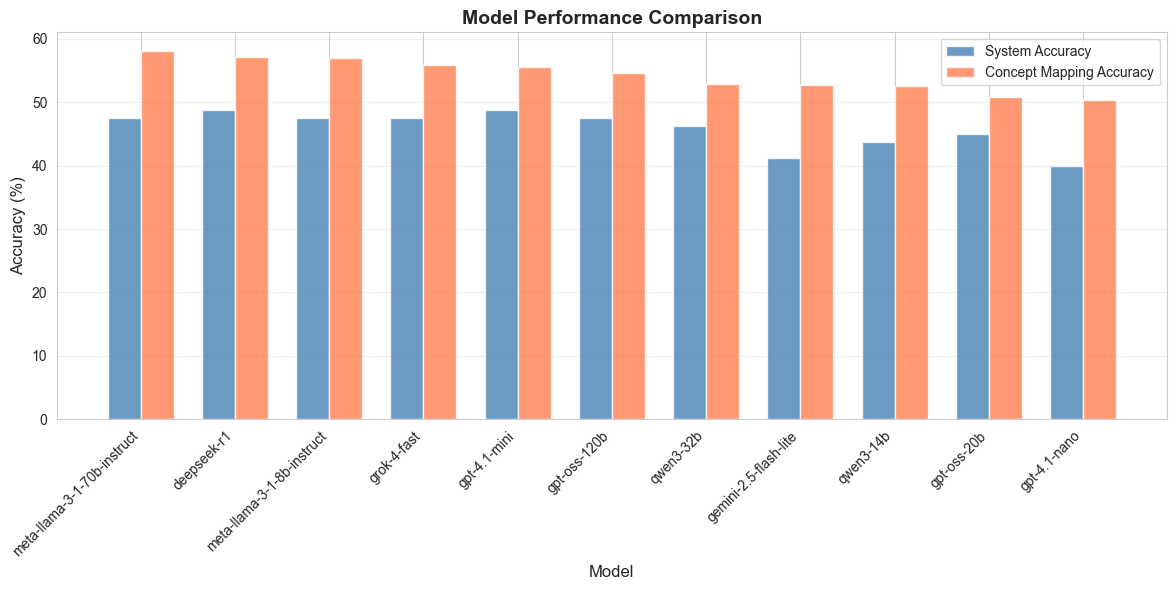

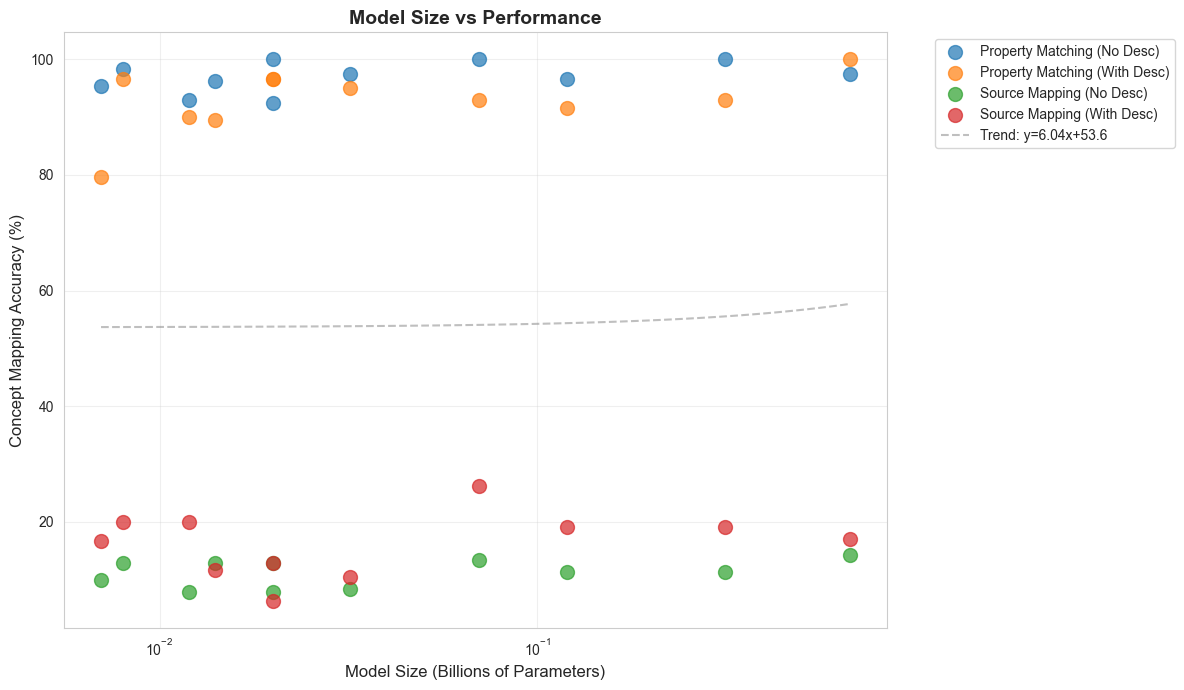

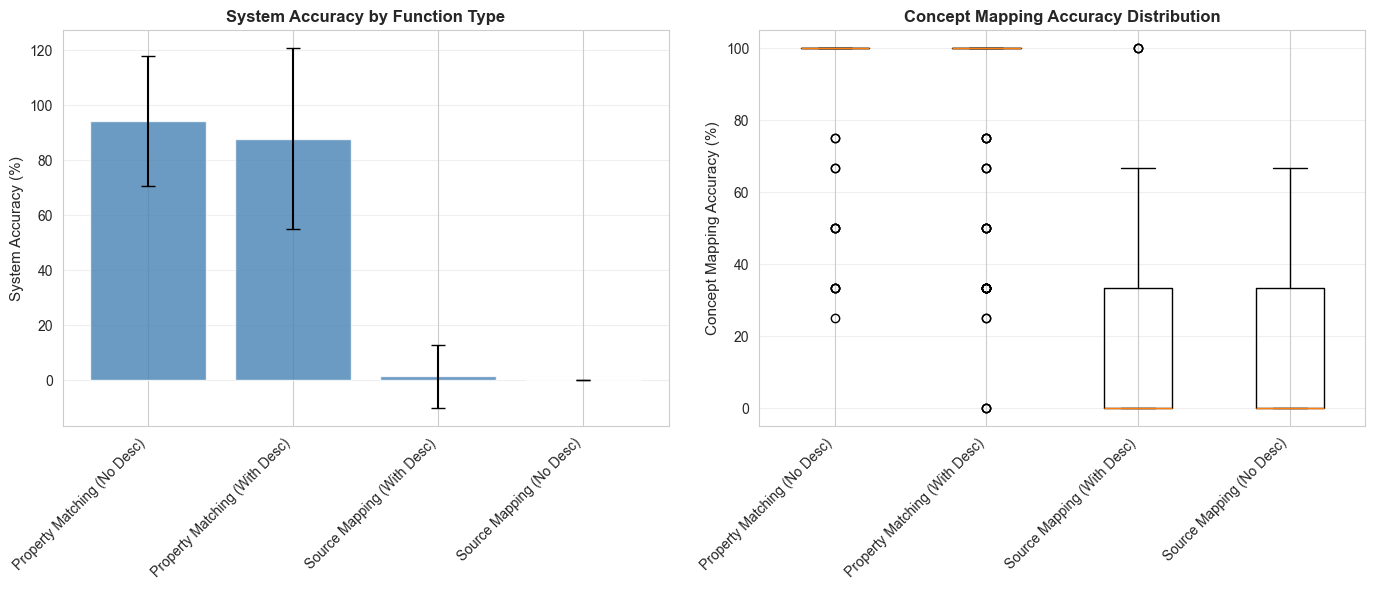

✅ Dashboard saved to: ./visualizations/dashboard.png


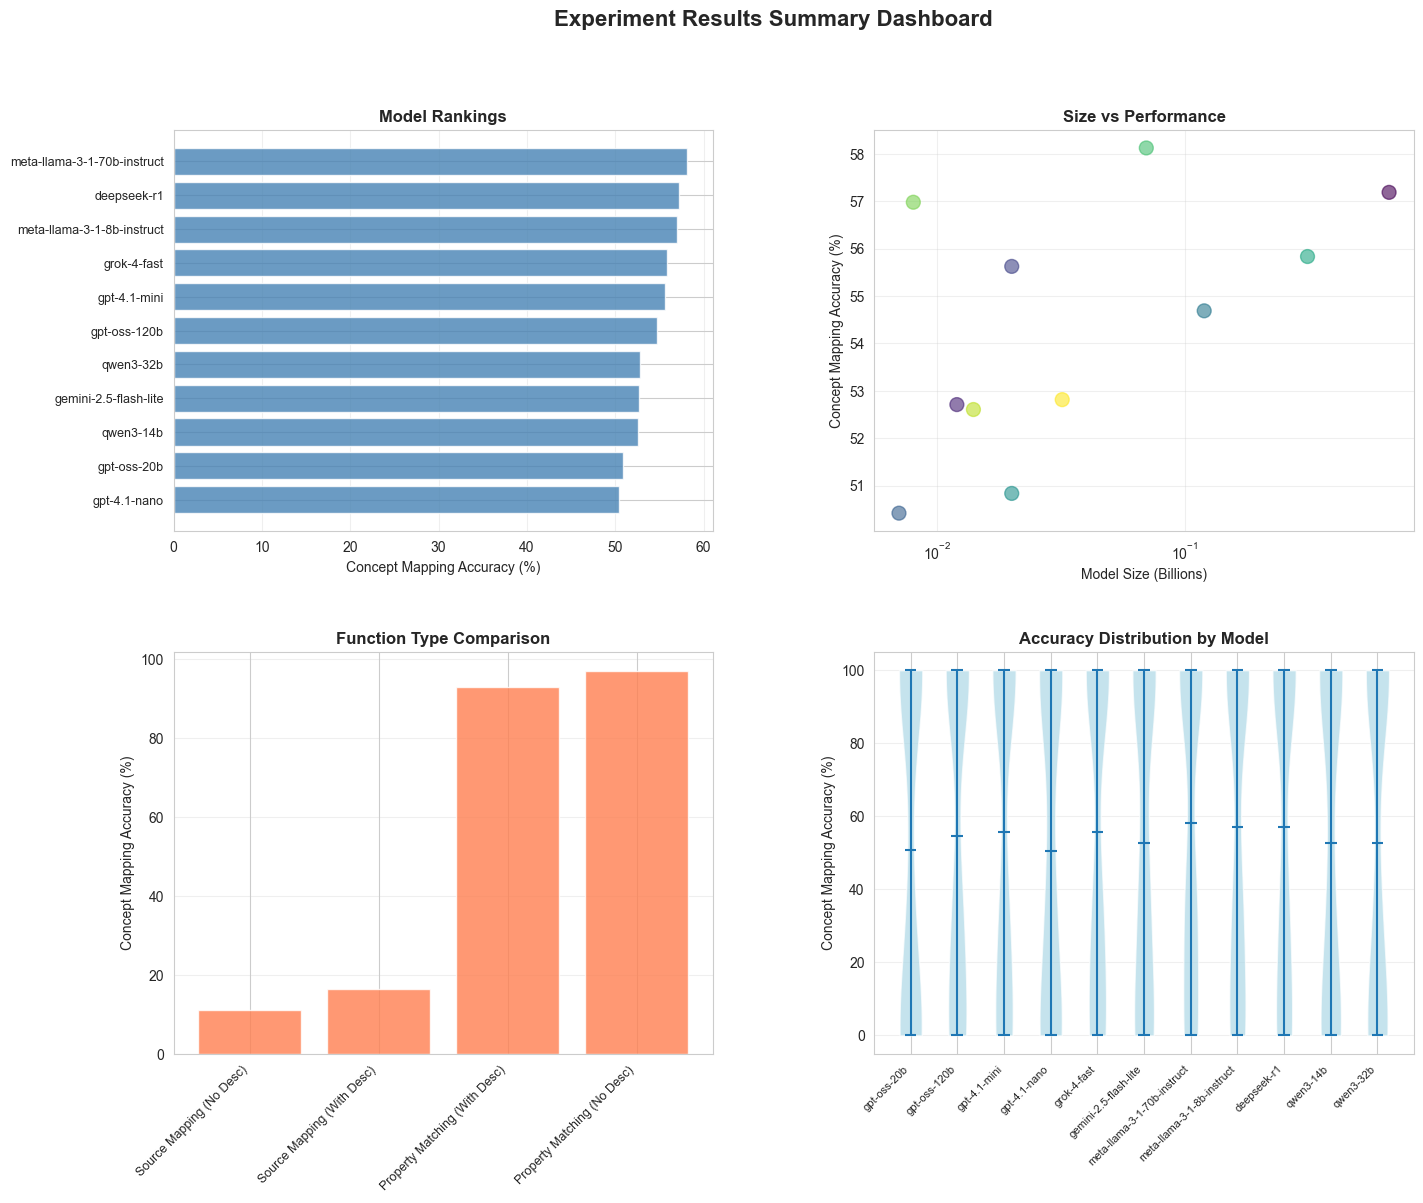

📊 Generating all plots to ./visualizations...
  Generating model_performance...


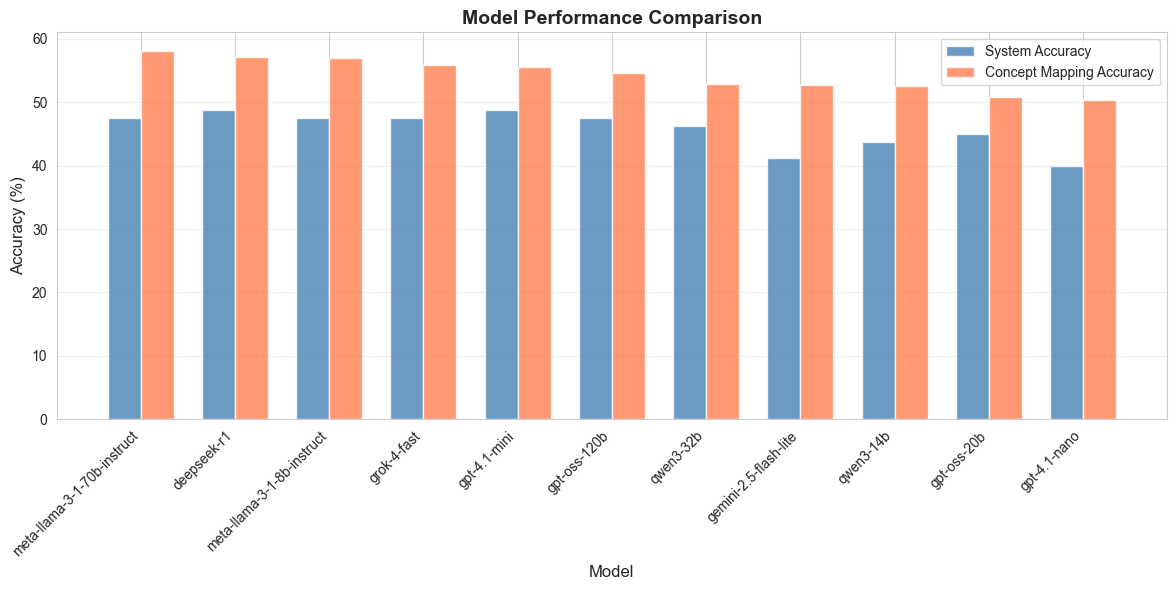

  Generating size_vs_performance...


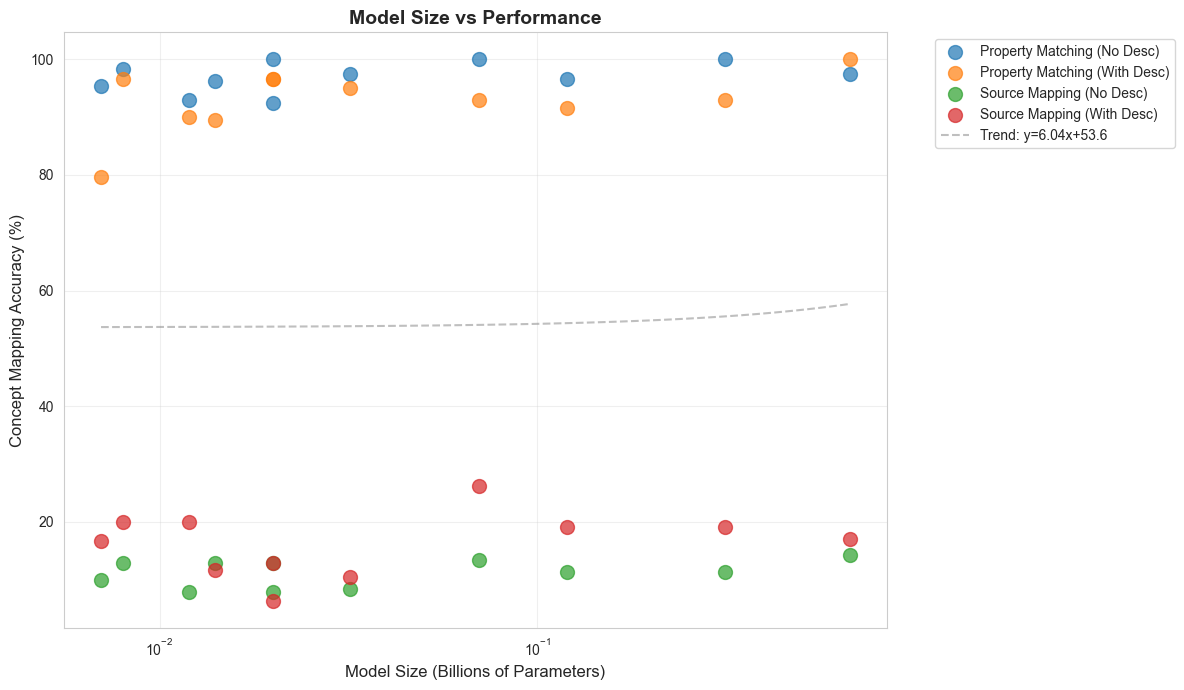

  Generating function_comparison...


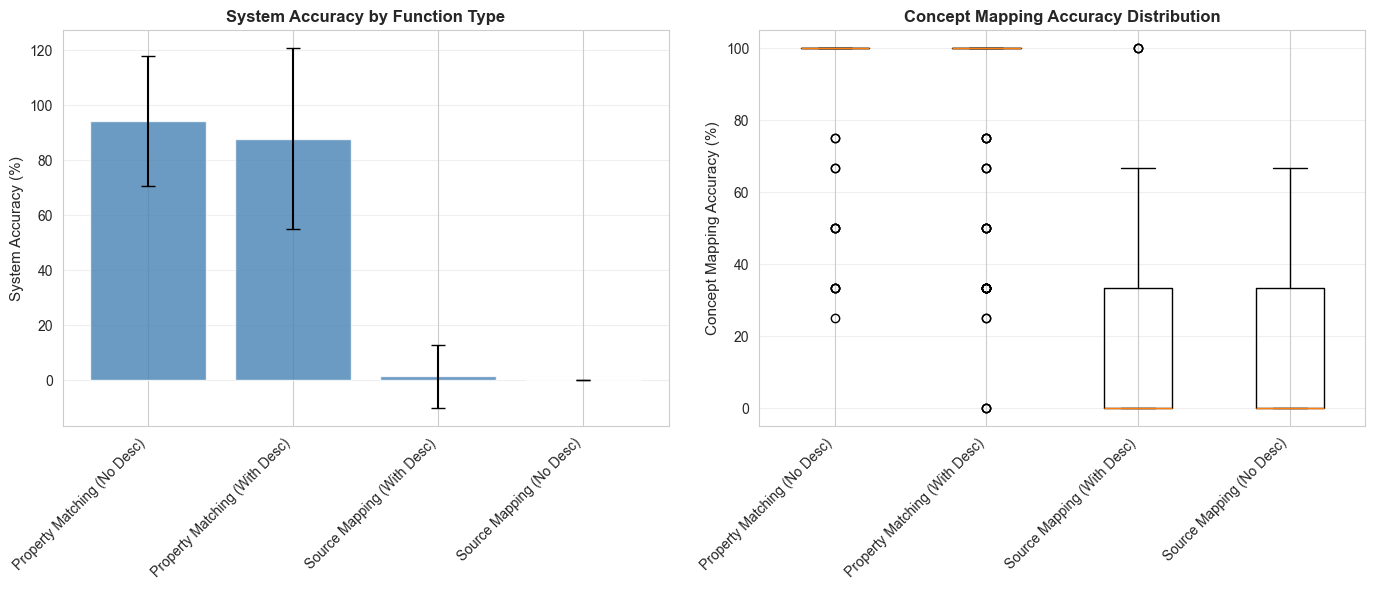

  Generating accuracy_distribution_by_model...


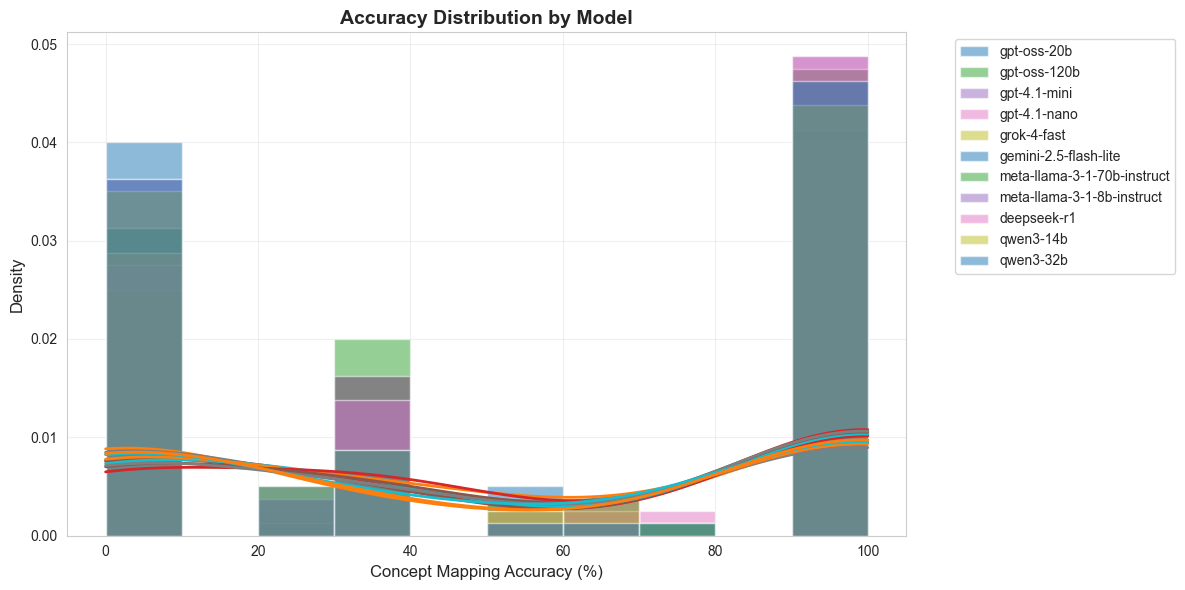

  Generating accuracy_distribution_by_function...


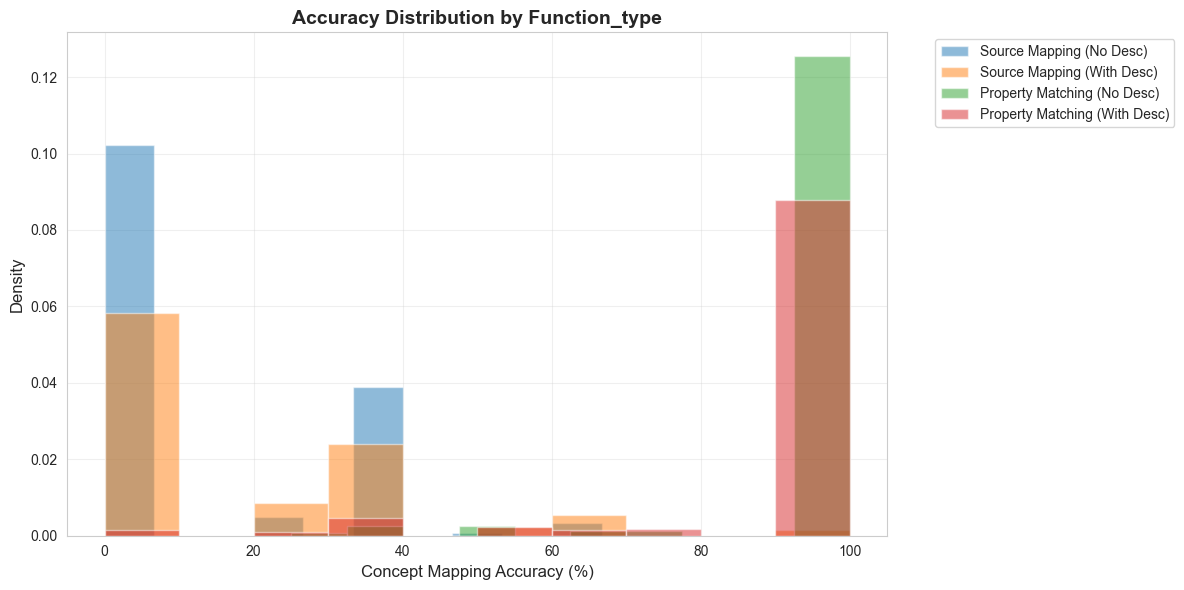

  Generating performance_vs_time...


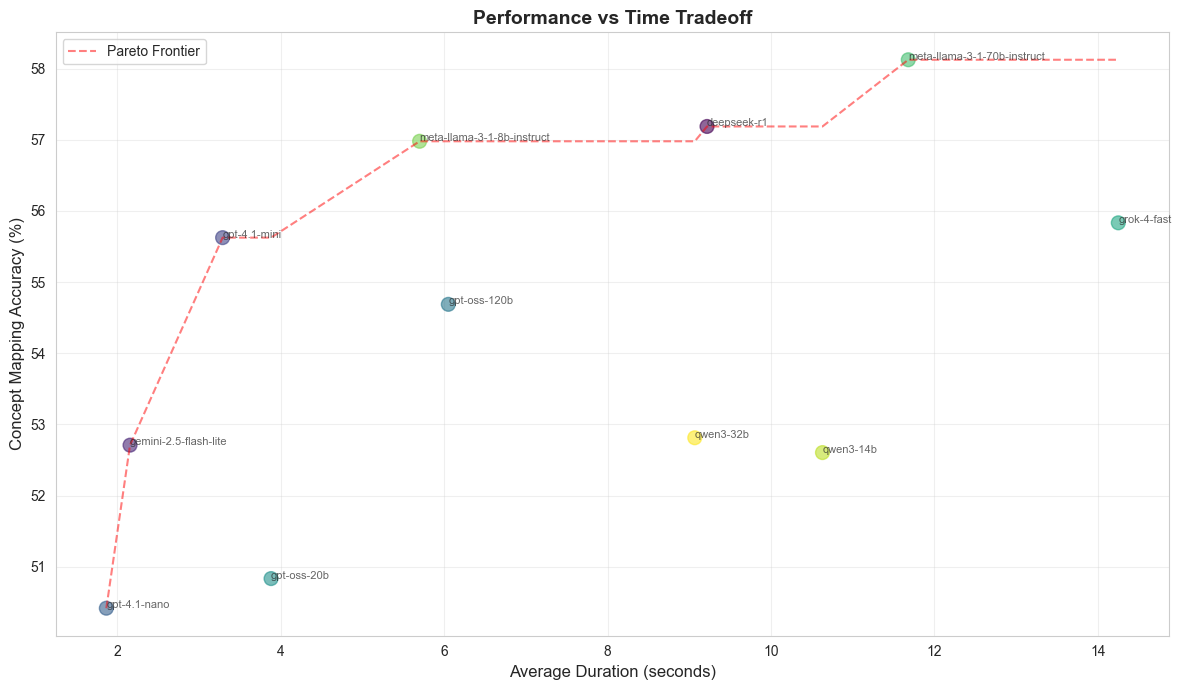

  Generating model_function_heatmap...


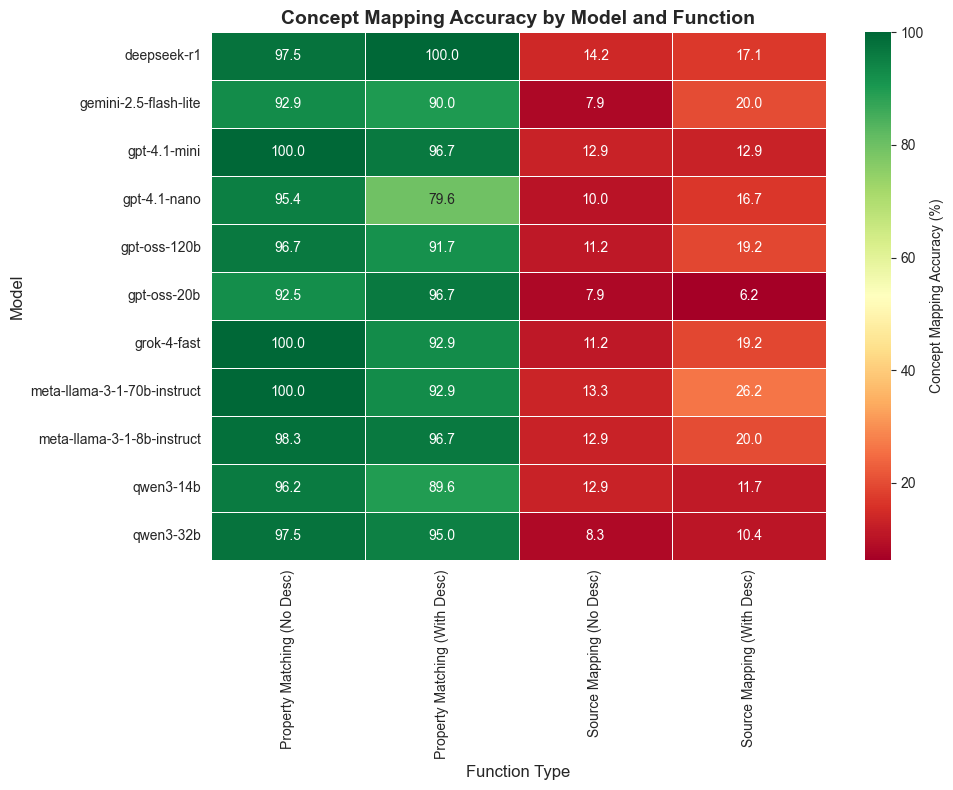

  Generating error_analysis...


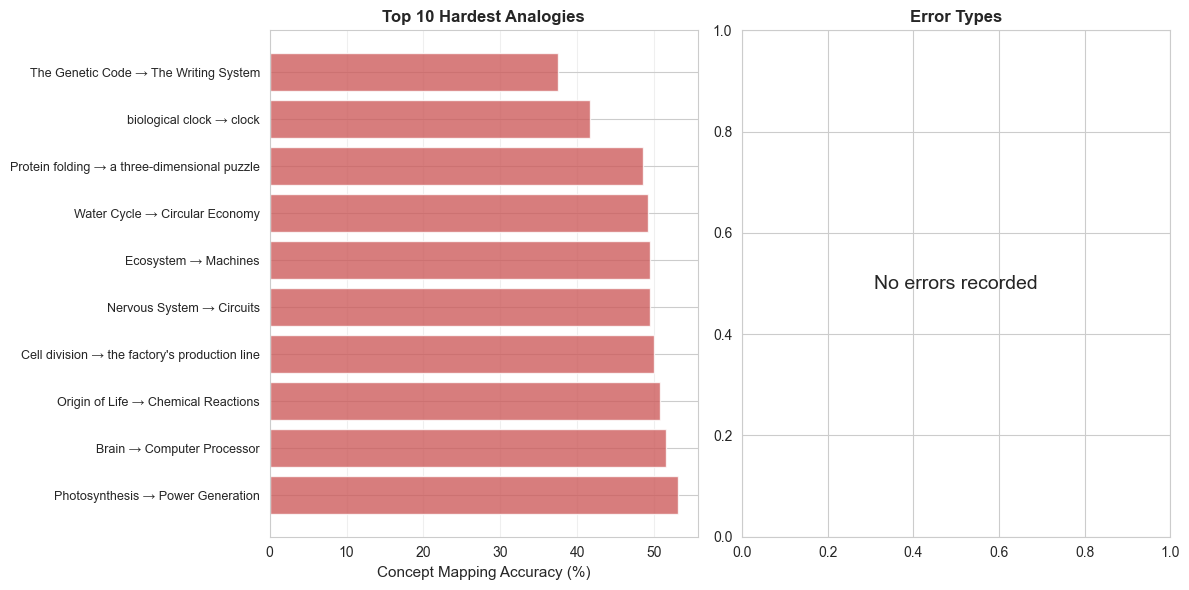

  Generating description_impact...


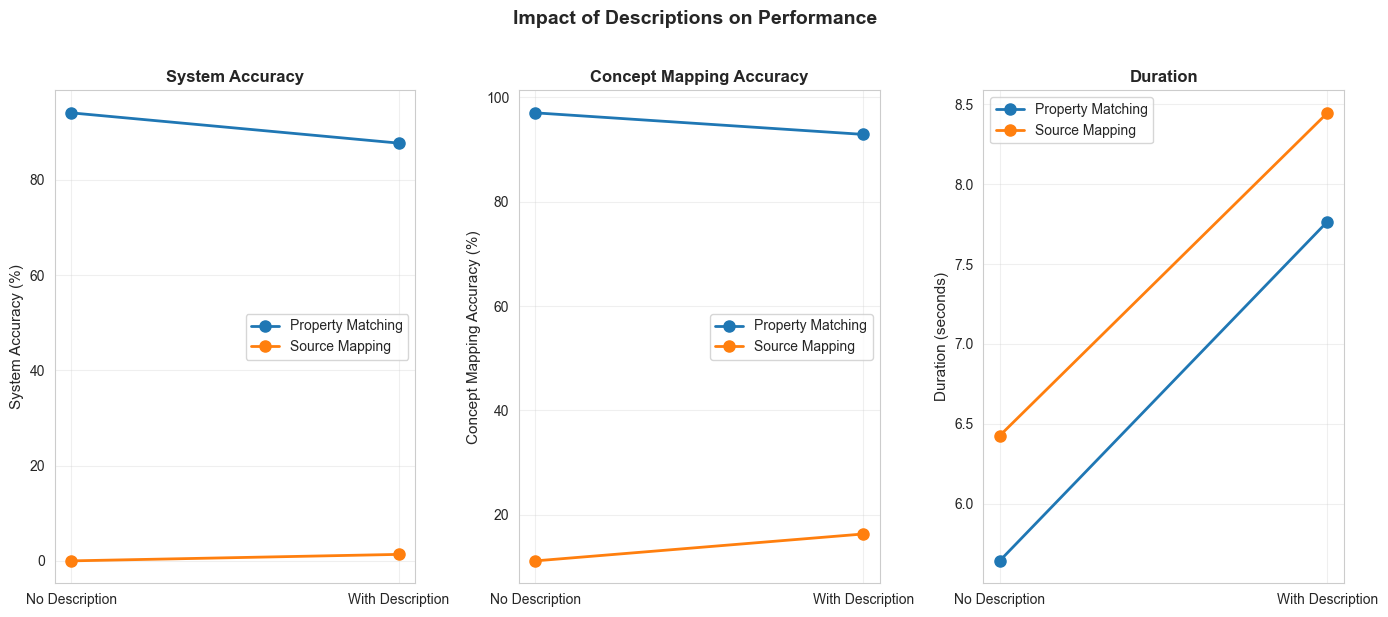

  Generating model_task_heatmap...


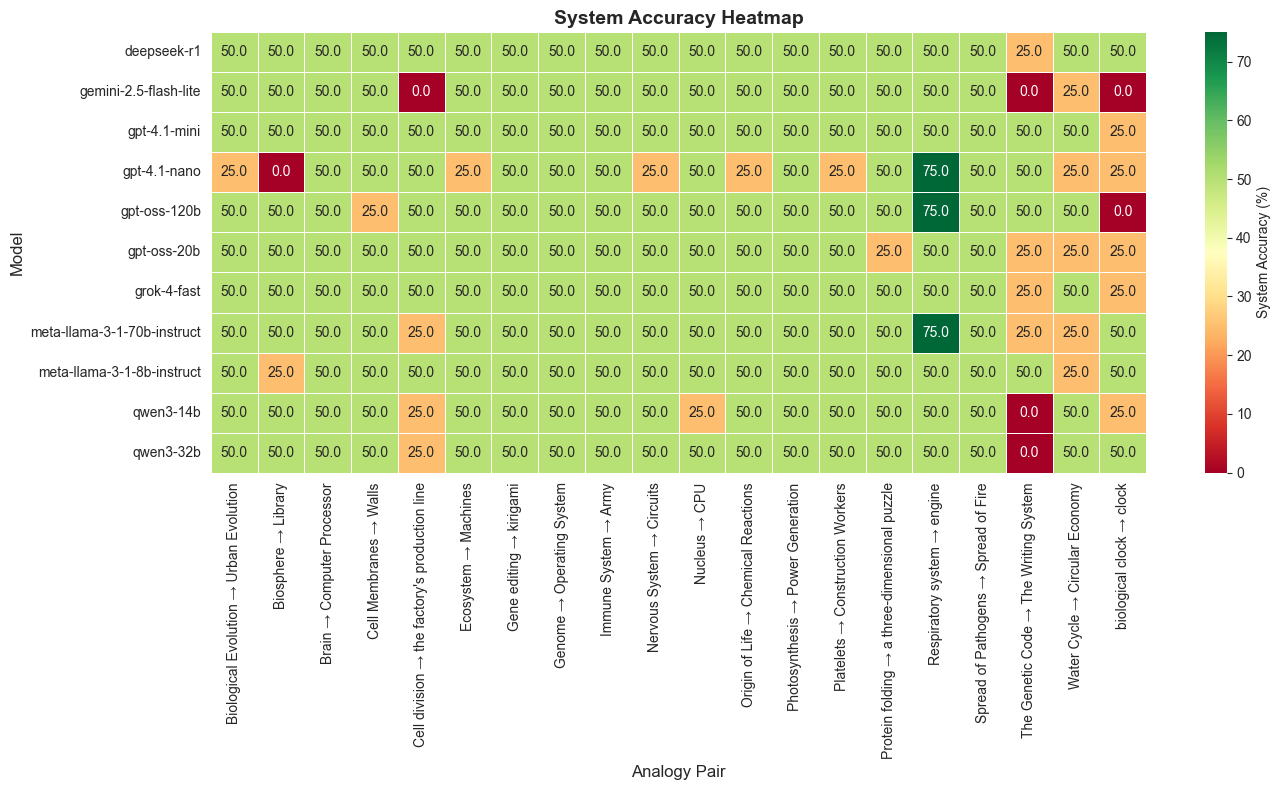

  Generating summary dashboard...
✅ Dashboard saved to: ./visualizations\summary_dashboard.png


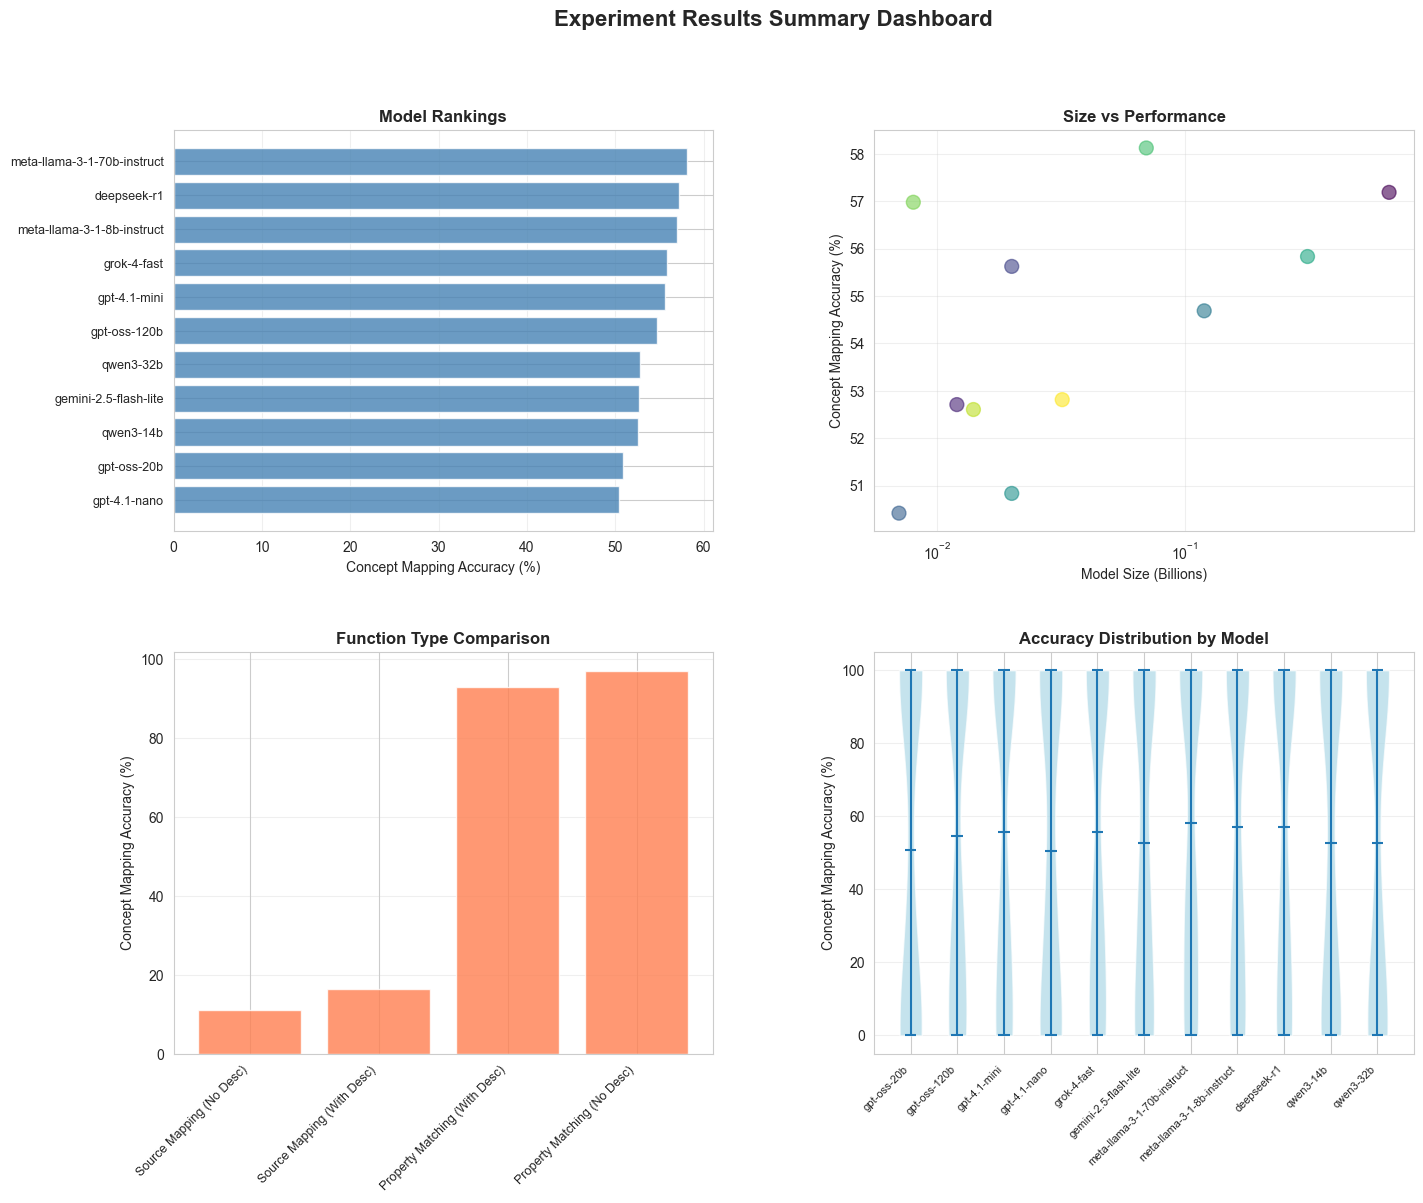

✅ Dashboard saved to: ./visualizations\summary_dashboard.pdf


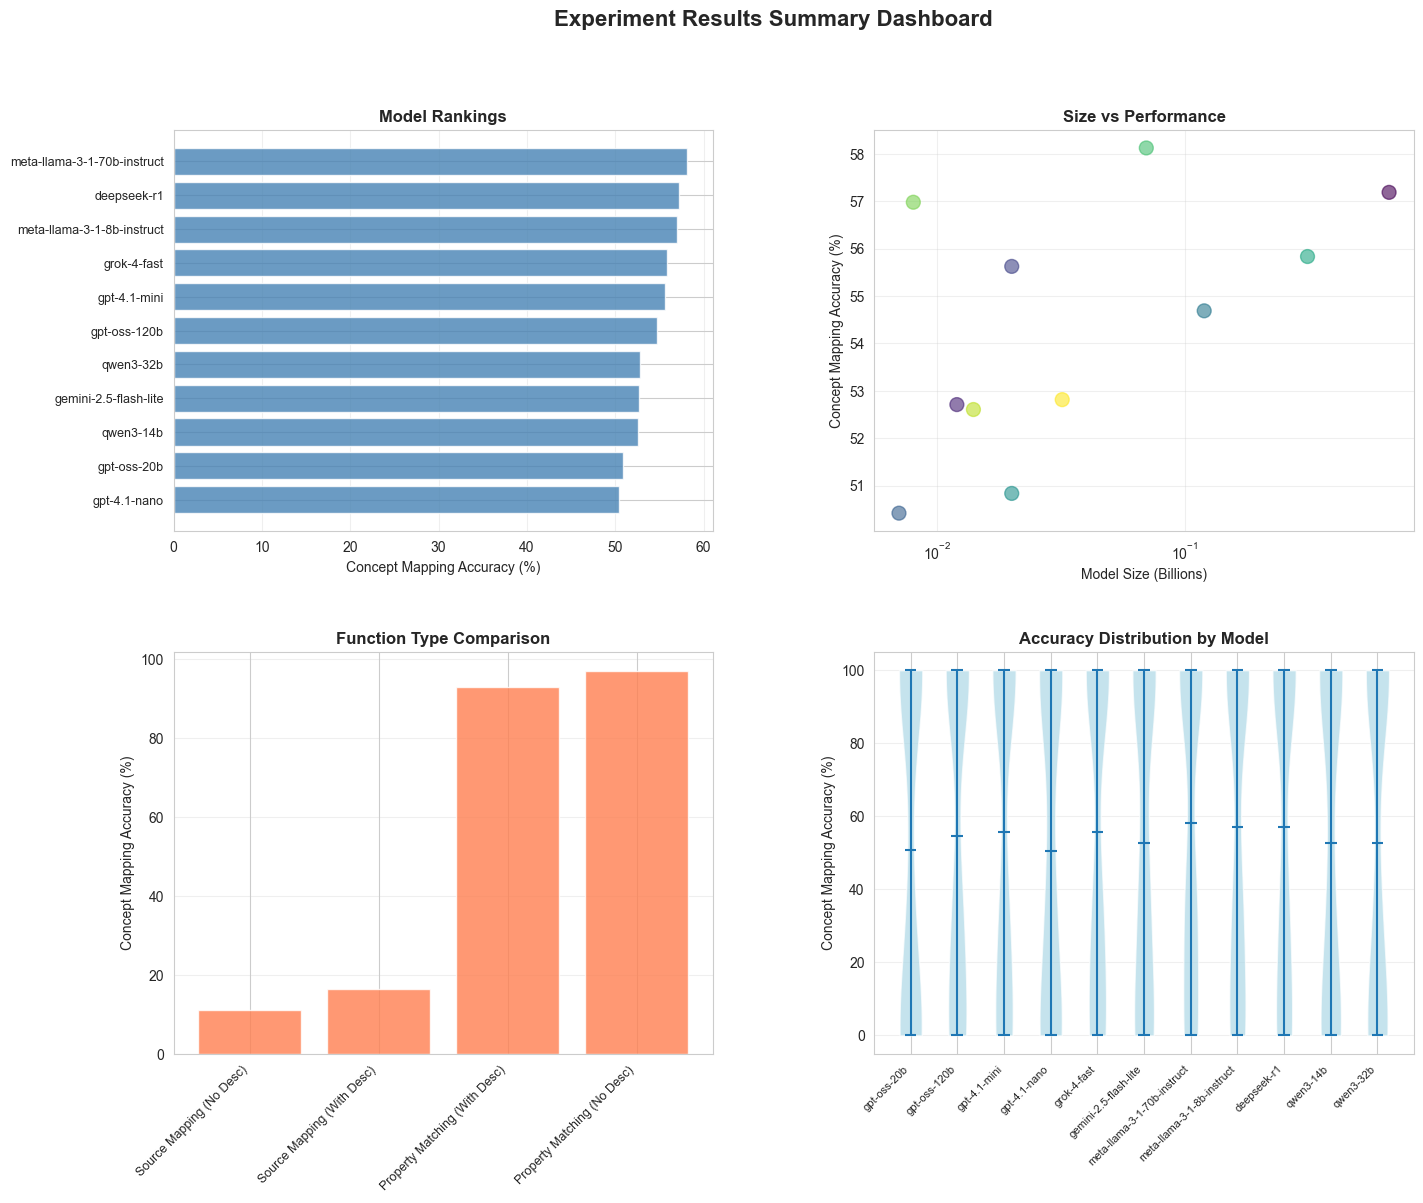


✅ Generated 22 files in ./visualizations


In [58]:
### 🧪 Test Visualizations on Current Data

# Load test data
print("Loading test results...")
try:
    df_test = load_results_data('./results_test')
    
    print(f"\n✅ Data loaded successfully!")
    print(f"   Rows: {len(df_test)}")
    print(f"   Models: {df_test['model'].unique().tolist()}")
    print(f"   Functions: {df_test['function_type'].unique().tolist()}")
    print(f"   Analogies: {df_test['analogy_pair'].unique().tolist()}")
    
    print("\n" + "="*80)
    print("Ready to visualize! Uncomment examples below to test:")
    print("="*80)
    
    plot_model_performance(df_test, plot_type='both')
    plot_size_vs_performance(df_test, plot_type='both')
    plot_function_comparison(df_test, plot_type='both')
    create_summary_dashboard(df_test, save_path='./visualizations/dashboard.png')
    create_interactive_dashboard(df_test)
    save_all_plots(df_test, output_dir='./visualizations', formats=['png', 'pdf'])
    
except Exception as e:
    print(f"⚠️ Could not load test data: {str(e)}")
    print("Make sure you have run experiments first and have data in './results_test2' folder")


In [59]:
### Enhanced Task-Specific Visualization Functions

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np

def plot_all_tasks_performance_grid(df, figsize=(20, 14)):
    """
    6-panel grid showing each task with all LLMs and all metrics side-by-side
    Color-coded bars for different metric types
    """
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    tasks = [
        ('Property Extraction (No Desc)', 'Property Extraction', ['exact_match_accuracy', 'fuzzy_match_accuracy', 'semantic_match_accuracy', 'overall_accuracy_weighted']),
        ('Property Extraction (With Desc)', 'Property Extraction', ['exact_match_accuracy', 'fuzzy_match_accuracy', 'semantic_match_accuracy', 'overall_accuracy_weighted']),
        ('Source Mapping (No Desc)', 'Source Mapping', ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy', 'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy']),
        ('Source Mapping (With Desc)', 'Source Mapping', ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy', 'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy']),
        ('Property Matching (No Desc)', 'Property Matching', ['system_accuracy', 'concept_mapping_accuracy']),
        ('Property Matching (With Desc)', 'Property Matching', ['system_accuracy', 'concept_mapping_accuracy'])
    ]
    
    colors = {
        'exact_match_accuracy': 'steelblue',
        'fuzzy_match_accuracy': 'coral',
        'semantic_match_accuracy': 'lightgreen',
        'overall_accuracy_weighted': 'gold',
        'concept_mapping_accuracy': 'mediumpurple',
        'system_accuracy': 'indianred',
        'source_prop_exact_match_accuracy': 'steelblue',
        'source_prop_fuzzy_match_accuracy': 'coral',
        'source_prop_semantic_match_accuracy': 'lightgreen'
    }
    
    metric_labels = {
        'exact_match_accuracy': 'Exact',
        'fuzzy_match_accuracy': 'Fuzzy',
        'semantic_match_accuracy': 'Semantic',
        'overall_accuracy_weighted': 'Overall',
        'concept_mapping_accuracy': 'Mapping',
        'system_accuracy': 'System',
        'source_prop_exact_match_accuracy': 'Src Exact',
        'source_prop_fuzzy_match_accuracy': 'Src Fuzzy',
        'source_prop_semantic_match_accuracy': 'Src Semantic'
    }
    
    for idx, (task_name, task_type, metrics) in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df['function_type'] == task_name]
        
        if len(task_df) == 0:
            ax.text(0.5, 0.5, f'No data for\n{task_name}', 
                   ha='center', va='center', fontsize=10)
            ax.set_title(task_name, fontweight='bold')
            continue
        
        # Aggregate by model
        models = sorted(task_df['model'].unique())
        n_models = len(models)
        n_metrics = len(metrics)
        
        x = np.arange(n_models)
        width = 0.8 / n_metrics
        
        for i, metric in enumerate(metrics):
            if metric in task_df.columns:
                values = [task_df[task_df['model'] == m][metric].mean() * 100 
                         for m in models]
                offset = (i - n_metrics/2 + 0.5) * width
                ax.bar(x + offset, values, width, 
                      label=metric_labels.get(metric, metric),
                      color=colors.get(metric, 'gray'), alpha=0.8)
        
        ax.set_xlabel('Model', fontsize=9)
        ax.set_ylabel('Accuracy (%)', fontsize=9)
        ax.set_title(task_name, fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=7)
        ax.legend(fontsize=7, loc='best')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 105)
    
    plt.suptitle('Performance Breakdown: All Tasks × All LLMs × All Metrics', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_task_performance_interactive(df):
    """
    Interactive visualization with dropdown to select task
    Shows all LLMs with all metrics side-by-side for selected task
    """
    tasks_config = {
        'Property Extraction (No Desc)': {
            'metrics': ['exact_match_accuracy', 'fuzzy_match_accuracy', 
                       'semantic_match_accuracy', 'overall_accuracy_weighted'],
            'labels': ['Exact Match', 'Fuzzy Match', 'Semantic Match', 'Overall'],
            'colors': ['steelblue', 'coral', 'lightgreen', 'gold']
        },
        'Property Extraction (With Desc)': {
            'metrics': ['exact_match_accuracy', 'fuzzy_match_accuracy', 
                       'semantic_match_accuracy', 'overall_accuracy_weighted'],
            'labels': ['Exact Match', 'Fuzzy Match', 'Semantic Match', 'Overall'],
            'colors': ['steelblue', 'coral', 'lightgreen', 'gold']
        },
        'Source Mapping (No Desc)': {
            'metrics': ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy',
                       'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy'],
            'labels': ['Mapping Acc', 'Src Exact', 'Src Fuzzy', 'Src Semantic'],
            'colors': ['mediumpurple', 'steelblue', 'coral', 'lightgreen']
        },
        'Source Mapping (With Desc)': {
            'metrics': ['concept_mapping_accuracy', 'source_prop_exact_match_accuracy',
                       'source_prop_fuzzy_match_accuracy', 'source_prop_semantic_match_accuracy'],
            'labels': ['Mapping Acc', 'Src Exact', 'Src Fuzzy', 'Src Semantic'],
            'colors': ['mediumpurple', 'steelblue', 'coral', 'lightgreen']
        },
        'Property Matching (No Desc)': {
            'metrics': ['system_accuracy', 'concept_mapping_accuracy'],
            'labels': ['System Accuracy', 'Concept Mapping'],
            'colors': ['indianred', 'mediumpurple']
        },
        'Property Matching (With Desc)': {
            'metrics': ['system_accuracy', 'concept_mapping_accuracy'],
            'labels': ['System Accuracy', 'Concept Mapping'],
            'colors': ['indianred', 'mediumpurple']
        }
    }
    
    fig = go.Figure()
    
    # Create traces for each task
    visible_idx = 0
    for task_name, config in tasks_config.items():
        task_df = df[df['function_type'] == task_name]
        
        if len(task_df) == 0:
            continue
        
        models = sorted(task_df['model'].unique())
        
        for i, (metric, label, color) in enumerate(zip(config['metrics'], 
                                                       config['labels'], 
                                                       config['colors'])):
            if metric in task_df.columns:
                values = [task_df[task_df['model'] == m][metric].mean() * 100 
                         for m in models]
                
                fig.add_trace(go.Bar(
                    name=label,
                    x=models,
                    y=values,
                    marker_color=color,
                    visible=(visible_idx == 0),  # Only first task visible initially
                    hovertemplate='<b>%{x}</b><br>' + label + ': %{y:.1f}%<extra></extra>'
                ))
        
        visible_idx += 1
    
    # Create dropdown buttons
    buttons = []
    trace_idx = 0
    for task_name, config in tasks_config.items():
        n_metrics = len(config['metrics'])
        
        # Create visibility array
        visible = [False] * len(fig.data)
        for i in range(trace_idx, trace_idx + n_metrics):
            if i < len(fig.data):
                visible[i] = True
        
        buttons.append(dict(
            label=task_name,
            method='update',
            args=[{'visible': visible},
                  {'title': f'{task_name} - All LLMs Performance'}]
        ))
        
        trace_idx += n_metrics
    
    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction='down',
            x=0.01,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )],
        title='Property Extraction (No Desc) - All LLMs Performance',
        xaxis_title='Model',
        yaxis_title='Accuracy (%)',
        barmode='group',
        height=600,
        showlegend=True,
        legend=dict(x=1.01, y=1, xanchor='left')
    )
    
    fig.show()
    return fig


def plot_source_mapping_dual_analysis(df, plot_type='both', figsize=(16, 6)):
    """
    For SourcePropertyFind_map tasks, show dual analysis:
    Left panel: Mapping accuracy
    Right panel: Generated property accuracy (exact, fuzzy, semantic)
    """
    source_df = df[df['task_type'] == 'Source Mapping']
    
    if len(source_df) == 0:
        print("⚠️ No source mapping data found.")
        return None
    
    if plot_type in ['static', 'both']:
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Left: Mapping Accuracy
        models = sorted(source_df['model'].unique())
        mapping_acc = [source_df[source_df['model'] == m]['concept_mapping_accuracy'].mean() * 100 
                      for m in models]
        
        axes[0].bar(range(len(models)), mapping_acc, color='mediumpurple', alpha=0.8)
        axes[0].set_xlabel('Model', fontsize=11)
        axes[0].set_ylabel('Accuracy (%)', fontsize=11)
        axes[0].set_title('Mapping Accuracy', fontweight='bold', fontsize=12)
        axes[0].set_xticks(range(len(models)))
        axes[0].set_xticklabels(models, rotation=45, ha='right')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Right: Generated Property Accuracy
        x = np.arange(len(models))
        width = 0.2
        
        exact_acc = [source_df[source_df['model'] == m]['source_prop_exact_match_accuracy'].mean() * 100 
                    for m in models]
        fuzzy_acc = [source_df[source_df['model'] == m]['source_prop_fuzzy_match_accuracy'].mean() * 100 
                    for m in models]
        semantic_acc = [source_df[source_df['model'] == m]['source_prop_semantic_match_accuracy'].mean() * 100 
                       for m in models]
        overall_acc = [source_df[source_df['model'] == m]['source_prop_overall_accuracy_weighted'].mean() * 100 
                      for m in models]
        
        axes[1].bar(x - 1.5*width, exact_acc, width, label='Exact', color='steelblue', alpha=0.8)
        axes[1].bar(x - 0.5*width, fuzzy_acc, width, label='Fuzzy', color='coral', alpha=0.8)
        axes[1].bar(x + 0.5*width, semantic_acc, width, label='Semantic', color='lightgreen', alpha=0.8)
        axes[1].bar(x + 1.5*width, overall_acc, width, label='Overall', color='gold', alpha=0.8)
        
        axes[1].set_xlabel('Model', fontsize=11)
        axes[1].set_ylabel('Accuracy (%)', fontsize=11)
        axes[1].set_title('Generated Source Property Quality', fontweight='bold', fontsize=12)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(models, rotation=45, ha='right')
        axes[1].legend(fontsize=9)
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.suptitle('Source Mapping: Dual Evaluation (Mapping + Property Generation)', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    if plot_type in ['interactive', 'both']:
        # Interactive version with Plotly
        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=('Mapping Accuracy', 'Generated Property Quality'))
        
        models = sorted(source_df['model'].unique())
        mapping_acc = [source_df[source_df['model'] == m]['concept_mapping_accuracy'].mean() * 100 
                      for m in models]
        
        # Left panel
        fig.add_trace(go.Bar(
            x=models,
            y=mapping_acc,
            name='Mapping Acc',
            marker_color='mediumpurple',
            showlegend=False
        ), row=1, col=1)
        
        # Right panel - property metrics
        exact_acc = [source_df[source_df['model'] == m]['source_prop_exact_match_accuracy'].mean() * 100 
                    for m in models]
        fuzzy_acc = [source_df[source_df['model'] == m]['source_prop_fuzzy_match_accuracy'].mean() * 100 
                    for m in models]
        semantic_acc = [source_df[source_df['model'] == m]['source_prop_semantic_match_accuracy'].mean() * 100 
                       for m in models]
        overall_acc = [source_df[source_df['model'] == m]['source_prop_overall_accuracy_weighted'].mean() * 100 
                      for m in models]
        
        fig.add_trace(go.Bar(x=models, y=exact_acc, name='Exact', marker_color='steelblue'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=fuzzy_acc, name='Fuzzy', marker_color='coral'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=semantic_acc, name='Semantic', marker_color='lightgreen'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=overall_acc, name='Overall', marker_color='gold'), row=1, col=2)
        
        fig.update_xaxes(title_text="Model", row=1, col=1)
        fig.update_xaxes(title_text="Model", row=1, col=2)
        fig.update_yaxes(title_text="Accuracy (%)", row=1, col=1)
        fig.update_yaxes(title_text="Accuracy (%)", row=1, col=2)
        
        fig.update_layout(height=500, title_text='Source Mapping: Dual Evaluation', barmode='group')
        fig.show()
    
    return source_df.groupby('model').agg({
        'concept_mapping_accuracy': 'mean',
        'source_prop_exact_match_accuracy': 'mean',
        'source_prop_fuzzy_match_accuracy': 'mean',
        'source_prop_semantic_match_accuracy': 'mean',
        'source_prop_overall_accuracy_weighted': 'mean'
    }).reset_index()


print("✅ Enhanced visualization functions ready!")
print("\nTask-specific visualizations:")
print("  • plot_all_tasks_performance_grid() - 6-panel grid, all tasks")
print("  • plot_task_performance_interactive() - Interactive dropdown selector")
print("  • plot_source_mapping_dual_analysis() - Source mapping dual evaluation")




✅ Enhanced visualization functions ready!

Task-specific visualizations:
  • plot_all_tasks_performance_grid() - 6-panel grid, all tasks
  • plot_task_performance_interactive() - Interactive dropdown selector
  • plot_source_mapping_dual_analysis() - Source mapping dual evaluation


In [60]:
# run the code below to get the results
